In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from collections import deque, defaultdict
from utils import lineage_name_mapping, load_json, bidict
from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
import seaborn as sns
from pareto_core import LineageOptimization, LineageTree
from tqdm import tqdm

In [2]:
lineage_data = load_json('./data/cell_lineage.json')
# lineage_exp_df = pd.read_csv("data/protein/aggregated_all/s3.csv", index_col=0)
# lineage_exp_df = pd.read_csv("data/protein/aggregated_all/s3_lineage_umap_embedding_5d.csv", index_col=0).T
# lineage_exp_df = pd.read_csv("data/protein/aggregated_all/s3_pca_5d.csv", index_col=0)
lineage_exp_df = pd.read_csv("data/protein/aggregated_all/s3_pca_10d.csv", index_col=0)
lineage_exp_df = lineage_exp_df.fillna(0)
# binarize lineage_exp_df, making every value > 3.2 as 1, otherwise 0
# lineage_exp_df = (lineage_exp_df > 3.2).astype(int)
tracking_df_all = pd.read_csv("./data/embryo1/tracks.txt", sep="\t")
tracking_time_cutoff = 255
tracking_scale = 0.1625
tracking_df = tracking_df_all.loc[tracking_df_all["t"] <= tracking_time_cutoff]
untracked_nodes = ["P0", "AB", "P1"]
first_internal_layer = ["ABa", "ABp", "EMS", "P2"]

def depth_cutoff_func(depth):
    if depth <= 9:
        return 1
    else:
        return float('inf')

In [3]:
terminal_nodes = []
internal_nodes = []
parent_dict = {}
terminal_parents_dict = defaultdict(list)
terminal_ancestry = defaultdict(list)
def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = lineage_name_mapping(node["did"])
    if len(children) == 0:
        p_lookup_name = lineage_name_mapping(parent['did'])
        parent_dict[lookup_name] = p_lookup_name
        terminal_nodes.append(lookup_name)
        terminal_parents_dict[p_lookup_name].append(lookup_name)
        terminal_ancestry[lookup_name] = ancestors
    else:
        internal_nodes.append(lookup_name)
        if parent is not None:
            p_lookup_name = lineage_name_mapping(parent['did'])
            parent_dict[lookup_name] = p_lookup_name
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)

In [4]:
cell_type_df = pd.read_csv("data/2023-06-29_entropy_cell_key_V2.csv")
count = 0
lineage_type_code_dict = defaultdict(str)
type_code_dict = {}
na_lineages = []
for lineage in terminal_nodes:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == lineage]
    if cur_cell_type_df.empty:
        # print(f"No cell types found for lineage: {lineage}")
        na_lineages.append(lineage)
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    # remove nan from cur_lineage_types
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()]
    cur_lineage_types = cur_lineage_types.unique()
    if len(cur_lineage_types) == 0:
        # print(f"No cell types found for lineage: {lineage}")
        na_lineages.append(lineage)
        continue
    cur_type = cur_lineage_types[0]
    if cur_type not in type_code_dict:
        # type_code_dict[cur_type] = chr(97 + len(type_code_dict))  # start from 'a'
        type_code_dict[cur_type] = len(type_code_dict)
    lineage_type_code_dict[lineage] = type_code_dict[cur_type]
# dead/NA type
na_type_code = len(type_code_dict)
type_code_dict["dead/NA"] = na_type_code # unknown/dead type
for lineage in na_lineages:
    lineage_type_code_dict[lineage] = na_type_code

In [5]:
complexity_code_dict = {}
cell_div_count = 0
parent_code_mapping = {}
for node in terminal_nodes:
    complexity_code_dict[node] = lineage_type_code_dict[node]
bfs_queue = deque(terminal_nodes)
while bfs_queue:
    cur_node = bfs_queue.popleft()
    cur_parent = parent_dict.get(cur_node, None)
    cur_node_code = complexity_code_dict.get(cur_node, None)
    if cur_node_code is None:
        print(f"Type code not found for node: {cur_node}")
        continue
    if cur_parent is None:
        print(f"Parent not found for node: {cur_node}")
        continue
    if cur_parent not in complexity_code_dict:
        complexity_code_dict[cur_parent] = cur_node_code
        bfs_queue.append(cur_parent)
    else:
        cur_parent_code = complexity_code_dict[cur_parent]
        if cur_parent_code > cur_node_code:
            parent_code_tuple = (cur_parent_code, cur_node_code)
        else:
            parent_code_tuple = (cur_node_code, cur_parent_code)
        if parent_code_tuple not in parent_code_mapping:
            parent_code_mapping[parent_code_tuple] = len(parent_code_mapping)+len(type_code_dict)
        complexity_code_dict[cur_parent] = parent_code_mapping[parent_code_tuple]
        cell_div_count += 1

    

Parent not found for node: P0


In [6]:
cell_names = tracking_df["name"].unique()
lineage_xyz_df = pd.DataFrame(columns=["x", "y", "z"])
lineage_name_to_last_tracking_time = {}
for name in cell_names:
    if name not in lineage_exp_df.index:
        continue
    lineage_tracks = tracking_df.loc[tracking_df['name'] == name]
    time_points = lineage_tracks["t"].values
    if len(time_points) == 1 and time_points[0] == tracking_time_cutoff:
        continue
    last_xyz_coordinates = lineage_tracks[["x", "y", "z"]].values[-1]
    last_tracking_time = lineage_tracks["t"].values[-1]
    lineage_name_to_last_tracking_time[name] = int(last_tracking_time)
    # appending last_xyz_coordinates to lineage_xyz_df as a new row with cell name as index
    lineage_xyz_df.loc[name] = last_xyz_coordinates * tracking_scale

lineage: tracking_time -> video_time -> wormweb_time

ABp: 7 -> 27 -> 34

ABa: 8 -> 28 -> 35?

P2: 11 -> 31 -> 38

EMS: 14 -> 34 -> 41

AB: -11? -> ? -> 16

P1: -10? -> ? -> 17

P0: -28? -> ? -> -1

In [7]:
# manual estimates based on video and wormweb data for untracked nodes
lineage_name_to_last_tracking_time["AB"] = -3
lineage_name_to_last_tracking_time["P1"] = -2
lineage_name_to_last_tracking_time["P0"] = -20

manual estimates based on video and wormweb data for untracked nodes, values are for embryo2:
lineage_name_to_last_tracking_time["AB"] = -11

lineage_name_to_last_tracking_time["P1"] = -10

lineage_name_to_last_tracking_time["P0"] = -28

In [8]:
common_lineages = lineage_xyz_df.index
for name in untracked_nodes:
    lineage_xyz_df.loc[name] = np.repeat(np.nan, 3)
    lineage_exp_df.loc[name] = np.repeat(np.nan, lineage_exp_df.shape[1])
common_lineages = untracked_nodes + common_lineages.tolist()
lineage_id_to_last_tracking_time = [-1] * len(common_lineages)
for idx, name in enumerate(common_lineages):
    lineage_id_to_last_tracking_time[idx] = lineage_name_to_last_tracking_time.get(name, -1)
    if lineage_name_to_last_tracking_time.get(name, -1) == -1:
        print(f"Warning: No last tracking time for lineage {name}")

In [9]:
# pruning common lineages to include those only leads to terminal nodes
pruned_common_lineages = set()
bfs_queue = deque(terminal_nodes)
while bfs_queue:
    cur_node = bfs_queue.popleft()
    if cur_node in common_lineages:
        pruned_common_lineages.add(cur_node)
        if cur_node in parent_dict:
            bfs_queue.append(parent_dict[cur_node])
new_common_lineages = []
for lineage in common_lineages:
    if lineage in pruned_common_lineages:
        new_common_lineages.append(lineage)
old_common_lineages = common_lineages.copy()
# using pruned common lineages, comment out to use all common lineages
# common_lineages = new_common_lineages

In [10]:
lineage_tree = LineageTree()
# add first three nodes: ["AB", "P0", "P1"]
missing_first_nodes = ["P0", "AB", "P1"]
lineage_tree.add_node(0, -1)
lineage_tree.root = 0
lineage_tree.add_node(1, 0)
lineage_tree.add_node(2, 0)
bfs_queue = deque()
bfs_queue.append((lineage_data, -1))
while bfs_queue:
    node, parent_idx = bfs_queue.popleft()
    curr_name = lineage_name_mapping(node['did'])
    if curr_name not in common_lineages:
        continue
    curr_idx = common_lineages.index(curr_name)
    if curr_idx >= 3:
        parent_idx = lineage_tree.reverse_lineage_id_mapping[parent_idx]
        lineage_tree.add_node(curr_idx, parent_idx)
    children = node.get('children', [])
    for child_node in children:
        bfs_queue.append((child_node, curr_idx))
lineage_tree.record_last_tracked_time(lineage_id_to_last_tracking_time)

print("first layer of tracked nodes:", lineage_tree.children_list[1]+lineage_tree.children_list[2])

first layer of tracked nodes: [3, 4, 5, 6]


In [11]:
lineage_xyz_mat = lineage_xyz_df.loc[common_lineages].values
lineage_exp_mat = lineage_exp_df.loc[common_lineages].values

In [12]:
Lineage_neighbors_at_last_seen_time = defaultdict(list)
for lineage in tqdm(common_lineages):
    last_seen_time = lineage_name_to_last_tracking_time[lineage]
    tracking_at_last_seen_time = tracking_df[tracking_df['t'] == last_seen_time]
    lineage_nucleus_radius = tracking_at_last_seen_time[tracking_at_last_seen_time['name'] == lineage][['radius']].values
    lineage_xyz = lineage_xyz_df.loc[lineage].values
    if len(lineage_nucleus_radius) == 0:
        # lineage with no tracking, skip
        continue
    lineage_nucleus_radius = lineage_nucleus_radius[0][0] * tracking_scale
    cell_radius = 0
    if lineage.startswith("AB") and len(lineage) > 8:
        # different cell diameter for AB lineage cells after AB64
        cell_radius = lineage_nucleus_radius * 1.5
    else:
        cell_radius = lineage_nucleus_radius * 2
    for _, row in tracking_at_last_seen_time.iterrows():
        other_lineage = row['name']
        if other_lineage == lineage:
            continue
        # other_radius = 0
        # other_nucleus_radius = row[['radius']].values[0] * tracking_scale
        # if other_lineage.startswith("AB") and len(lineage) > 8:
        #     # different cell diameter for AB lineage cells after AB64
        #     other_radius = other_nucleus_radius * 1.5
        # else:
        #     other_radius = other_nucleus_radius * 2
        # cell_diameter = cell_radius + other_radius
        cell_diameter = 2* cell_radius
        other_xyz = row[['x', 'y', 'z']].values * tracking_scale
        distance = np.linalg.norm(other_xyz - lineage_xyz)
        if distance <= cell_diameter:
            Lineage_neighbors_at_last_seen_time[lineage].append(other_lineage)
    

100%|██████████| 1007/1007 [00:34<00:00, 29.34it/s]


In [13]:
focal_lineage = "MSpppp"
last_seen_time = lineage_name_to_last_tracking_time[focal_lineage]
current_tracking_df =  tracking_df[tracking_df['t'] == last_seen_time]
current_tracking_df.index = current_tracking_df['name']
# caclulate neighbors for lineage "MSpppp" at its last seen time using current_tracking_df
# then rank neighbors by distance
focal_lineage_cell_diameter = current_tracking_df.loc[focal_lineage][['radius']].values[0] * 2 * 2
focal_linage_xyz = current_tracking_df.loc[focal_lineage][['x', 'y', 'z']].values
distance_df = pd.DataFrame(columns=["distance", "diameter", "avg_diameter"])
distance_df.loc[focal_lineage] = [0, focal_lineage_cell_diameter, focal_lineage_cell_diameter]
for lineage in current_tracking_df.index:
    if lineage == focal_lineage:
        continue
    lineage_cell_diameter = current_tracking_df.loc[lineage][['radius']].values[0] * 2
    if lineage.startswith("AB") and len(lineage) > 8:
        lineage_cell_diameter = lineage_cell_diameter * 1.5
    else:
        lineage_cell_diameter = lineage_cell_diameter * 2
    lineage_xyz = current_tracking_df.loc[lineage][['x', 'y', 'z']].values
    distance = np.linalg.norm(lineage_xyz - focal_linage_xyz)
    distance_df.loc[lineage] = [distance, lineage_cell_diameter, (lineage_cell_diameter+focal_lineage_cell_diameter)/2]
# sort distance_df by distance
distance_df = distance_df.sort_values(by="distance")
distance_df = distance_df * tracking_scale
distance_df.head(10)


,distance,diameter,avg_diameter
MSpppp,0.000000,4.87500,4.875000
ABprppapa,4.581808,4.14375,4.509375
MSppapp,4.636236,4.22500,4.550000
MSpppap,4.850564,4.22500,4.550000
ABpraappp,5.194919,4.63125,4.753125
ABprpaapp,5.327919,4.14375,4.509375
Earp,5.443144,6.82500,5.850000
Z2,5.510643,4.87500,4.875000
Dpa,5.983885,7.15000,6.012500
ABprpapap,6.040980,4.14375,4.509375


In [14]:
print(distance_df.head(10))

           distance  diameter  avg_diameter
MSpppp     0.000000   4.87500      4.875000
ABprppapa  4.581808   4.14375      4.509375
MSppapp    4.636236   4.22500      4.550000
MSpppap    4.850564   4.22500      4.550000
ABpraappp  5.194919   4.63125      4.753125
ABprpaapp  5.327919   4.14375      4.509375
Earp       5.443144   6.82500      5.850000
Z2         5.510643   4.87500      4.875000
Dpa        5.983885   7.15000      6.012500
ABprpapap  6.040980   4.14375      4.509375


In [15]:
number_of_neighbors = []
for lineage in terminal_nodes:
    if lineage in common_lineages:
        neighbors = Lineage_neighbors_at_last_seen_time.get(lineage, [])
        number_of_neighbors.append(len(neighbors))
        if len(neighbors) == 0:
            print(f"Lineage {lineage} has no neighbors at last seen time.")
print(number_of_neighbors)

Lineage ABalaaapalr has no neighbors at last seen time.
Lineage ABalaaapprr has no neighbors at last seen time.
Lineage ABalappappa has no neighbors at last seen time.
Lineage ABalpppapad has no neighbors at last seen time.
Lineage ABaraapaapp has no neighbors at last seen time.
Lineage ABarppaapa has no neighbors at last seen time.
Lineage ABarpppapa has no neighbors at last seen time.
Lineage ABplaapappa has no neighbors at last seen time.
Lineage ABplpaaaapa has no neighbors at last seen time.
Lineage ABplpappap has no neighbors at last seen time.
Lineage ABprapaaapp has no neighbors at last seen time.
Lineage ABprappppa has no neighbors at last seen time.
Lineage ABprpapaapa has no neighbors at last seen time.
Lineage ABprpapaapp has no neighbors at last seen time.
Lineage ABprpappapa has no neighbors at last seen time.
Lineage ABprpapppap has no neighbors at last seen time.
Lineage ABprppaaap has no neighbors at last seen time.
Lineage ABprppppaaa has no neighbors at last seen tim

In [16]:
Lineage_neighbors_at_last_seen_time['MSpppp']

['MSppapp', 'MSpppap', 'ABprppapa']

In [18]:
np.median(number_of_neighbors)

np.float64(3.0)

In [19]:
lineage_name_to_last_tracking_time['ABarpapapp']

255

In [20]:
current_time_tracking = tracking_df[tracking_df['t'] == 255]
current_lineage_xyz = current_time_tracking[ current_time_tracking['name'] == 'ABarpapapp'][['x', 'y', 'z']].values

distances = []
for _, row in current_time_tracking.iterrows():
    other_lineage = row['name']
    if other_lineage == 'ABarpapapp':
        continue
    other_xyz = row[['x', 'y', 'z']].values
    distance = np.linalg.norm(other_xyz - current_lineage_xyz)
    distances.append(distance)

In [21]:
distances.sort()
for distance in distances[:10]:
    print(distance * tracking_scale )

2.9430001698946606
3.876229643609883
3.960468722260031
4.265431543232173
4.494527922930283
4.7903059662196945
4.928869038633508
5.123261900391195
5.194919393022379
5.330396326728437


In [22]:
first_layer = [(3,2), (4,2), (5,2), (6,2)]
# first_layer = [(3,2), [4,2]]

opt = LineageOptimization(
    lineage_xyz_mat, 
    lineage_exp_mat,
    lineage_tree,
    first_internal_layer=first_layer,
    lineage_names=common_lineages, 
    lineage_type_code_dict=complexity_code_dict,
    max_workers=24,
    exp_norm=2)

print(len(opt.terminal_tree_ids), len(set([opt.lineage_names[opt.lineage_tree.lineage_id_mapping[id]] for id in opt.terminal_tree_ids]).intersection(set(terminal_nodes))))

4465.5476125941705 93660.68405074834 1000
Complexity Score of the original lineage tree: 0.3817097415506958
504 299


In [23]:
# # save (opt.lineage_xyz_cost, opt.lineage_exp_cost) to a npz file
# np.savez("output/internal_opt/embryo1/10_pca_255_l2/AB/lineage_costs.npz", 
#          xyz_cost=opt.lineage_xyz_cost, 
#          exp_cost=opt.lineage_exp_cost)

In [24]:
free_internal_xyz_cost_relaxed, free_internal_xyz_cost_unrelaxed, xyz_dict = opt.free_xyz_distance()

24.163497186362132
Total free xyz distance: 3244.204075326069
Iteration 0: max shift = 9.44633897432557, total distance = 2290.8576348006395
Iteration 1: max shift = 5.717604059512811, total distance = 2162.5749411355782
Iteration 2: max shift = 2.913080545081073, total distance = 2128.223006162598
Iteration 3: max shift = 1.143154469806441, total distance = 2116.845689204065
Iteration 4: max shift = 0.7752764448358647, total distance = 2110.632102264541
Iteration 5: max shift = 0.538094149879371, total distance = 2105.8655897848394
Iteration 6: max shift = 0.5319838843125562, total distance = 2102.6454293356514
Iteration 7: max shift = 0.3158900235978191, total distance = 2100.077855225928
Iteration 8: max shift = 0.1708186276774153, total distance = 2098.557059810117
Iteration 9: max shift = 0.7591939209176806, total distance = 2096.8521824909276


In [25]:
free_internal_xyz_cost_relaxed, free_internal_xyz_cost_unrelaxed, descendants_ids = opt.top_down_free_xyz_distance()

Total free xyz distance: 2580.5247191713256
Iteration 0: max shift = 6.661465393008981, total distance = 2072.379028882929
Iteration 1: max shift = 1.5959290330459484, total distance = 2058.7817555848032
Iteration 2: max shift = 1.1208542120699212, total distance = 2054.5472881750125
Iteration 3: max shift = 0.4801900075432316, total distance = 2052.5619726423556
Iteration 4: max shift = 0.24621668605361163, total distance = 2051.4424450525244
Iteration 5: max shift = 0.22225704227291904, total distance = 2050.634426775421
Iteration 6: max shift = 0.3659187796351306, total distance = 2050.045262186337
Iteration 7: max shift = 1.2860887657188889, total distance = 2049.4850031289516
Iteration 8: max shift = 0.5203585517197967, total distance = 2049.125163450957
Iteration 9: max shift = 0.2645867843027025, total distance = 2048.912942455377


In [26]:
res = opt.bottom_up_pareto_at_each_layer()

504 nodes in current layer


100%|██████████| 1001/1001 [00:11<00:00, 86.77it/s]


230 nodes in current layer


100%|██████████| 1001/1001 [00:01<00:00, 558.87it/s]


126 nodes in current layer


...

100%|██████████| 1001/1001 [00:00<00:00, 105955.79it/s]


10 nodes in current layer


100%|██████████| 1001/1001 [00:00<00:00, 164983.43it/s]


5 nodes in current layer


100%|██████████| 1001/1001 [00:00<00:00, 257608.19it/s]


In [28]:
terminal_lineage_ids = [opt.lineage_tree.lineage_id_mapping[tree_id] for tree_id in opt.terminal_tree_ids]
def parent_mapping_inspection(lineage_id_to_parent_list):
    if set(terminal_lineage_ids).intersection(set(lineage_id_to_parent_list)):
        print("Error: terminal lineage IDs found in parent mapping!")
    number_of_terminals_with_certain_number_of_ancestors = defaultdict(int)
    for lineage_id in tqdm(terminal_lineage_ids):
        ancestor_count = 0
        cur_id = lineage_id
        while cur_id != -1:
            parent_id = lineage_id_to_parent_list[cur_id]
            if parent_id == -1:
                break
            ancestor_count += 1
            cur_id = parent_id
        if ancestor_count < 5:
            print(lineage_id)
            print(f"Lineage {common_lineages[lineage_id]} has only {ancestor_count} ancestors.")
        number_of_terminals_with_certain_number_of_ancestors[ancestor_count] += 1
    return number_of_terminals_with_certain_number_of_ancestors

In [29]:
parent_mapping_inspection(res[2][0])

100%|██████████| 504/504 [00:00<00:00, 976410.72it/s]

654
Lineage ABarpaaapa has only 4 ancestors.


defaultdict(int, {5: 28, 8: 278, 6: 56, 7: 141, 4: 1})

In [30]:
wt_lineage_id_to_parent_list = [-1] * opt.lineage_tree.size

In [31]:
for tree_id in range(opt.lineage_tree.size):
    lineage_id = opt.lineage_tree.lineage_id_mapping[tree_id]
    parent_tree_id = opt.lineage_tree.parent_list[tree_id]
    parent_lineage_id = opt.lineage_tree.lineage_id_mapping[parent_tree_id] if parent_tree_id != -1 else -1
    if tree_id <= 6:
        wt_lineage_id_to_parent_list[lineage_id] = -1
        continue
    wt_lineage_id_to_parent_list[lineage_id] = parent_lineage_id

In [32]:
parent_mapping_inspection(wt_lineage_id_to_parent_list)

100%|██████████| 504/504 [00:00<00:00, 1792984.92it/s]

189
Lineage Z3 has only 3 ancestors.
190
Lineage Z2 has only 3 ancestors.


defaultdict(int, {3: 2, 5: 17, 6: 47, 7: 198, 8: 240})

In [33]:
neighboring_distance_cutoff = 5 # debatable value, just for rough estimation
neighboring_edges = []
neighbors_dict = defaultdict(list)
for i in range(len(terminal_lineage_ids)):
    for j in range(i+1, len(terminal_lineage_ids)):
        xyz_dist = np.linalg.norm(lineage_xyz_mat[terminal_lineage_ids[i]] - lineage_xyz_mat[terminal_lineage_ids[j]])
        if xyz_dist <= neighboring_distance_cutoff:
            neighboring_edges.append((i, j))
            neighbors_dict[terminal_lineage_ids[i]].append(terminal_lineage_ids[j])
            neighbors_dict[terminal_lineage_ids[j]].append(terminal_lineage_ids[i])

In [34]:
common_lineages.index('ABarpapapp')

500

In [35]:
neighbors_dict[500]

[383, 384, 467, 617, 631, 716, 932]

In [119]:
lineage_xyz_mat[500]

array([28.1125, 16.575 ,  8.775 ])

In [36]:
number_of_neighbors = []
for lineage_id, neighbors in neighbors_dict.items():
    number_of_neighbors.append(len(neighbors))
print(number_of_neighbors)

[12, 9, 16, 12, 15, 16, 12, 12, 12, 10, 11, 17, 12, 7, 5, 8, 9, 12, 13, 12, 8, 6, 10, 5, 13, 16, 14, 11, 10, 8, 5, 6, 7, 6, 12, 13, 11, 8, 11, 6, 7, 15, 11, 12, 13, 20, 7, 9, 15, 13, 9, 9, 6, 5, 6, 7, 9, 7, 13, 16, 5, 9, 6, 11, 7, 7, 8, 9, 10, 10, 8, 11, 10, 9, 15, 13, 19, 17, 17, 12, 17, 3, 3, 3, 6, 3, 4, 2, 4, 2, 3, 5, 7, 7, 6, 7, 7, 6, 6, 9, 9, 7, 12, 7, 4, 9, 11, 8, 11, 4, 7, 6, 4, 14, 15, 12, 12, 5, 3, 7, 8, 10, 11, 10, 9, 6, 8, 6, 8, 10, 5, 6, 5, 4, 5, 11, 10, 11, 10, 12, 6, 3, 4, 8, 6, 3, 7, 18, 12, 15, 16, 13, 16, 13, 16, 17, 14, 16, 14, 16, 14, 18, 11, 8, 10, 8, 11, 10, 7, 12, 14, 8, 7, 5, 5, 10, 7, 8, 6, 5, 3, 6, 9, 18, 17, 13, 13, 14, 9, 9, 8, 7, 14, 16, 13, 7, 6, 4, 9, 12, 9, 10, 14, 16, 15, 11, 9, 16, 9, 19, 10, 10, 12, 13, 17, 14, 14, 19, 8, 20, 9, 16, 18, 14, 17, 18, 9, 16, 13, 13, 20, 20, 10, 19, 11, 20, 15, 10, 16, 13, 9, 18, 18, 10, 12, 16, 13, 11, 15, 18, 19, 14, 21, 10, 11, 14, 18, 21, 21, 16, 11, 13, 18, 16, 18, 19, 13, 20, 17, 13, 13, 13, 21, 18, 19, 13, 21, 12, 1

In [37]:
np.mean(number_of_neighbors)

np.float64(12.261904761904763)

In [38]:
def compute_terminal_neighbor_distances(terminal_lineage_ids, neighboring_edges, lineage_id_to_parent_mapping):
    # monkey fix first two layers:
    lineage_id_to_parent_mapping[3] = 1
    lineage_id_to_parent_mapping[4] = 1
    lineage_id_to_parent_mapping[5] = 2
    lineage_id_to_parent_mapping[6] = 2
    lineage_id_to_parent_mapping[1] = 0
    lineage_id_to_parent_mapping[2] = 0
    terminal_ancestry_dict = defaultdict(list)
    for lineage_id in terminal_lineage_ids:
        ancestors = []
        cur_id = lineage_id
        while cur_id != -1:
            parent_id = lineage_id_to_parent_mapping[cur_id]
            if parent_id == -1:
                break
            ancestors.append(parent_id)
            cur_id = parent_id
        ancestors.reverse() # always start from the root
        terminal_ancestry_dict[lineage_id] = ancestors

    def lca_distance(ancestry1: list, ancestry2: list):
        min_length = min(len(ancestry1), len(ancestry2))
        max_length = max(len(ancestry1), len(ancestry2))
        lca_index = 0
        for i in range(min_length):
            if ancestry1[i] == ancestry2[i]:
                lca_index = i
            else:
                break
        return max_length -  (lca_index + 1)
    total_distance = 0
    for i, j in neighboring_edges:
        lineage_id_1 = terminal_lineage_ids[i]
        lineage_id_2 = terminal_lineage_ids[j]
        ancestry1 = terminal_ancestry_dict[lineage_id_1]
        ancestry2 = terminal_ancestry_dict[lineage_id_2]
        distance = lca_distance(ancestry1, ancestry2)
        total_distance += distance
    return total_distance

In [39]:
lineage_neighboring_distance = compute_terminal_neighbor_distances(terminal_lineage_ids, neighboring_edges, wt_lineage_id_to_parent_list)

In [40]:
new_pareto_fronts = []
neighboring_distance_list = []
for i in range(1001):
    xyz_cost, exp_cost = 0, 0
    cur_lineage_id_to_parent_list = res[2][i]
    for child_lineage_id, parent_lineage_id in enumerate(cur_lineage_id_to_parent_list):
        if parent_lineage_id == -1:
            continue
        xyz_cost += opt.xyz_cost_mat[child_lineage_id][parent_lineage_id]
        exp_cost += opt.exp_cost_mat[child_lineage_id][parent_lineage_id]
    neighboring_distance = compute_terminal_neighbor_distances(terminal_lineage_ids, neighboring_edges, cur_lineage_id_to_parent_list)
    neighboring_distance_list.append(neighboring_distance)
    new_pareto_fronts.append([xyz_cost, exp_cost])

new_pareto_fronts = np.array(new_pareto_fronts)

In [41]:
bottom_up_assign_at_each_layer_xyz_costs = new_pareto_fronts[:,0]
bottom_up_assign_at_each_layer_exp_costs = new_pareto_fronts[:,1]

In [42]:
from scipy.stats import spearmanr
r, p = spearmanr(neighboring_distance_list, bottom_up_assign_at_each_layer_xyz_costs)
print(f"Spearman correlation between neighboring distance and bottom-up assigned XYZ costs: r={r}, p={p}")

Spearman correlation between neighboring distance and bottom-up assigned XYZ costs: r=0.9661208414026207, p=0.0


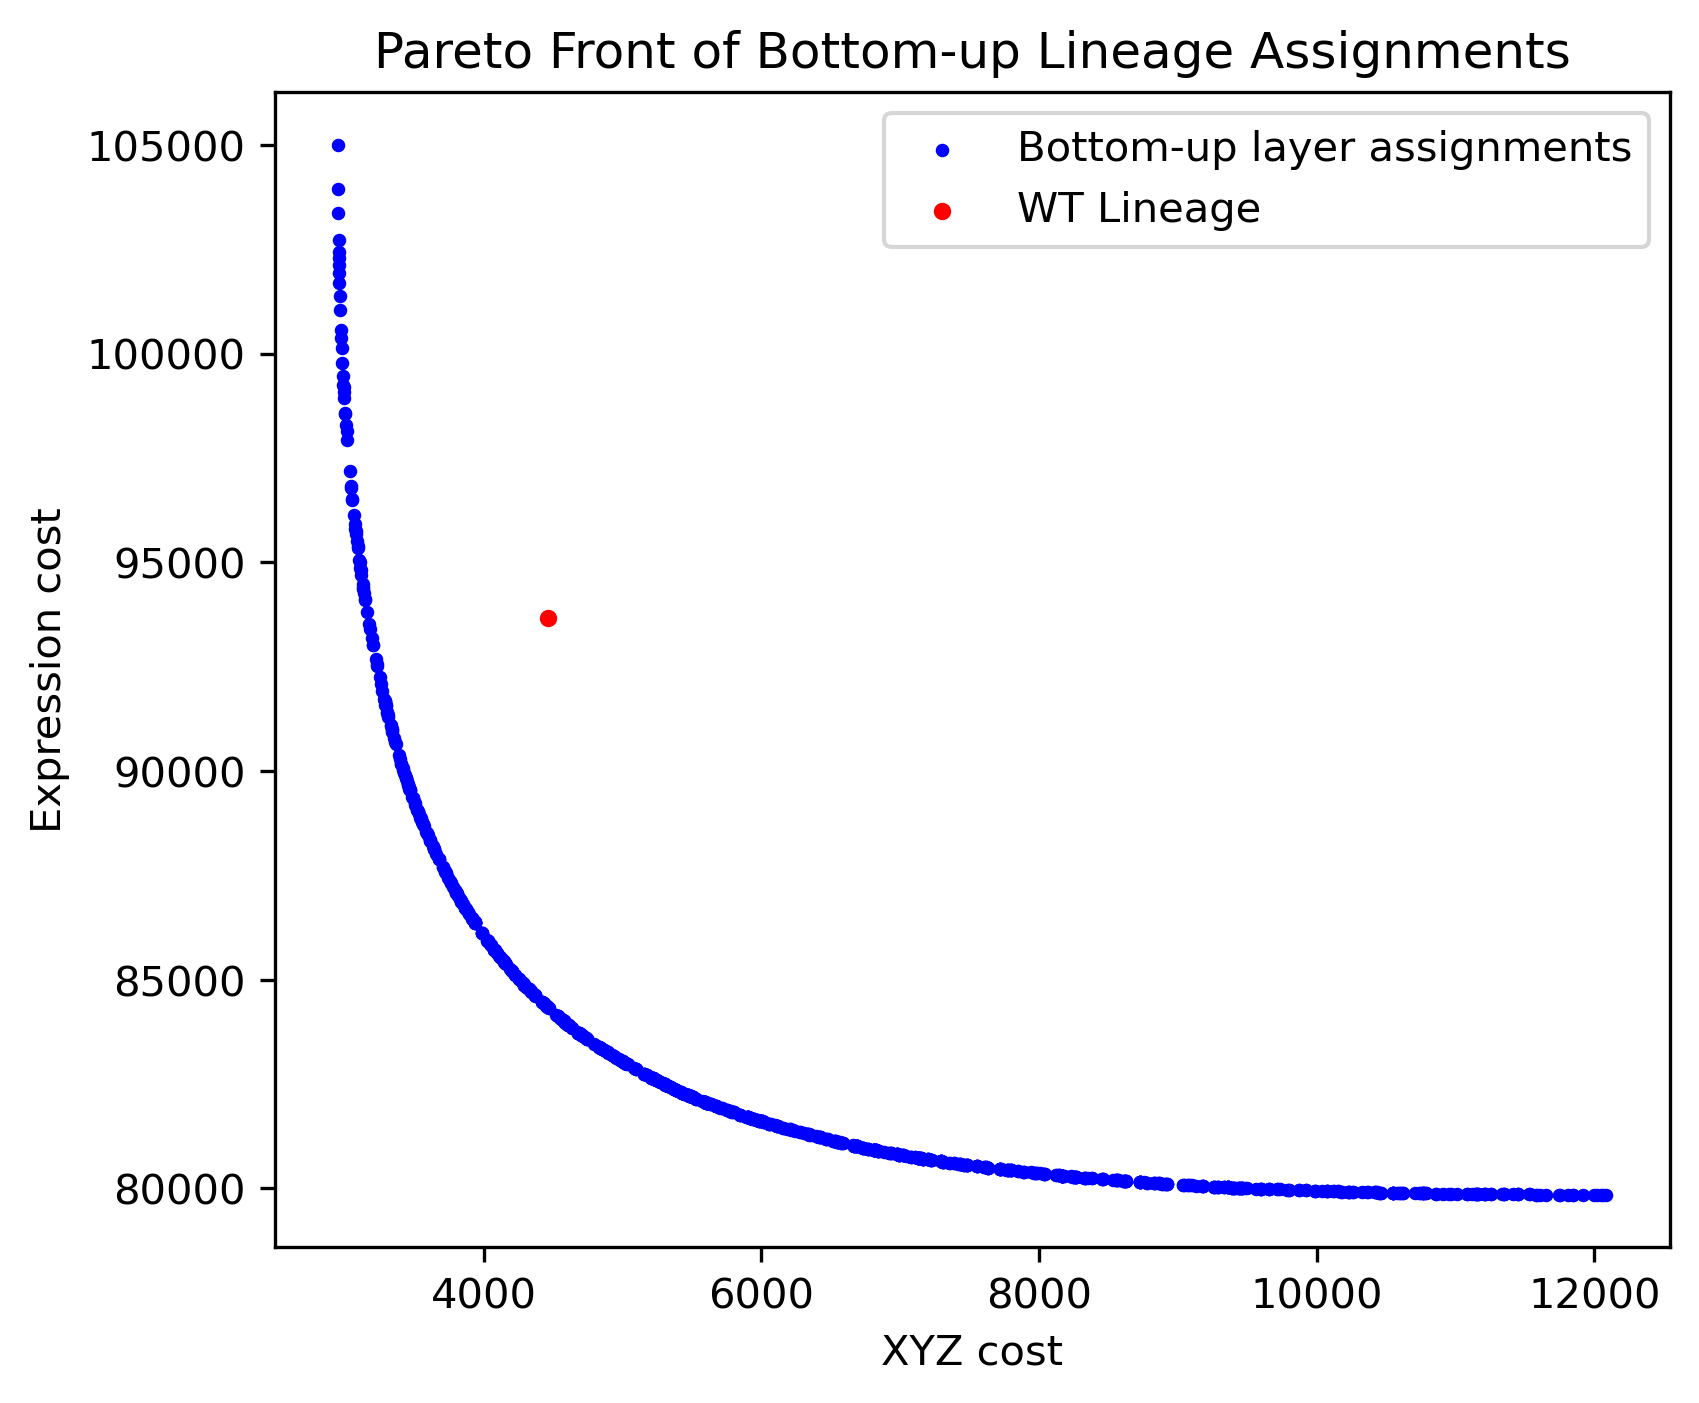

In [43]:
# plot pareto front and lineage xyz cost vs exp cost
plt.figure(figsize=(6,5))
plt.scatter(new_pareto_fronts[:,0], new_pareto_fronts[:,1], c='blue', s=5, label="Bottom-up layer assignments")
plt.xlabel("XYZ cost")
plt.ylabel("Expression cost")
plt.title("Pareto Front of Bottom-up Lineage Assignments")
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, c='red', s=10, label='WT Lineage')
plt.legend()
plt.show()

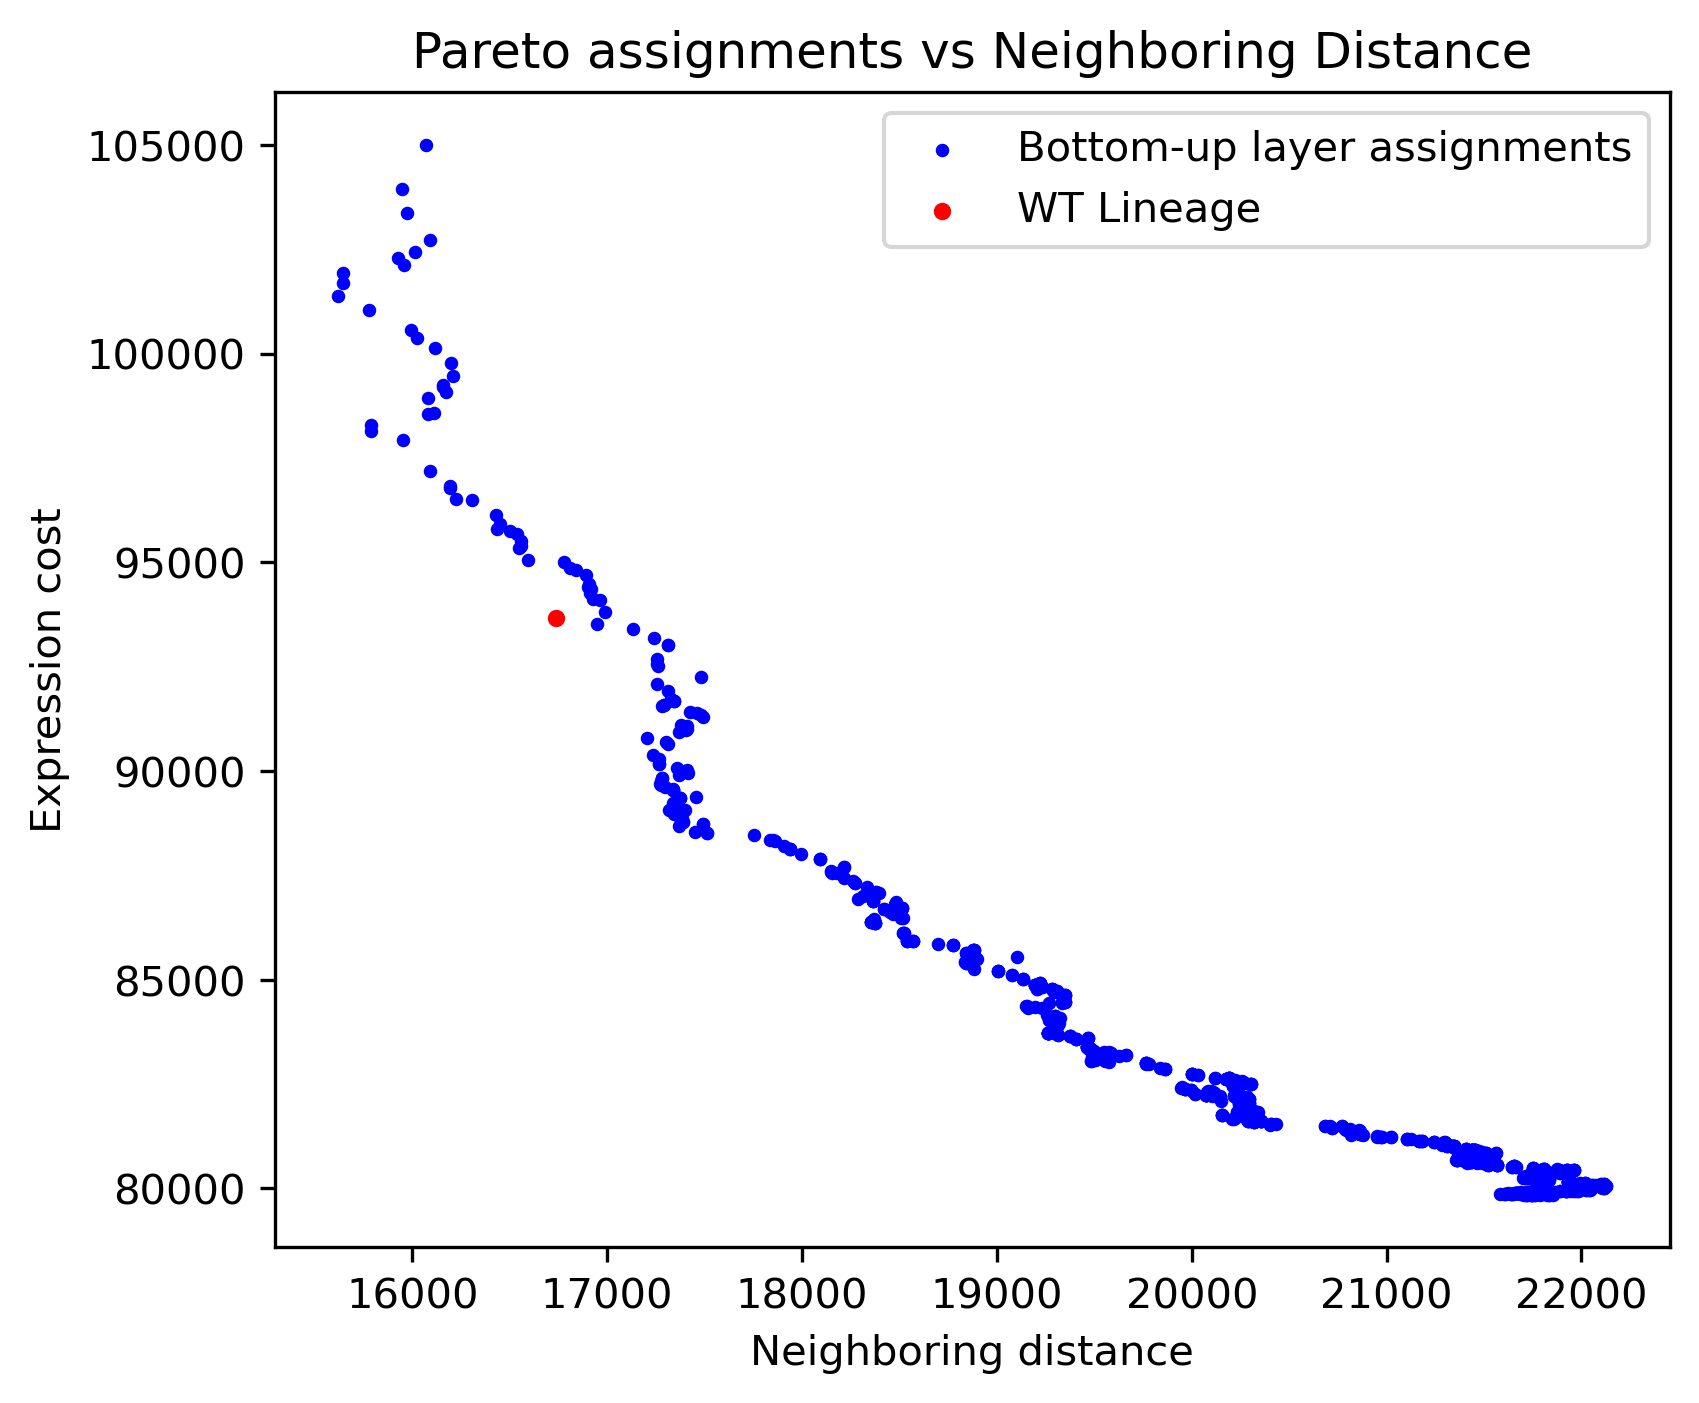

In [44]:
# plot pareto front and lineage xyz cost vs exp cost
plt.figure(figsize=(6,5))
plt.scatter(neighboring_distance_list, new_pareto_fronts[:,1], c='blue', s=5, label="Bottom-up layer assignments")
plt.xlabel("Neighboring distance")
plt.ylabel("Expression cost")
plt.title("Pareto assignments vs Neighboring Distance")
plt.scatter(lineage_neighboring_distance, opt.lineage_exp_cost, c='red', s=10, label='WT Lineage')
plt.legend()
plt.show()

In [45]:
pareto_fronts = []
for lineage_mapping in res[2]:
    xyz_cost, exp_cost = opt.calc_lineage_cost(lineage_id_mapping=lineage_mapping)
    pareto_fronts.append((xyz_cost, exp_cost))

In [46]:
lineage_xyz_costs = [a for a, _ in res[1]]
lineage_exp_costs = [b for _, b in res[1]]

In [47]:
pareto_fronts = np.array(res[0])
summed_pareto_front = np.sum(pareto_fronts, axis=0)

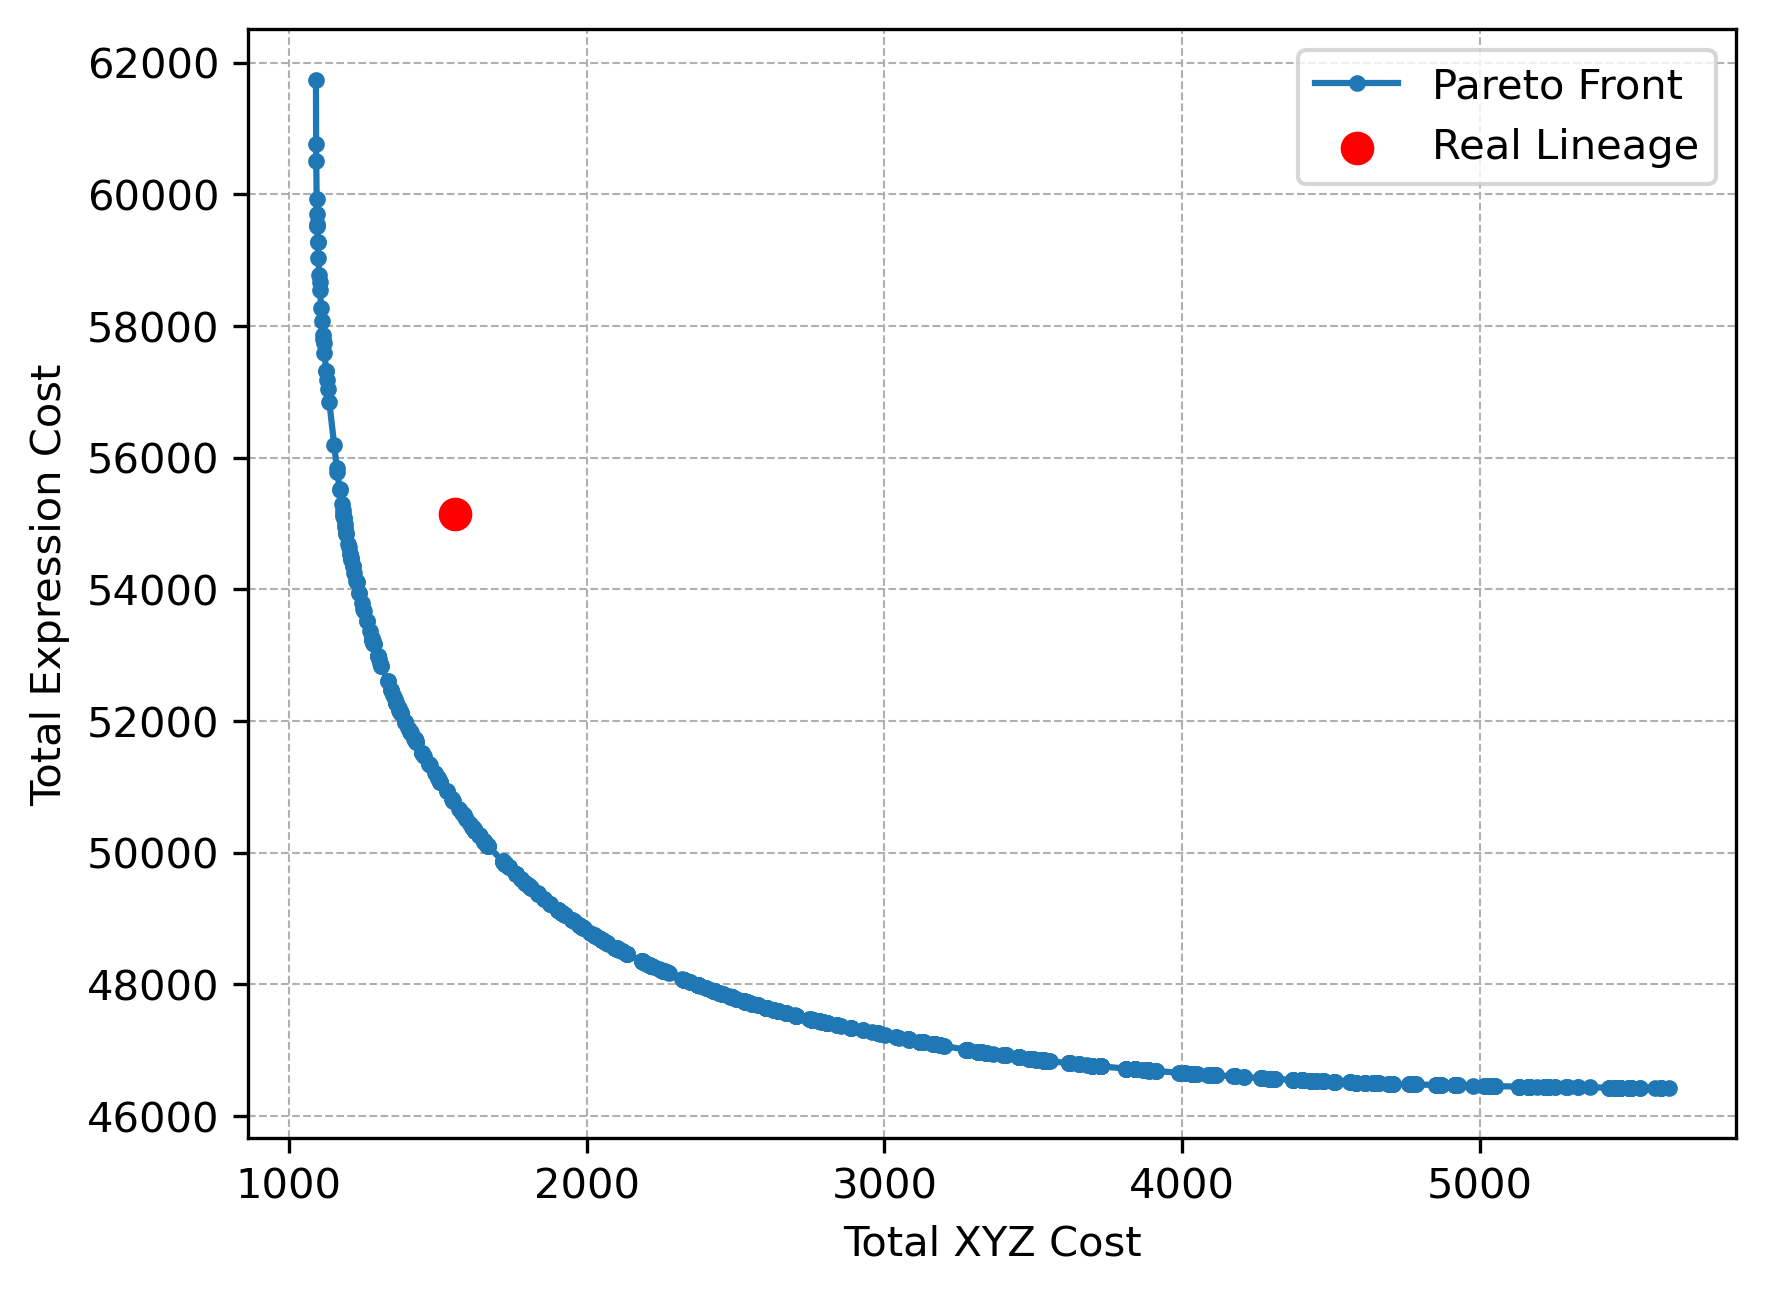

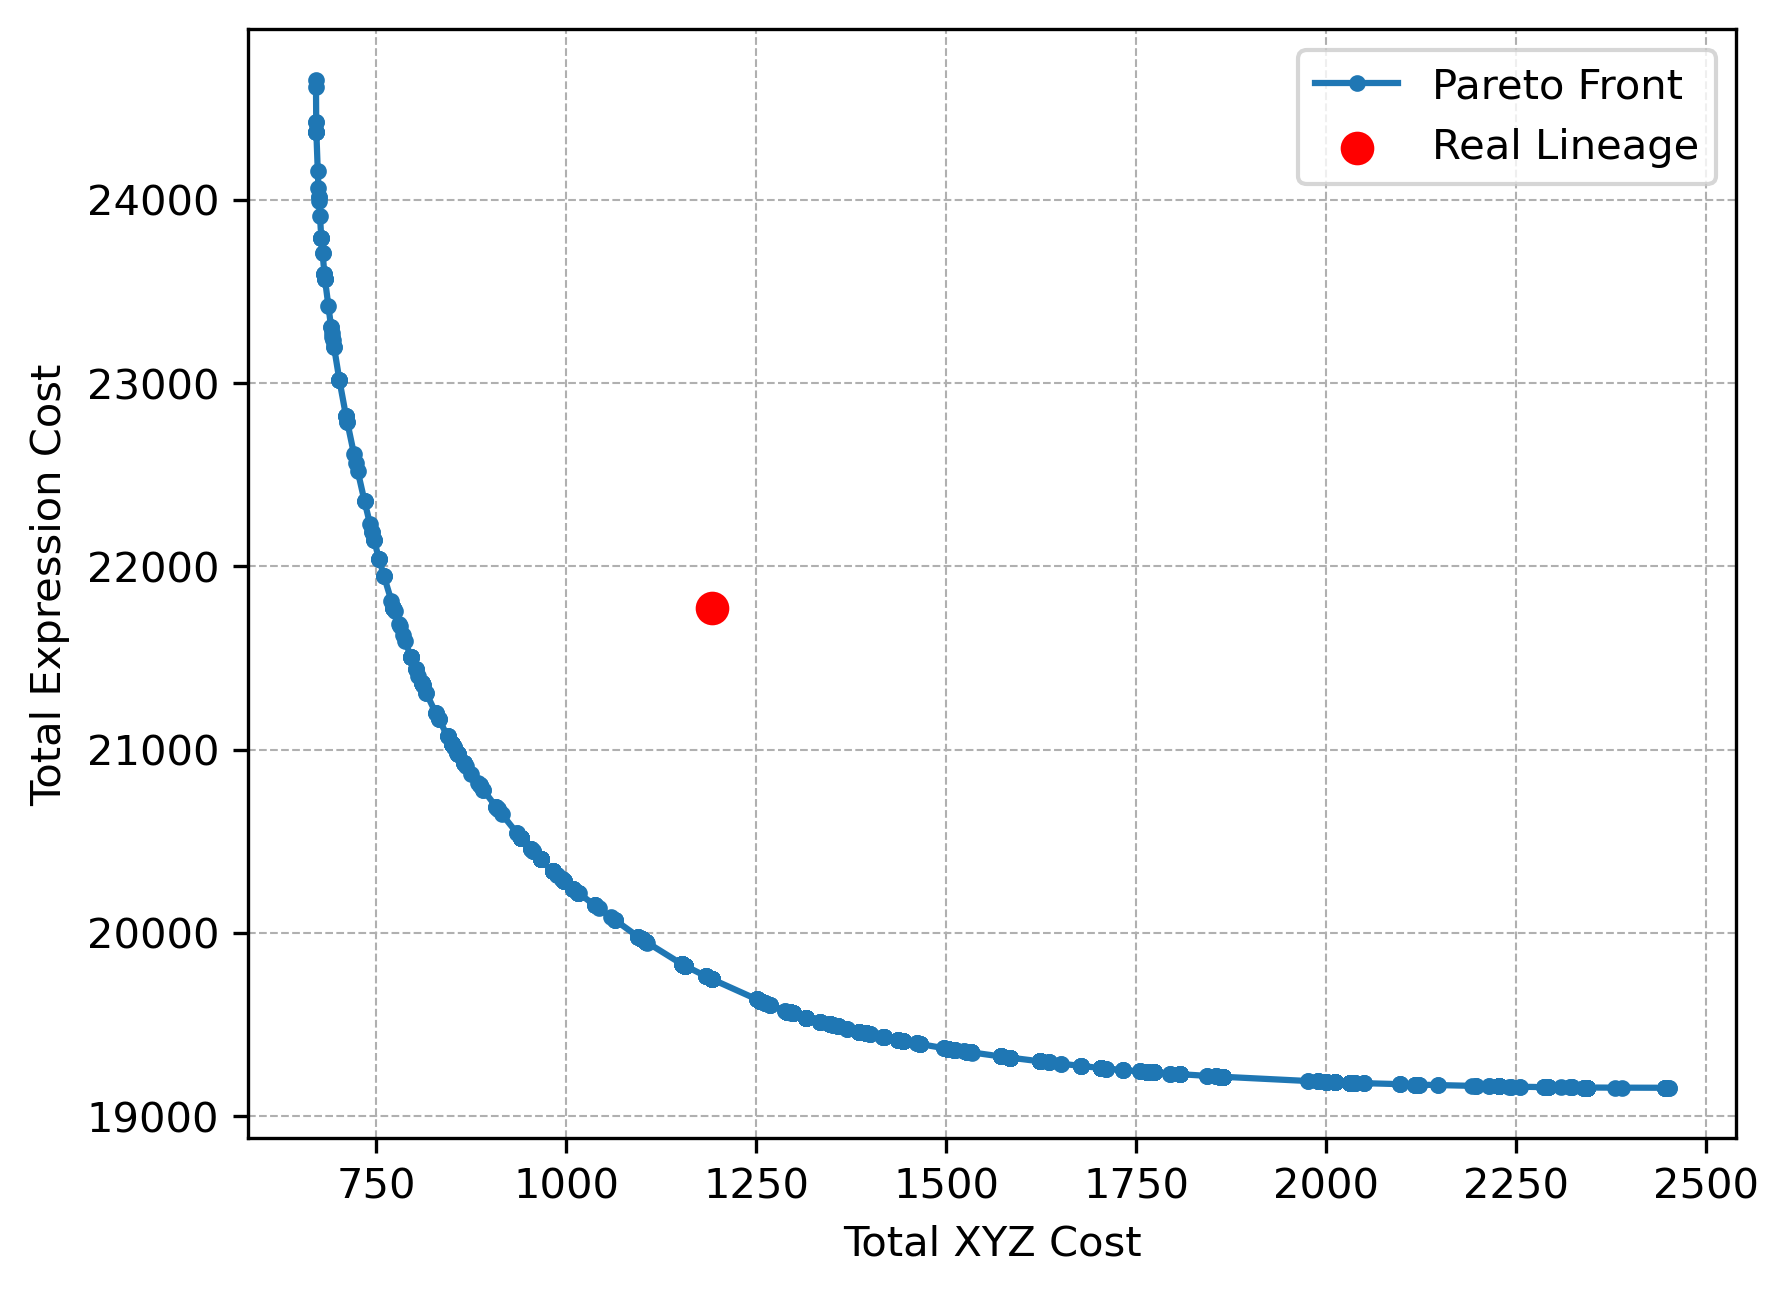

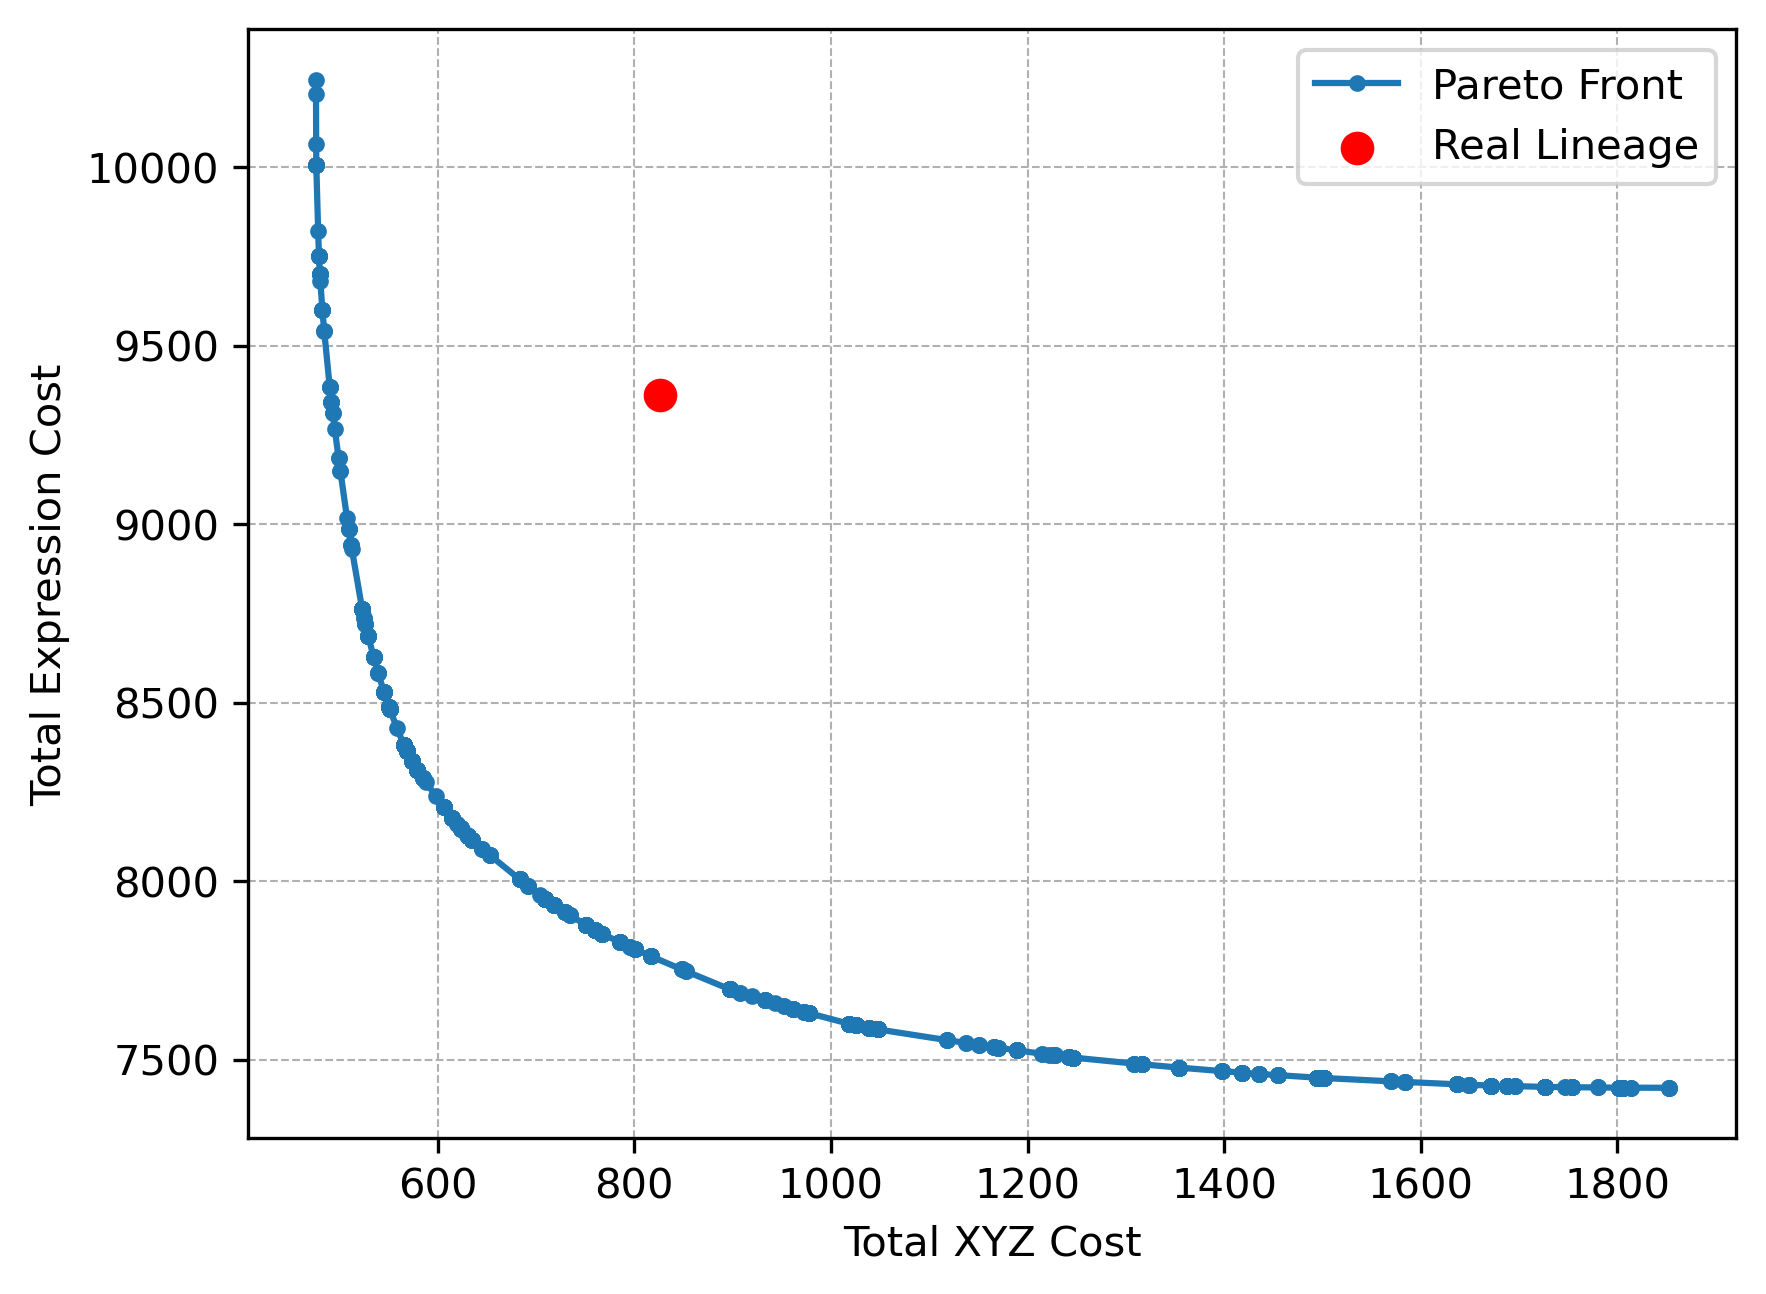

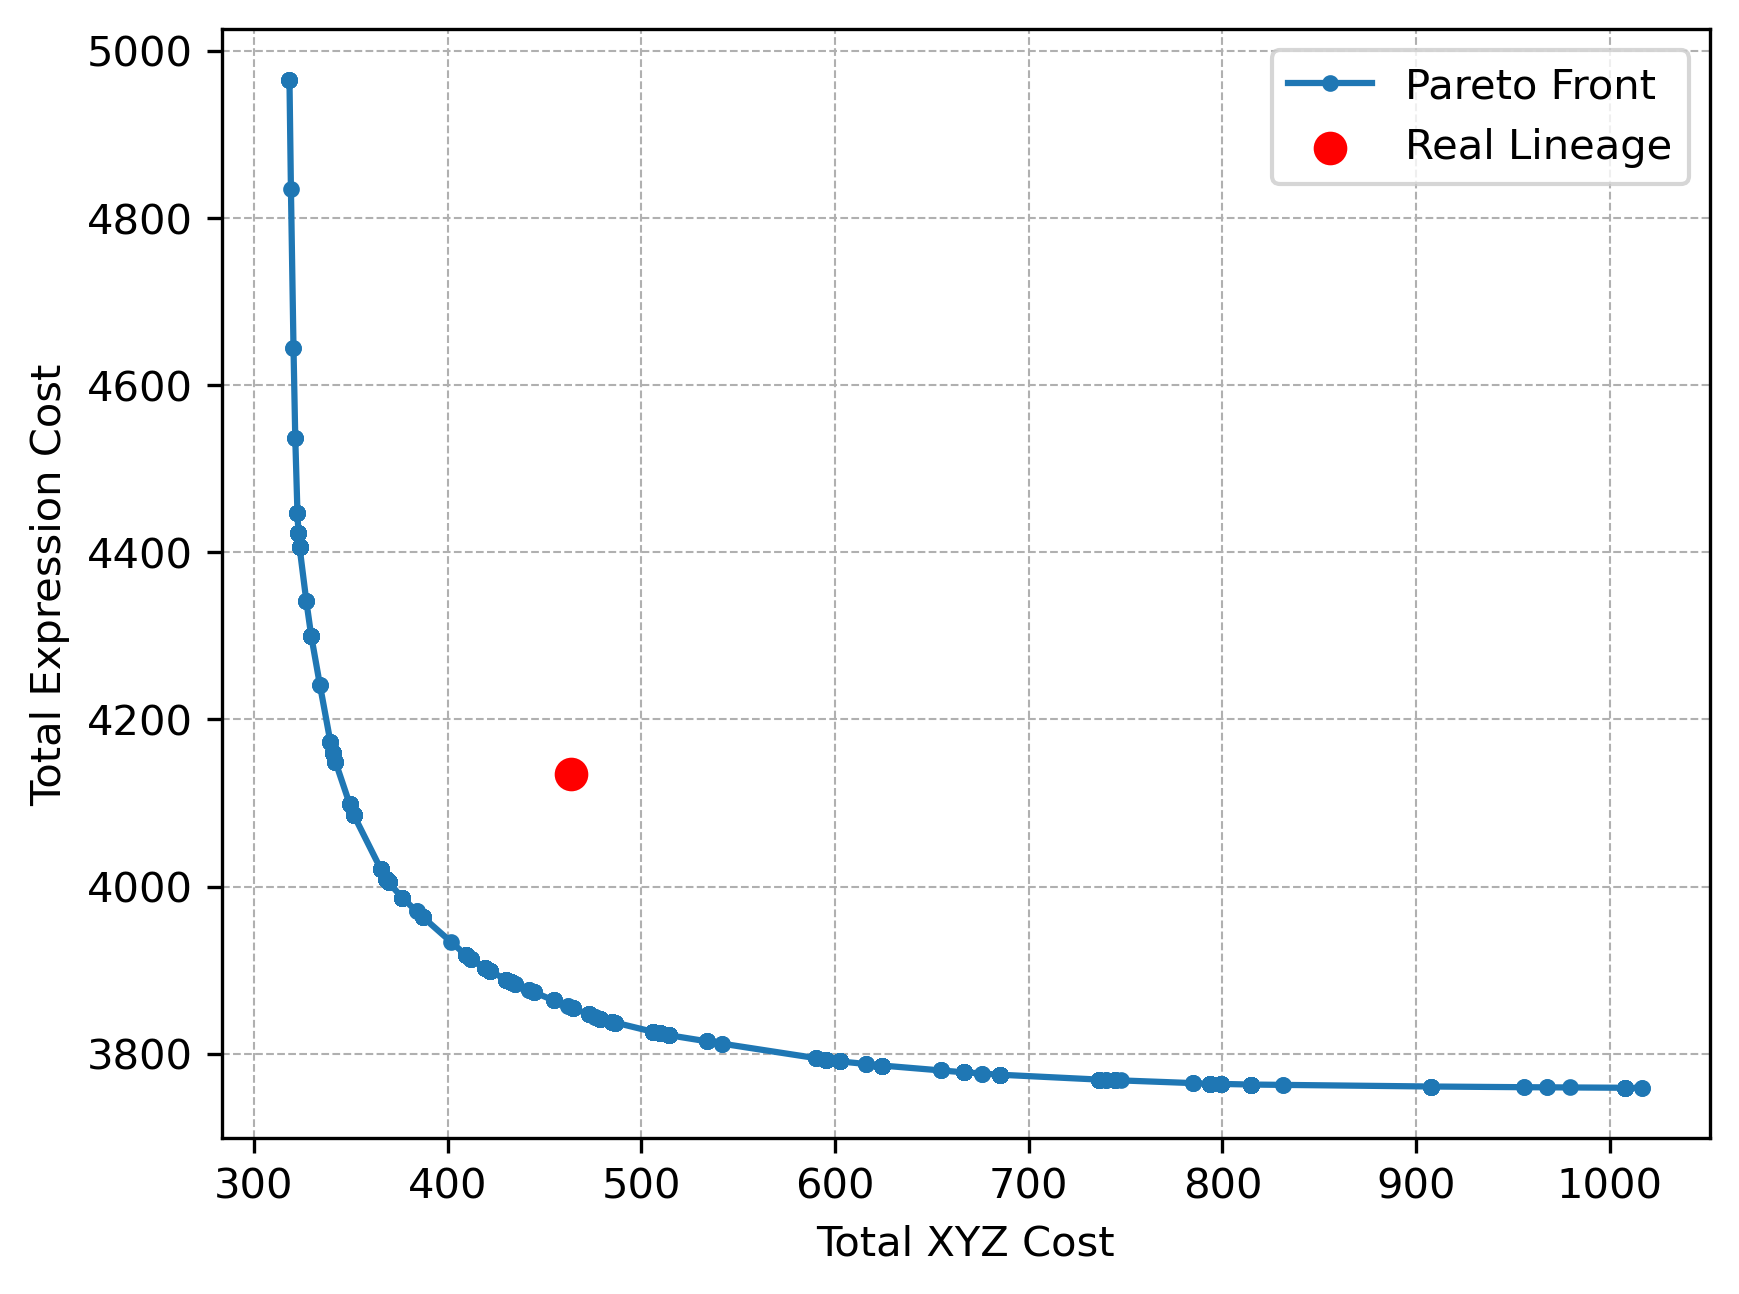

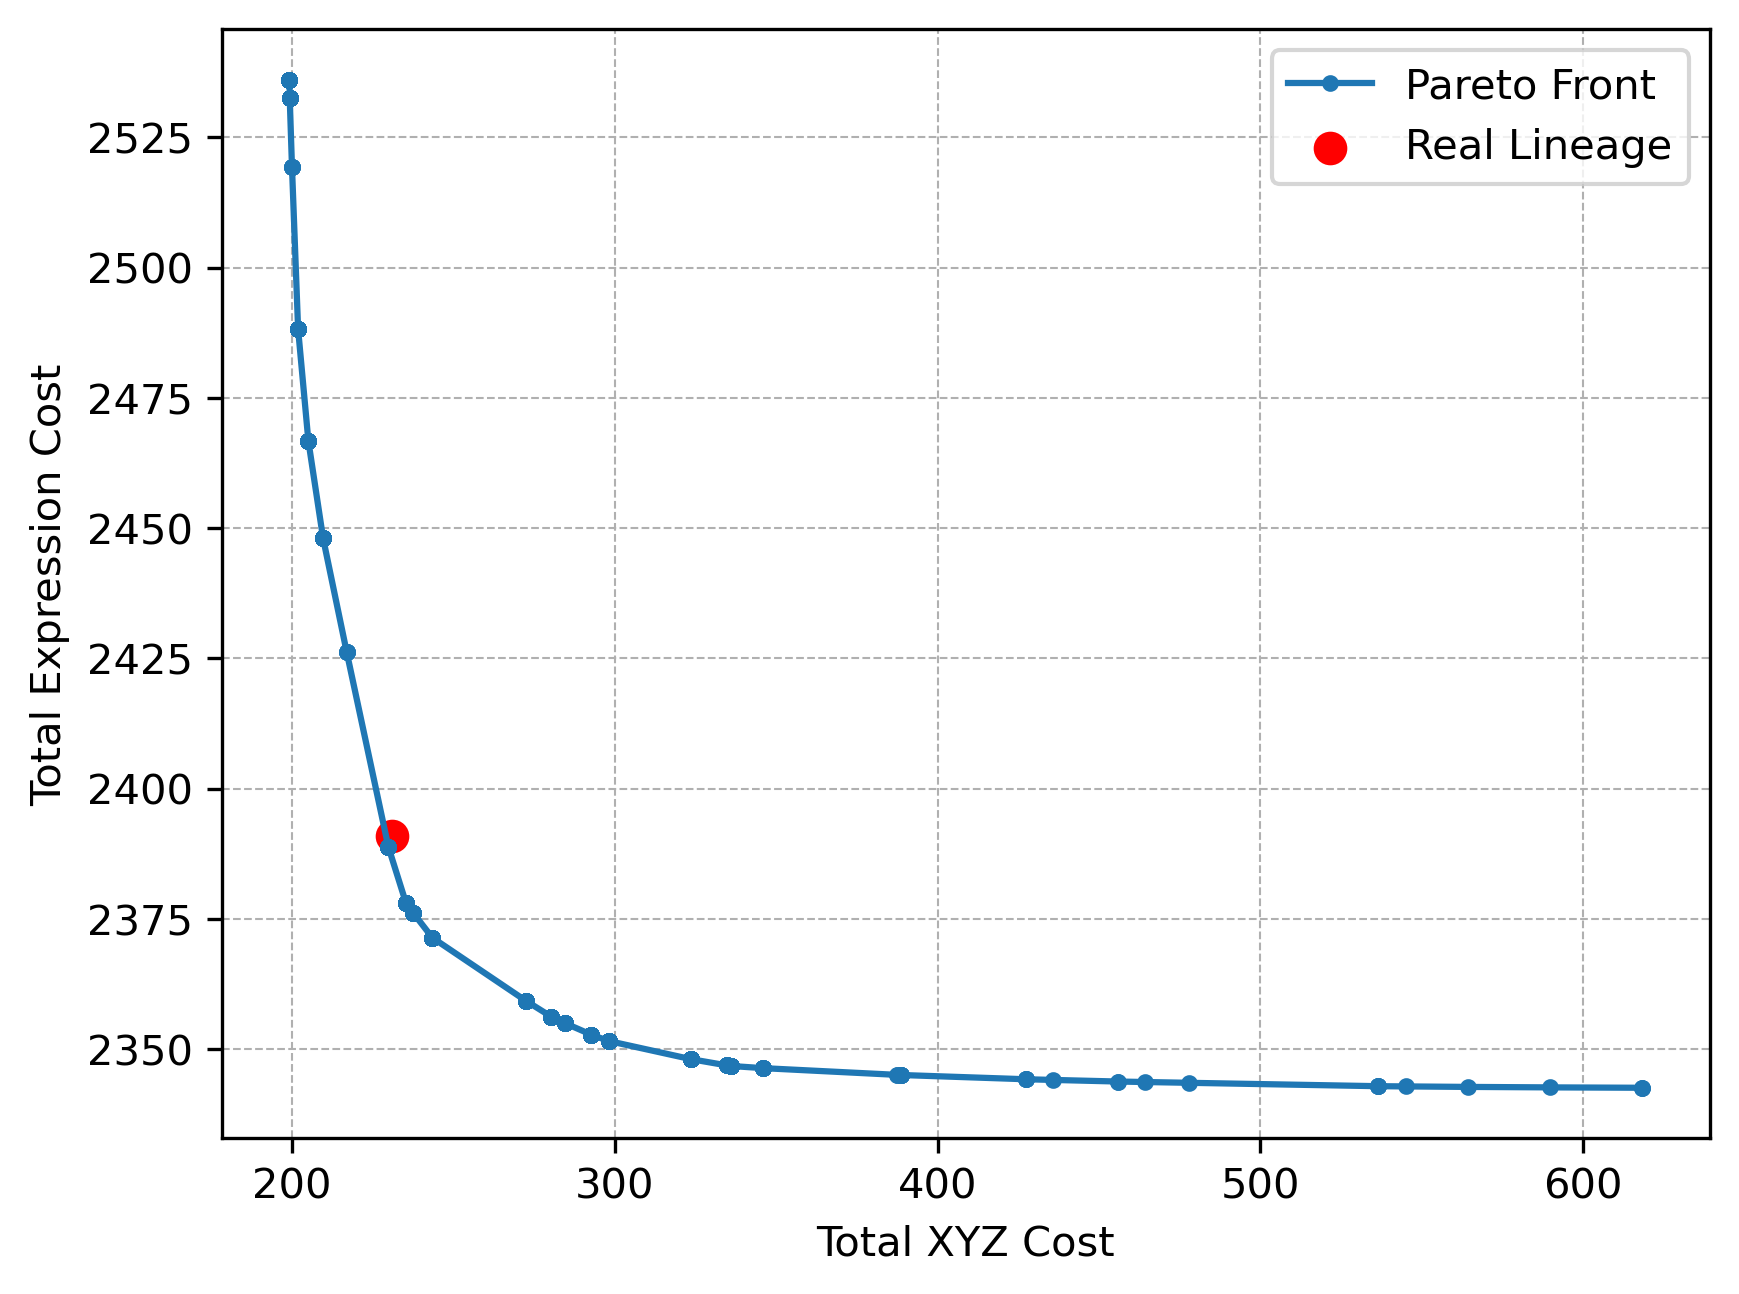

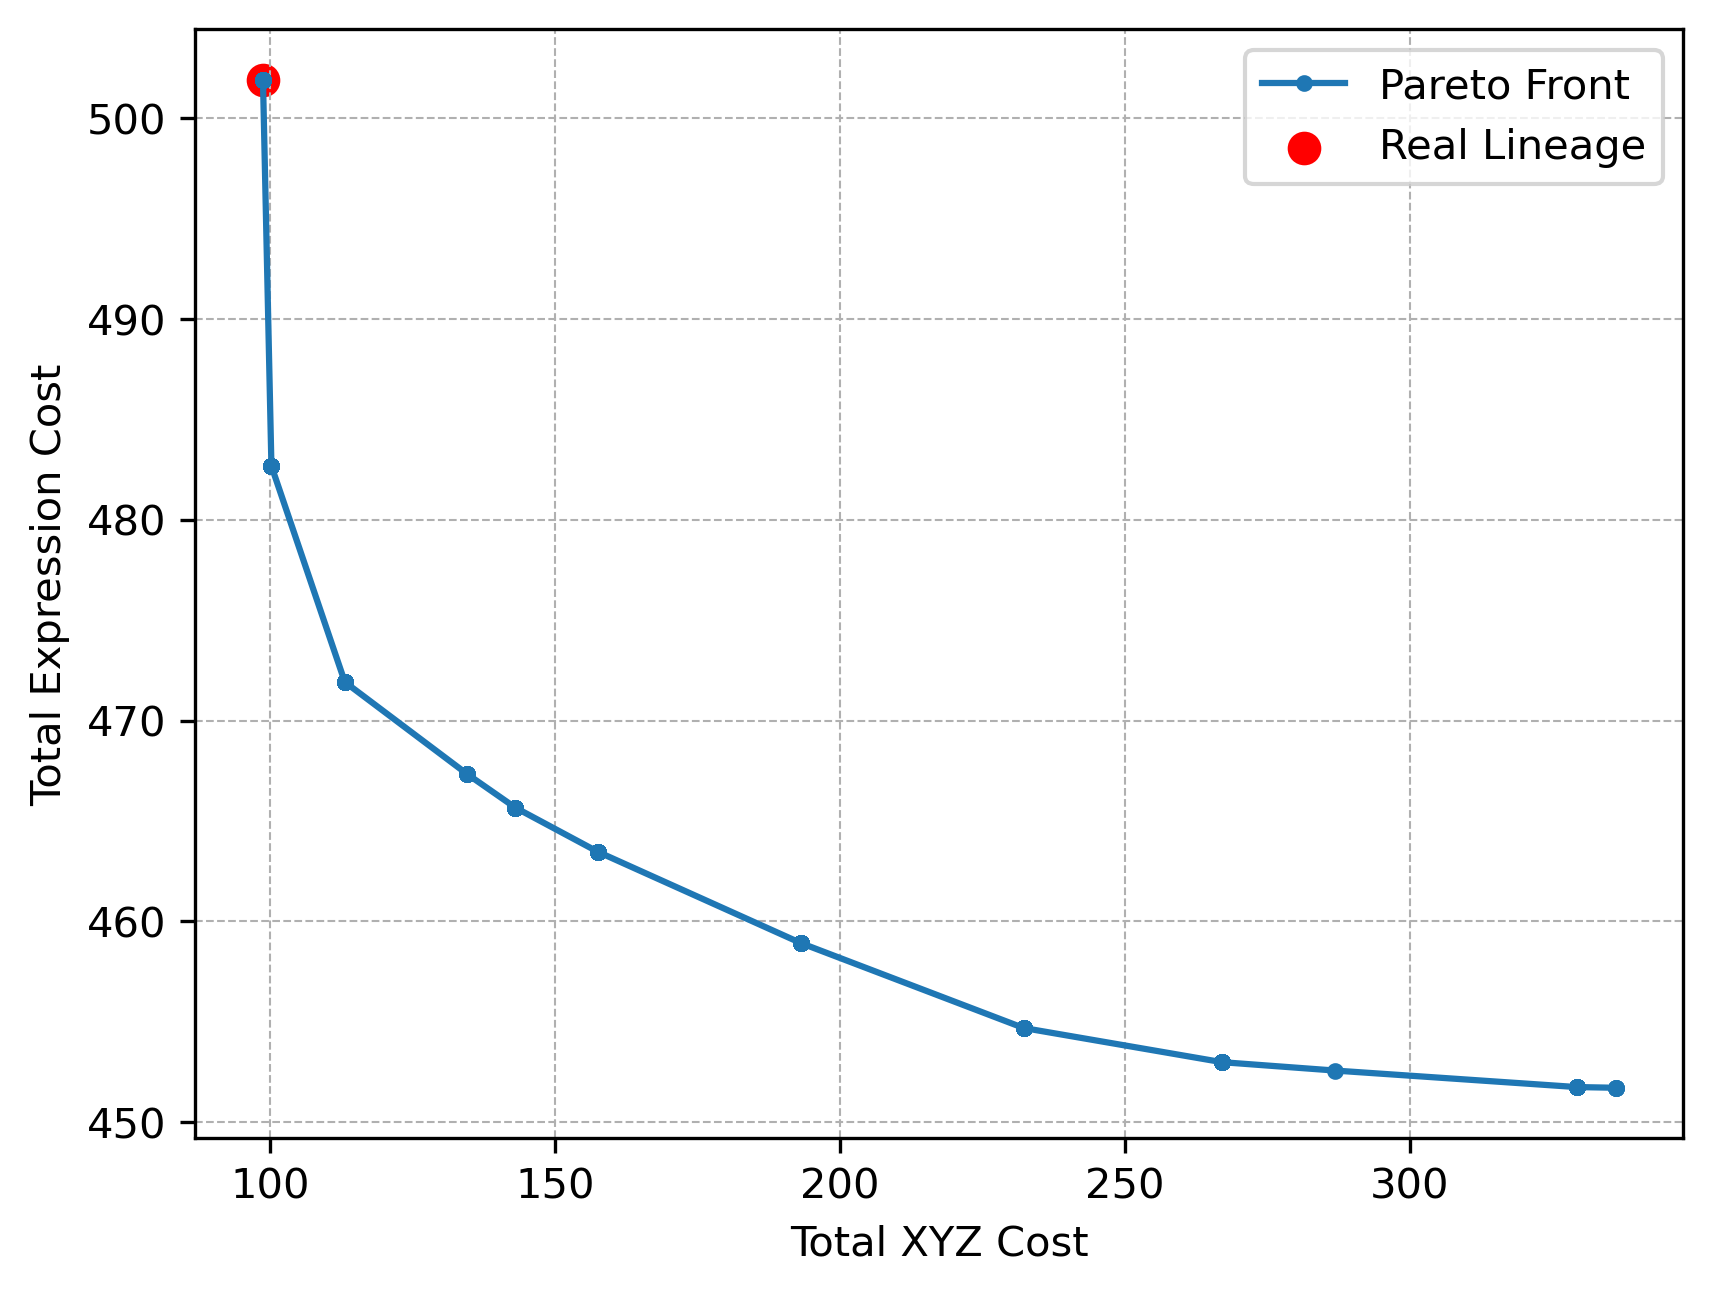

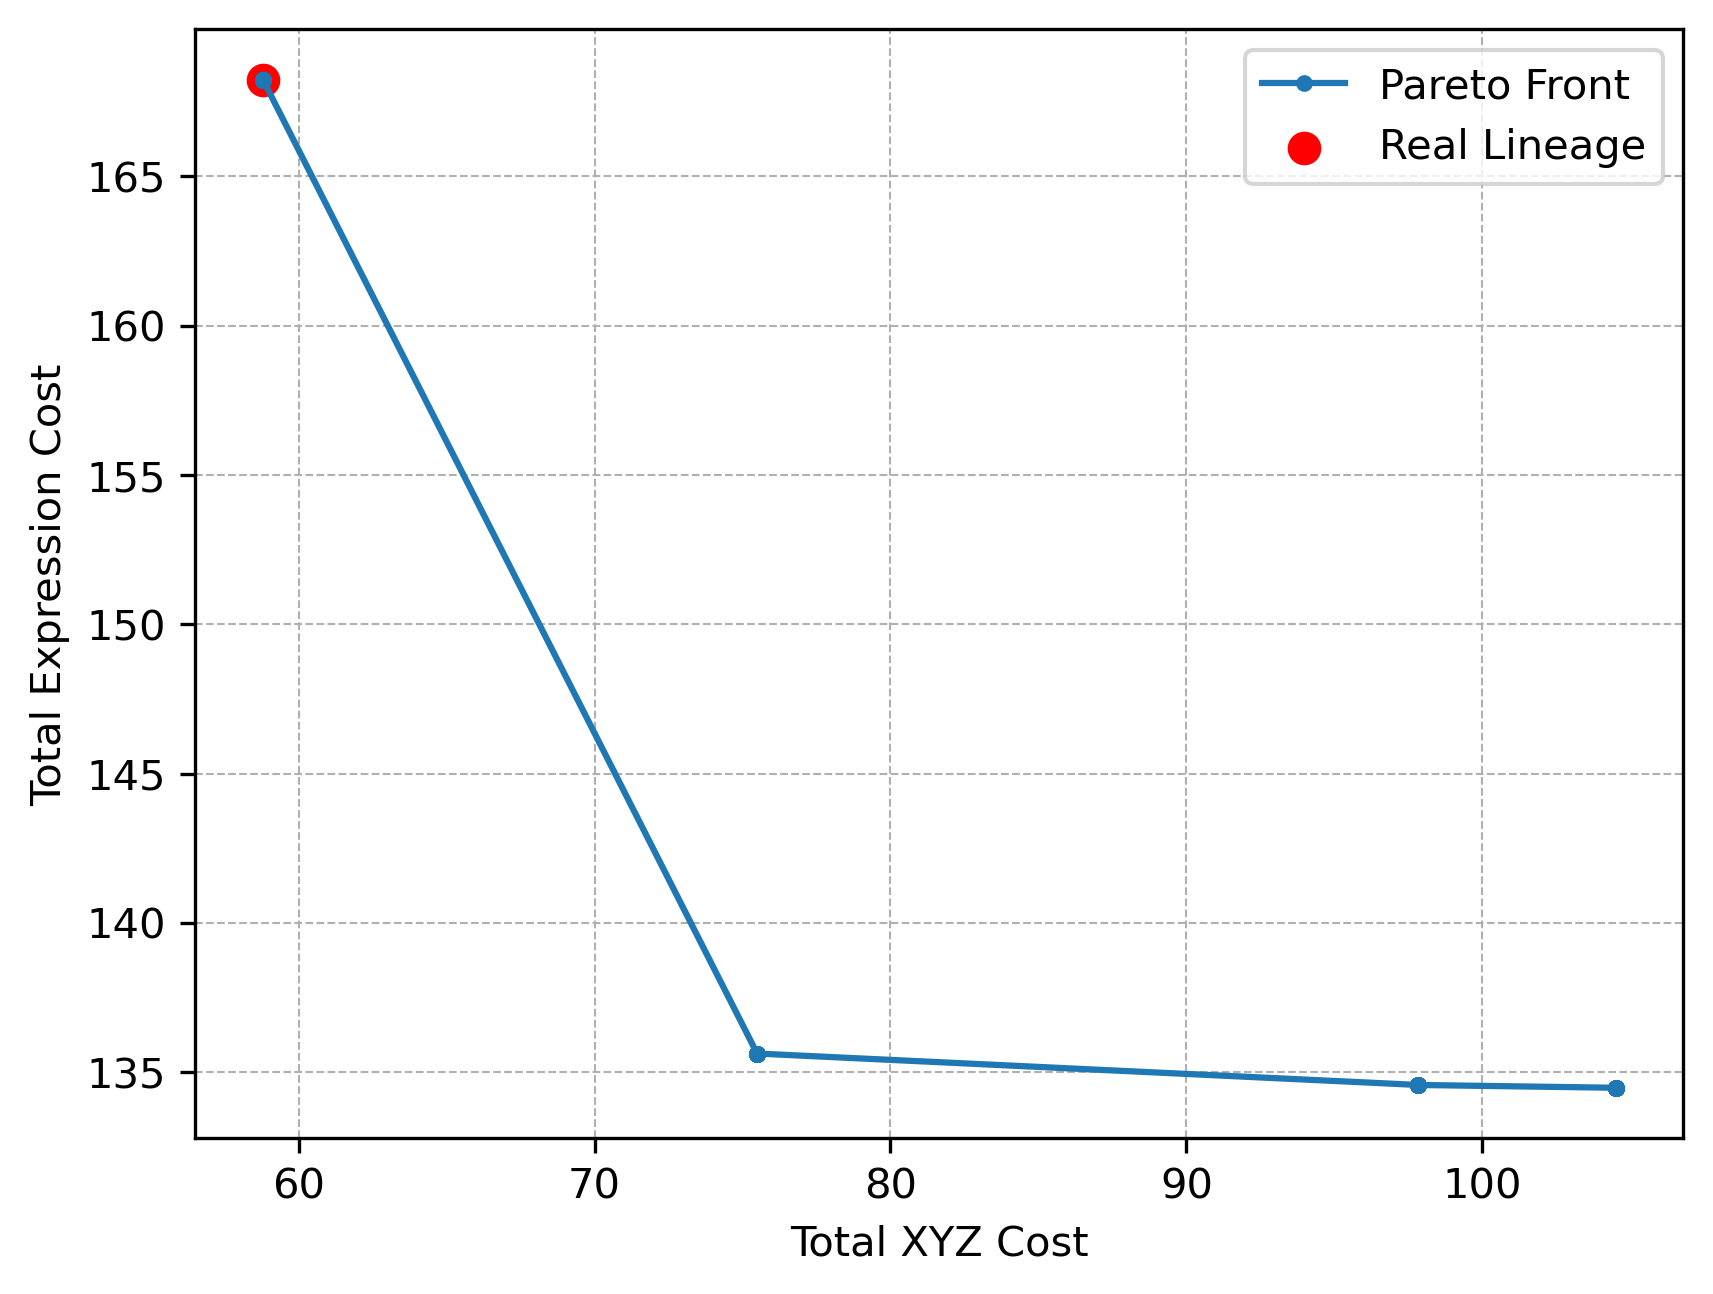

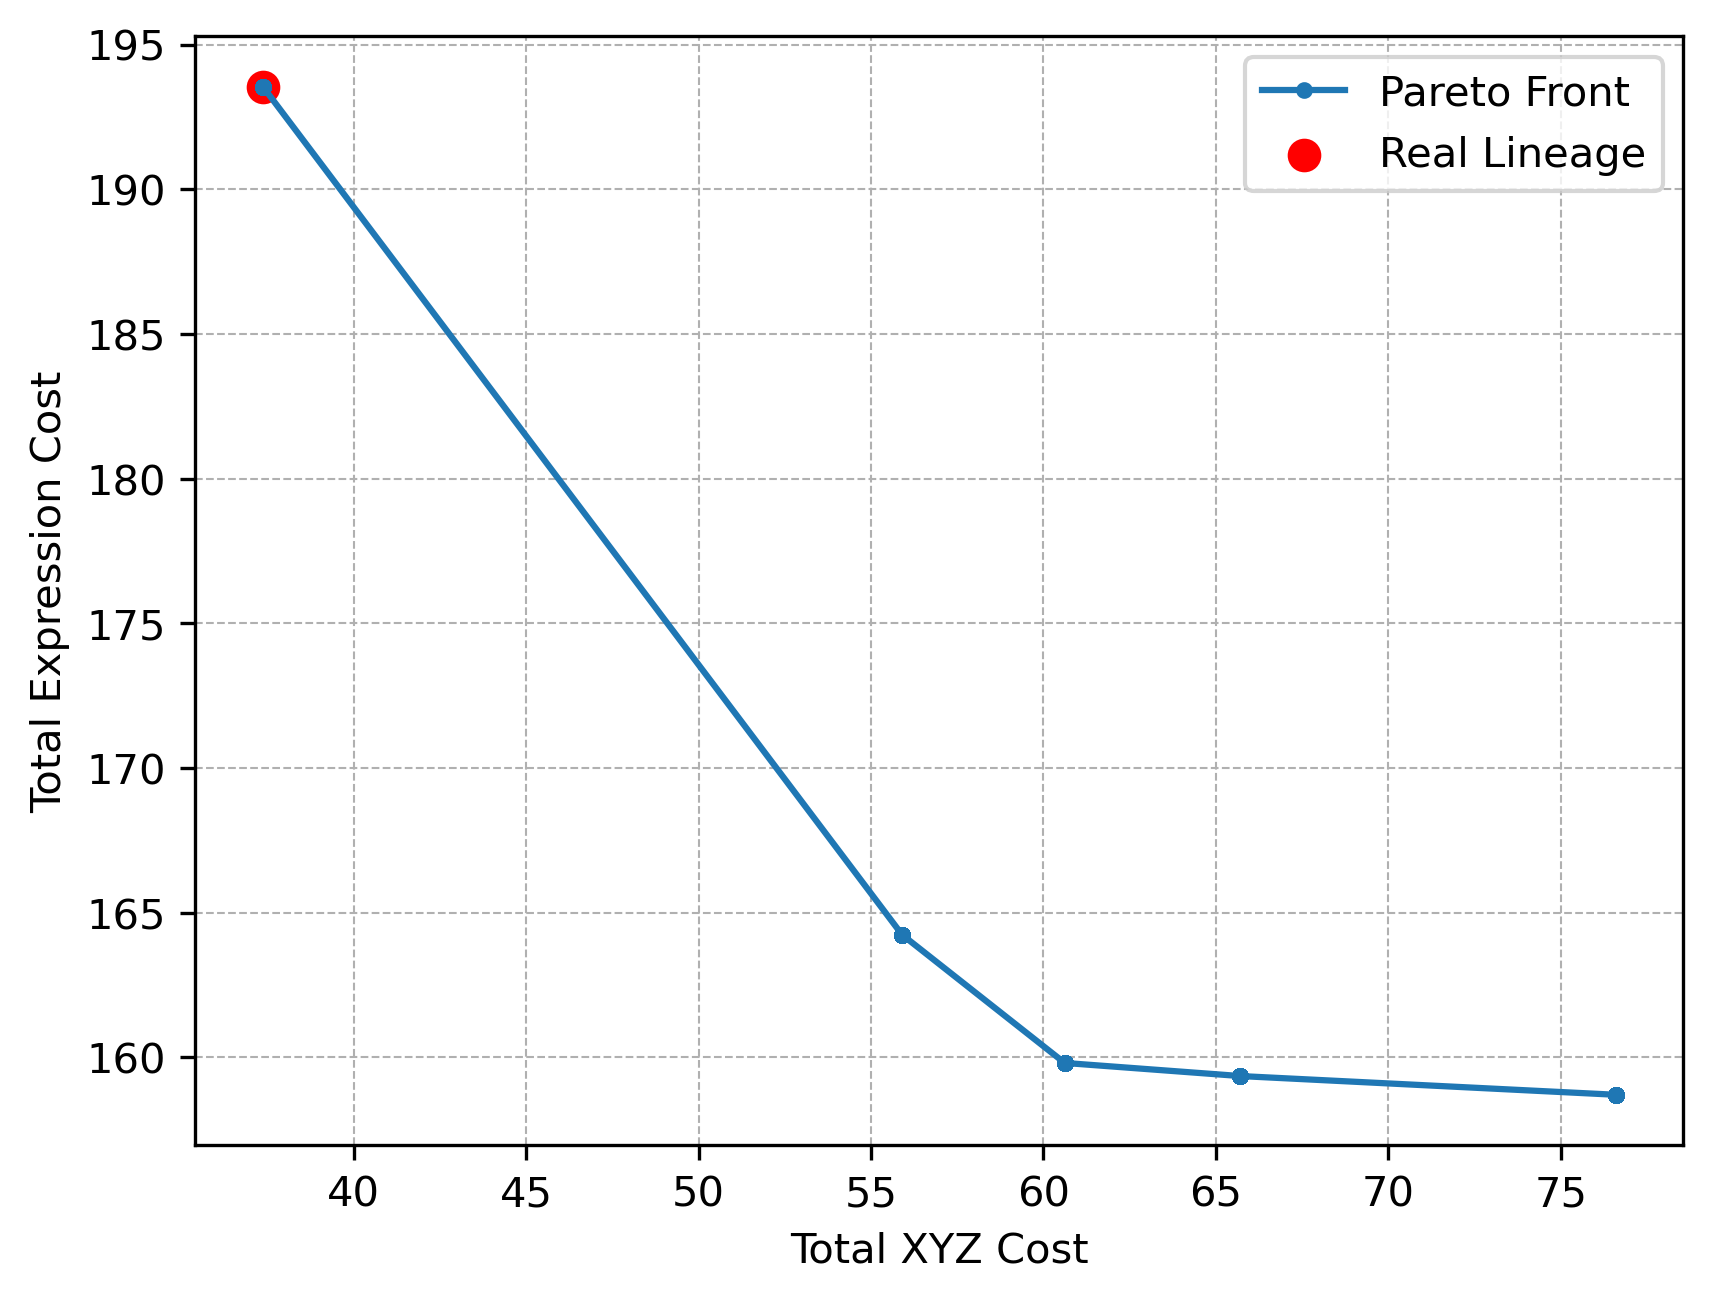

In [48]:
pareto_fronts_by_layer = res[0]
layer_costs = res[1]
# plot pareto fronts at each layer
layer_names = ["last", "second_last", "third_last"]
layer_nodes = [505, 275, 174]
for layer_idx, (pareto_front, layer_cost) in enumerate(zip(pareto_fronts_by_layer, layer_costs)):
    pareto_front = np.array(pareto_front)
    plt.figure()
    plt.plot(pareto_front[:,0], pareto_front[:,1], marker='o', linestyle='-', markersize=3, label='Pareto Front')
    plt.scatter(layer_cost[0], layer_cost[1], color='red', s=50, label='Real Lineage')
    # plt.title(f"Pareto Front at {layer_names[layer_idx]} layer, with {layer_nodes[layer_idx]} cells")
    plt.xlabel("Total XYZ Cost")
    plt.ylabel("Total Expression Cost")
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.legend()
    # plt.savefig(f"pareto_front_layer_{layer_idx}.png")
    plt.show()

In [ ]:
random_res_by_layer = opt.random_assignment_by_layer_runner()
random_xyz_by_layer = [cost[0] for cost in random_res_by_layer]
random_exp_by_layer = [cost[1] for cost in random_res_by_layer]

random_res_by_1st_cousins = opt.random_cousin_shuffle_runner(degree=1)
random_xyz_by_1st_cousins = [cost[0] for cost in random_res_by_1st_cousins]
random_exp_by_1st_cousins = [cost[1] for cost in random_res_by_1st_cousins]
random_res_by_2nd_cousins = opt.random_cousin_shuffle_runner(degree=2)
random_xyz_by_2nd_cousins = [cost[0] for cost in random_res_by_2nd_cousins]
random_exp_by_2nd_cousins = [cost[1] for cost in random_res_by_2nd_cousins] 
random_res_by_3rd_cousins = opt.random_cousin_shuffle_runner(degree=3)
random_xyz_by_3rd_cousins = [cost[0] for cost in random_res_by_3rd_cousins]
random_exp_by_3rd_cousins = [cost[1] for cost in random_res_by_3rd_cousins]

In [27]:
# save the random shuffle results

import pickle
with open("output/internal_opt/embryo1/10_pca_255_l2/pareto_random_shuffle_results.pkl", "wb") as f:
    pickle.dump({
        "random_xyz_by_1st_cousins": random_xyz_by_1st_cousins,
        "random_exp_by_1st_cousins": random_exp_by_1st_cousins,
        "random_xyz_by_2nd_cousins": random_xyz_by_2nd_cousins,
        "random_exp_by_2nd_cousins": random_exp_by_2nd_cousins,
        "random_xyz_by_3rd_cousins": random_xyz_by_3rd_cousins,
        "random_exp_by_3rd_cousins": random_exp_by_3rd_cousins,
        "random_xyz_by_layer": random_xyz_by_layer,
        "random_exp_by_layer": random_exp_by_layer
    }, f)

In [33]:
# read random shuffle results from pickle file
import pickle
with open("output/internal_opt/embryo1/10_pca_255_l2/pareto_random_shuffle_results.pkl", "rb") as f:
    random_shuffle_results = pickle.load(f)
random_xyz_by_1st_cousins = random_shuffle_results["random_xyz_by_1st_cousins"]
random_exp_by_1st_cousins = random_shuffle_results["random_exp_by_1st_cousins"]
random_xyz_by_2nd_cousins = random_shuffle_results["random_xyz_by_2nd_cousins"]
random_exp_by_2nd_cousins = random_shuffle_results["random_exp_by_2nd_cousins"]
random_xyz_by_3rd_cousins = random_shuffle_results["random_xyz_by_3rd_cousins"]
random_exp_by_3rd_cousins = random_shuffle_results["random_exp_by_3rd_cousins"]
random_xyz_by_layer = random_shuffle_results["random_xyz_by_layer"]
random_exp_by_layer = random_shuffle_results["random_exp_by_layer"]

In [23]:
pareto_list_by_layer = opt.bottom_up_by_layer_runner()
pareto_list_top_down_rebuild = opt.top_down_rebuild_runner()
pareto_mst_list = opt.mst_rebuild_runner()
pareto_list_top_down_rebuild_depth_cutoff = opt.top_down_rebuild_runner(depth_weight_type=depth_cutoff_func)

pareto_xyz_cost_list_by_layer = [cost[0] for cost in pareto_list_by_layer]
pareto_exp_cost_list_by_layer = [cost[1] for cost in pareto_list_by_layer]
pareto_xyz_cost_list_top_down_rebuild = [cost[0] for cost in pareto_list_top_down_rebuild]
pareto_exp_cost_list_top_down_rebuild = [cost[1] for cost in pareto_list_top_down_rebuild]
pareto_xyz_cost_list_mst = [cost[0] for cost in pareto_mst_list]
pareto_exp_cost_list_mst = [cost[1] for cost in pareto_mst_list]
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = [cost[0] for cost in pareto_list_top_down_rebuild_depth_cutoff]
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = [cost[1] for cost in pareto_list_top_down_rebuild_depth_cutoff]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing mst test:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [29]:
pareto_list_paired_bottom_up_rebuild = opt.paired_bottom_up_rebuild_runner()
pareto_xyz_cost_list_paired_bottom_up_rebuild = [cost[0] for cost in pareto_list_paired_bottom_up_rebuild]
pareto_exp_cost_list_paired_bottom_up_rebuild = [cost[1] for cost in pareto_list_paired_bottom_up_rebuild]

Computing pareto costs 1/4:   0%|          | 0/250 [00:00<?, ?it/s]

Computing pareto costs 2/4:   0%|          | 0/250 [00:00<?, ?it/s]

Computing pareto costs 3/4:   0%|          | 0/250 [00:00<?, ?it/s]

Computing pareto costs 4/4:   0%|          | 0/251 [00:00<?, ?it/s]

In [24]:
pareto_list_terminal_only_kd_internal = opt.terminal_only_rebuild_runner(use_kd_tree=True, exp_replacement=False)
pareto_xyz_cost_list_terminal_only_kd_internal_no_replacement = [cost[0] for cost in pareto_list_terminal_only_kd_internal]
pareto_exp_cost_list_terminal_only_kd_internal_no_replacement = [cost[1] for cost in pareto_list_terminal_only_kd_internal]

# save pareto_list_terminal_only_kd_internal as a pandas dataframe
pareto_df_terminal_only_kd_internal = pd.DataFrame(pareto_list_terminal_only_kd_internal, columns=['xyz_cost', 'exp_cost', 'internal_selection_count', 'complexity_score', 'min_consines', 'mean_consines'])
pareto_df_terminal_only_kd_internal.to_csv('output/internal_opt/embryo1/10_pca_255_l2/pareto_terminal_only_kd_internal_no_exp_replacement.tsv', index=False, sep='\t')

Computing pareto costs 1/2:   0%|          | 0/500 [00:00<?, ?it/s]

Computing pareto costs 2/2:   0%|          | 0/501 [00:00<?, ?it/s]

In [22]:
pareto_list_terminal_only_kd_internal = opt.terminal_only_rebuild_runner(use_kd_tree=True)
pareto_xyz_cost_list_terminal_only_kd_internal = [cost[0] for cost in pareto_list_terminal_only_kd_internal]
pareto_exp_cost_list_terminal_only_kd_internal = [cost[1] for cost in pareto_list_terminal_only_kd_internal]

# save pareto_list_terminal_only_kd_internal as a pandas dataframe
pareto_df_terminal_only_kd_internal = pd.DataFrame(pareto_list_terminal_only_kd_internal, columns=['xyz_cost', 'exp_cost', 'internal_selection_count', 'complexity_score', 'min_consines', 'mean_consines'])
pareto_df_terminal_only_kd_internal.to_csv('output/internal_opt/embryo1/10_pca_255_l2/pareto_terminal_only_kd_internal.tsv', index=False, sep='\t')

Computing pareto costs 1/2:   0%|          | 0/500 [00:00<?, ?it/s]

Computing pareto costs 2/2:   0%|          | 0/501 [00:00<?, ?it/s]

In [23]:
# phylogenetic sampling and complexity optimization
phylogeny_sample_xyz_cost, phylogeny_sample_exp_cost, phylogeny_mean_xyz_cost, phylogeny_mean_exp_cost = opt.phylogenetic_sampling(root_id=0, n_samples=1000000)


Calculating phylogenetic costs...: 100%|██████████| 1007/1007 [00:59<00:00, 16.80it/s]


In [29]:
best_compexity_lineage_parent_list,complexity_optimization_cost_list, best_complexity_score = opt.genetic_complexity_optimization(iterations=1000000)
xyz_cost_complexity_optimization = [cost[0] for cost in complexity_optimization_cost_list]
exp_cost_complexity_optimization = [cost[1] for cost in complexity_optimization_cost_list]
min_complexity_xyz_cost = xyz_cost_complexity_optimization[-1]
min_complexity_exp_cost = exp_cost_complexity_optimization[-1]

Initial Complexity Score: 0.3817097415506958


100%|██████████| 1000000/1000000 [03:10<00:00, 5248.94it/s]


In [34]:
results_df = pd.DataFrame({
    'Bottom-up By Layer XYZ Cost': pareto_xyz_cost_list_by_layer,
    'Bottom-up By Layer Exp Cost': pareto_exp_cost_list_by_layer,
    'Top-Down Rebuild XYZ Cost': pareto_xyz_cost_list_top_down_rebuild,
    'Top-Down Rebuild Exp Cost': pareto_exp_cost_list_top_down_rebuild,
    'Paired Bottom-Up Rebuild XYZ Cost': pareto_xyz_cost_list_paired_bottom_up_rebuild,
    'Paired Bottom-Up Rebuild Exp Cost': pareto_exp_cost_list_paired_bottom_up_rebuild,
    'MST Based Rebuild XYZ Cost': pareto_xyz_cost_list_mst,
    'MST Based Rebuild Exp Cost': pareto_exp_cost_list_mst,
    'Top-Down Rebuild (Hard Depth Cutoff) XYZ Cost': pareto_xyz_cost_list_top_down_rebuild_depth_cutoff,
    'Top-Down Rebuild (Hard Depth Cutoff) Exp Cost': pareto_exp_cost_list_top_down_rebuild_depth_cutoff
})
results_df.to_csv('output/internal_opt/embryo1/10_pca_255_l2/pareto_comparison.csv', index=False)

In [30]:
results_df = pd.read_csv('output/internal_opt/embryo1/10_pca_255_l2/pareto_comparison.csv')
pareto_xyz_cost_list_by_layer = results_df["Bottom-up By Layer XYZ Cost"].tolist()
pareto_exp_cost_list_by_layer = results_df["Bottom-up By Layer Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild = results_df["Top-Down Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild = results_df["Top-Down Rebuild Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = results_df["Top-Down Rebuild (Hard Depth Cutoff) XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = results_df["Top-Down Rebuild (Hard Depth Cutoff) Exp Cost"].tolist()
pareto_xyz_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild Exp Cost"].tolist()    
pareto_xyz_cost_list_mst = results_df["MST Based Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_mst = results_df["MST Based Rebuild Exp Cost"].tolist()
pareto_df_terminal_only_kd_internal = pd.read_csv('output/internal_opt/embryo1/10_pca_255_l2/pareto_terminal_only_kd_internal.tsv', sep='\t')
pareto_xyz_cost_list_terminal_only_kd_internal = pareto_df_terminal_only_kd_internal['xyz_cost'].tolist()
pareto_exp_cost_list_terminal_only_kd_internal = pareto_df_terminal_only_kd_internal['exp_cost'].tolist()
pareto_internal_selection_count_list_terminal_only_kd_internal = [eval(s) for s in pareto_df_terminal_only_kd_internal['internal_selection_count'].tolist()]

pareto_df_terminal_only_kd_internal_no_exp_replacement = pd.read_csv('output/internal_opt/embryo1/10_pca_255_l2/pareto_terminal_only_kd_internal_no_exp_replacement.tsv', sep='\t')
pareto_xyz_cost_list_terminal_only_kd_internal_no_replacement = pareto_df_terminal_only_kd_internal_no_exp_replacement['xyz_cost'].tolist()
pareto_exp_cost_list_terminal_only_kd_internal_no_replacement = pareto_df_terminal_only_kd_internal_no_exp_replacement['exp_cost'].tolist()

In [31]:
optimal_xyz_cost = pareto_xyz_cost_list_paired_bottom_up_rebuild[-1]
optimal_exp_cost = pareto_exp_cost_list_paired_bottom_up_rebuild[0]
xyz_cost_at_exp_optimal = pareto_xyz_cost_list_paired_bottom_up_rebuild[0]
exp_cost_at_xyz_optimal = pareto_exp_cost_list_paired_bottom_up_rebuild[-1]

print("Optimal XYZ Cost:", optimal_xyz_cost,"relative to lineage XYZ cost:", optimal_xyz_cost / opt.lineage_xyz_cost)
print("Optimal Exp Cost:", optimal_exp_cost, "relative to lineage Exp cost:", optimal_exp_cost / opt.lineage_exp_cost)

print("alternative relative lineage xyz optimality:", (opt.lineage_xyz_cost - optimal_xyz_cost) / (xyz_cost_at_exp_optimal - optimal_xyz_cost))
print("alternative relative lineage exp optimality:", (opt.lineage_exp_cost - optimal_exp_cost) / (exp_cost_at_xyz_optimal - optimal_exp_cost))

Optimal XYZ Cost: 2955.75909133551 relative to lineage XYZ cost: 0.6619029395184124
Optimal Exp Cost: 78896.25416504889 relative to lineage Exp cost: 0.8423625661574325
alternative relative lineage xyz optimality: 0.14744159816463717
alternative relative lineage exp optimality: 0.26481584678315495


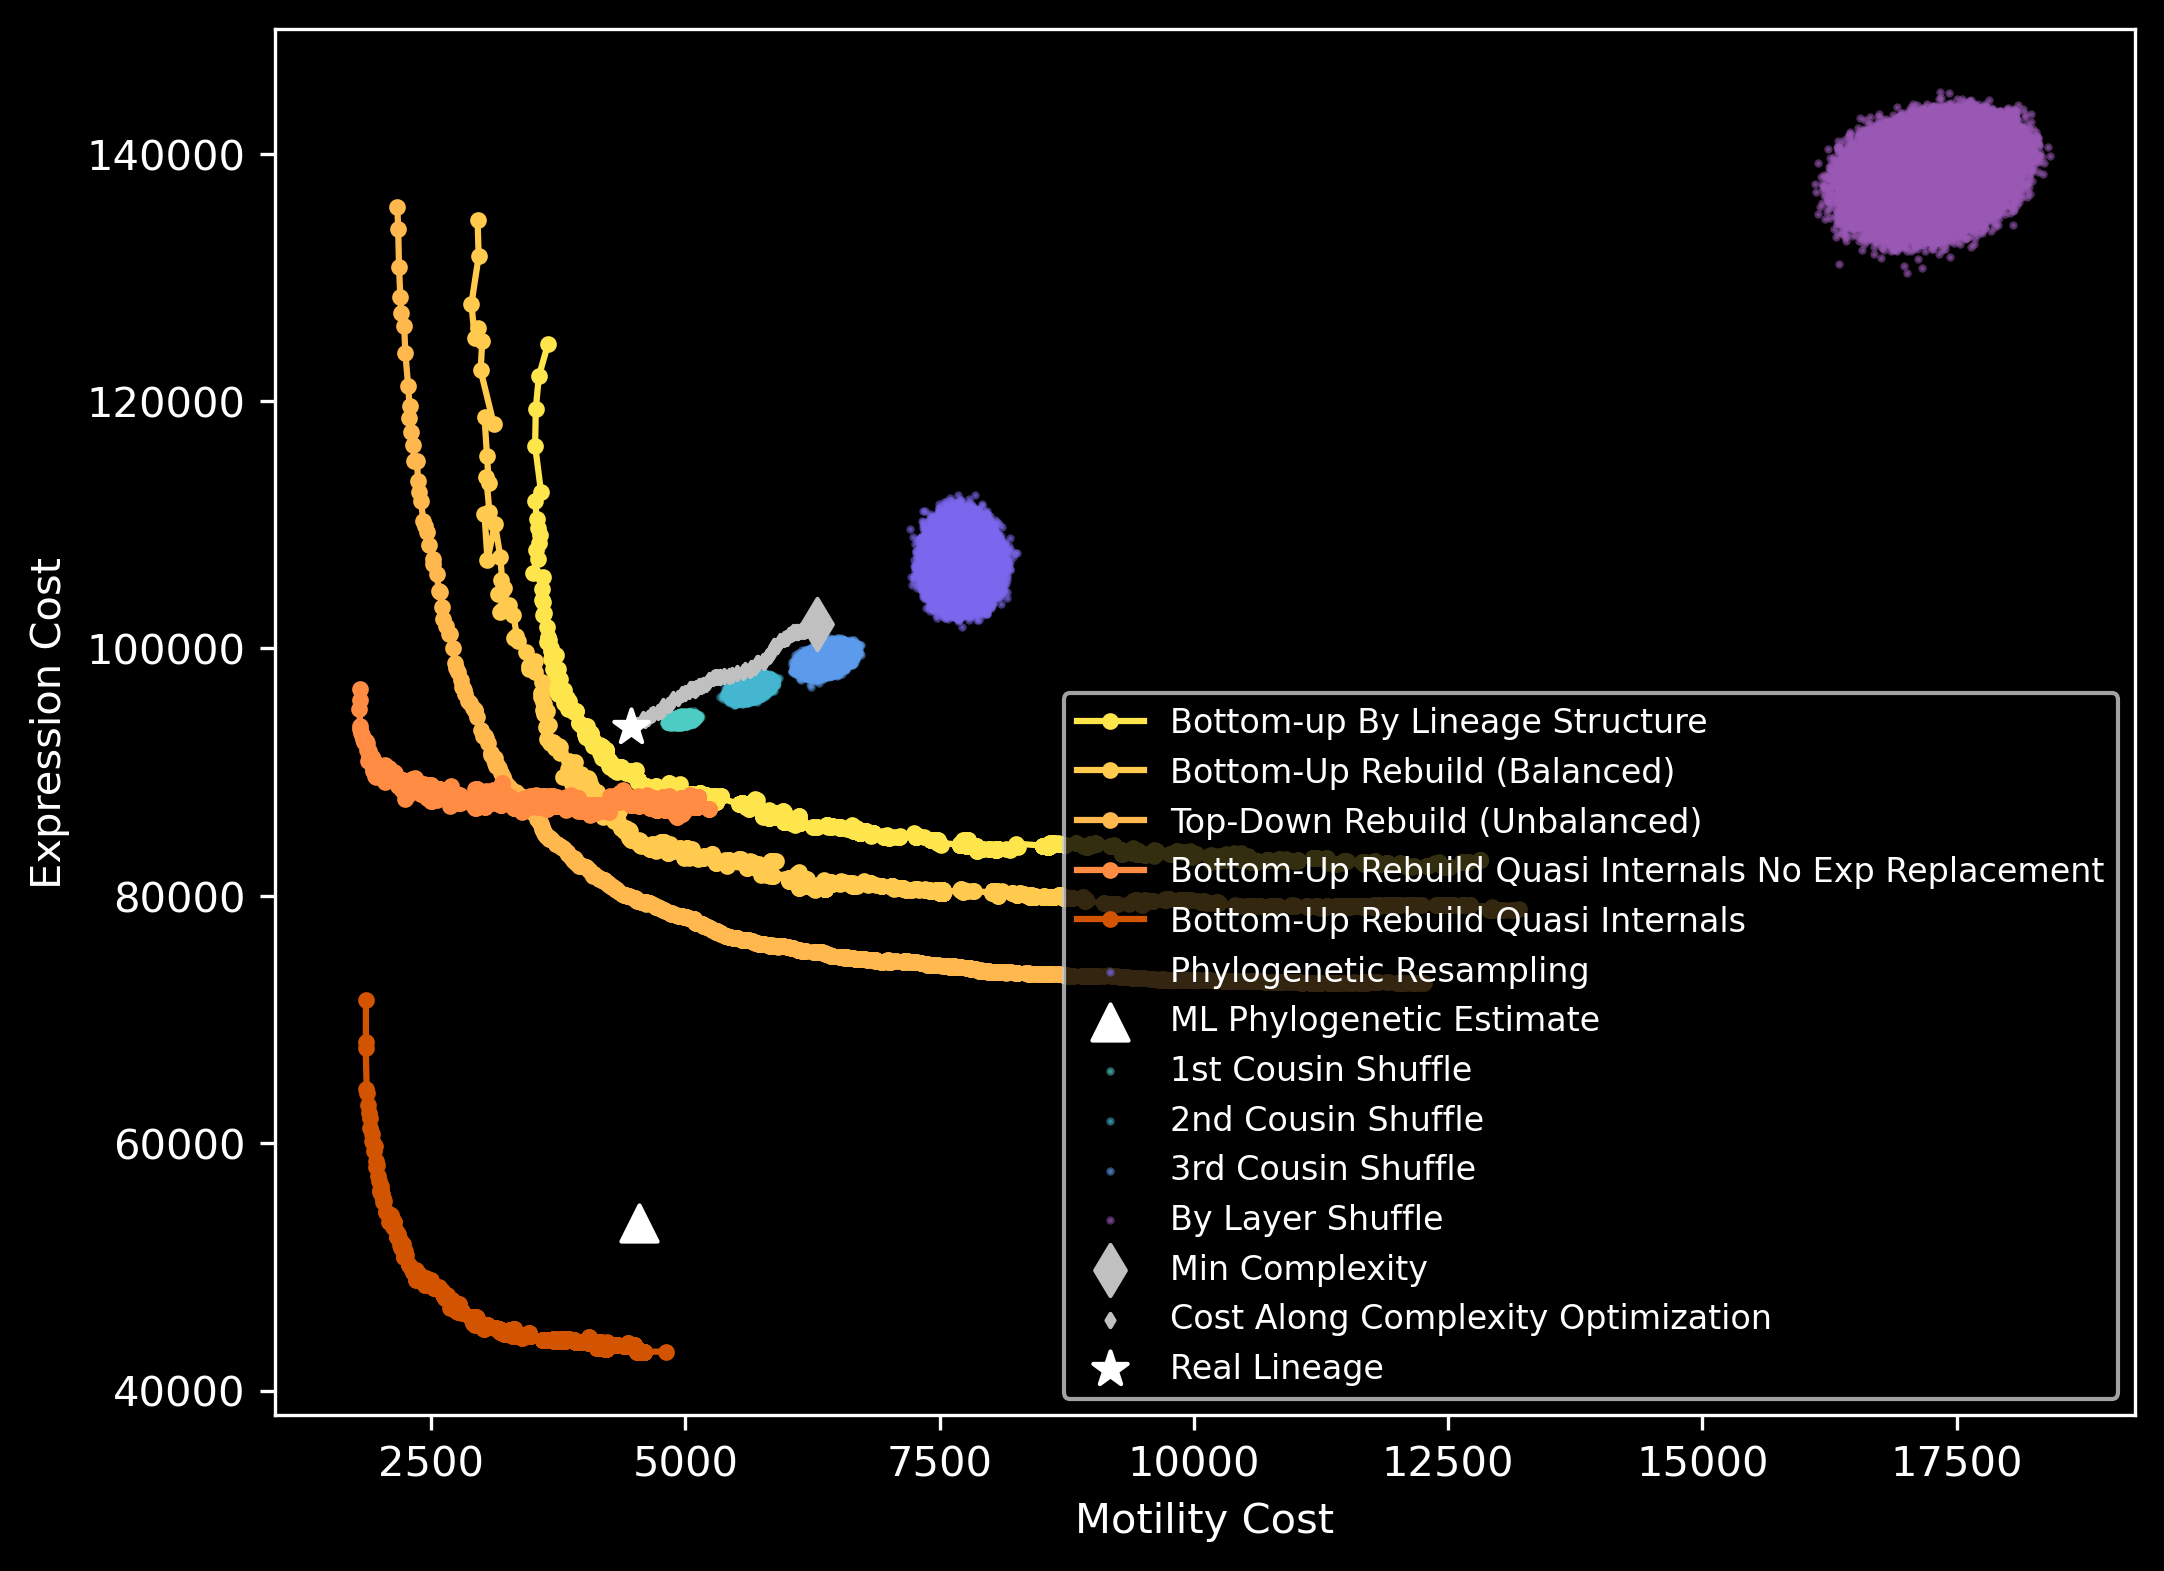

In [37]:
pf_colors = ["#FFE54C", "#FFCA4D", "#FFB84D", "#FF8C42", "#D35400"]
random_colors = ["#4ECDC4", "#45B7D1", "#5D9CEC", "#7B68EE", "#9B59B6"]
complexity_color = "#C0C0C0"

colors = sns.color_palette(n_colors=10)
plt.figure(figsize=(8, 6))
plt.style.use('dark_background')
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, color=pf_colors[0], marker='o', linestyle='-',  markersize=3, label='Bottom-up By Lineage Structure')
plt.plot(pareto_xyz_cost_list_paired_bottom_up_rebuild, pareto_exp_cost_list_paired_bottom_up_rebuild, color=pf_colors[1], marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild (Balanced)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild, pareto_exp_cost_list_top_down_rebuild, marker='o', color=pf_colors[2], linestyle='-',  markersize=3, label='Top-Down Rebuild (Unbalanced)')
plt.plot(pareto_xyz_cost_list_terminal_only_kd_internal_no_replacement, pareto_exp_cost_list_terminal_only_kd_internal_no_replacement, color=pf_colors[3], marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild Quasi Internals No Exp Replacement')
plt.plot(pareto_xyz_cost_list_terminal_only_kd_internal, pareto_exp_cost_list_terminal_only_kd_internal, marker='o', color=pf_colors[4], linestyle='-', markersize=3, label='Bottom-Up Rebuild Quasi Internals')
plt.scatter(phylogeny_sample_xyz_cost, phylogeny_sample_exp_cost, alpha=0.5, s=1, color=random_colors[3], label='Phylogenetic Resampling')
plt.scatter(phylogeny_mean_xyz_cost, phylogeny_mean_exp_cost, color='white', marker='^', label='ML Phylogenetic Estimate', zorder=99, s=75)
plt.scatter(random_xyz_by_1st_cousins, random_exp_by_1st_cousins, alpha=0.5, s=1, color=random_colors[0], label='1st Cousin Shuffle')
plt.scatter(random_xyz_by_2nd_cousins, random_exp_by_2nd_cousins, alpha=0.5, s=1, color=random_colors[1], label='2nd Cousin Shuffle')
plt.scatter(random_xyz_by_3rd_cousins, random_exp_by_3rd_cousins, alpha=0.5, s=1, color=random_colors[2], label='3rd Cousin Shuffle')
plt.scatter(random_xyz_by_layer, random_exp_by_layer, alpha=0.5, s=1, color=random_colors[4], label='By Layer Shuffle')
plt.scatter(min_complexity_xyz_cost, min_complexity_exp_cost, color=complexity_color, marker='d', label='Min Complexity', zorder=99, s=75)
plt.scatter(xyz_cost_complexity_optimization, exp_cost_complexity_optimization, color=complexity_color, marker='d', label='Cost Along Complexity Optimization', s=5)
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='white', marker='*', label='Real Lineage', zorder=99, s=75)
plt.grid(False)
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.legend(loc='best', fontsize=8)
plt.show()

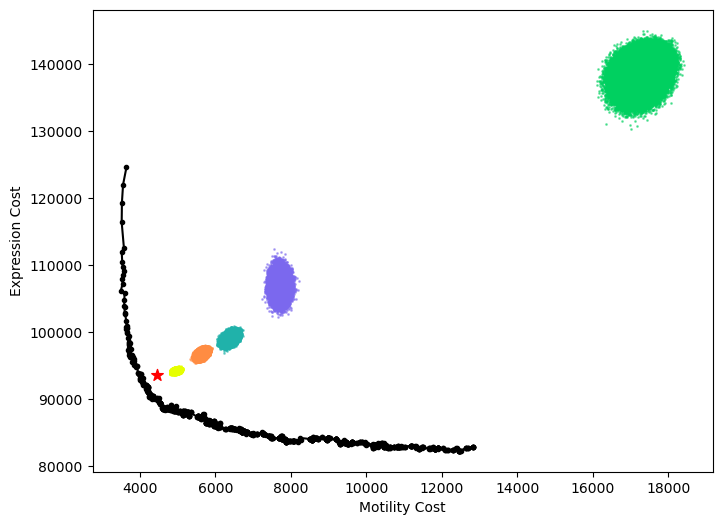

In [50]:
pf_colors = ["#FFE54C", "#FFCA4D", "#FFB84D", "#FF8C42", "#D35400"]
random_colors = ["#E6FF00", "#FF8C42", "#20B2AA", "#7B68EE", "#00D060"]
complexity_color = "#C0C0C0"
colors = sns.color_palette(n_colors=10)
plt.figure(figsize=(8, 6))
# plt.style.use('dark_background')
plt.style.use('default')
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, color="black", marker='o', linestyle='-',  markersize=3, label='Bottom-up By Lineage Structure')
# plt.plot(pareto_xyz_cost_list_paired_bottom_up_rebuild, pareto_exp_cost_list_paired_bottom_up_rebuild, color="black", marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild (Balanced)')
# plt.plot(pareto_xyz_cost_list_top_down_rebuild, pareto_exp_cost_list_top_down_rebuild, marker='o', color=pf_colors[2], linestyle='-',  markersize=3, label='Top-Down Rebuild (Unbalanced)')
# plt.plot(pareto_xyz_cost_list_terminal_only_kd_internal_no_replacement, pareto_exp_cost_list_terminal_only_kd_internal_no_replacement, color=pf_colors[3], marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild Quasi Internals No Exp Replacement')
# plt.plot(pareto_xyz_cost_list_terminal_only_kd_internal, pareto_exp_cost_list_terminal_only_kd_internal, marker='o', color=pf_colors[4], linestyle='-', markersize=3, label='Bottom-Up Rebuild Quasi Internals')
plt.scatter(phylogeny_sample_xyz_cost, phylogeny_sample_exp_cost, alpha=0.5, s=1, color=random_colors[3], label='Phylogenetic Resampling')
# plt.scatter(phylogeny_mean_xyz_cost, phylogeny_mean_exp_cost, color='white', marker='^', label='ML Phylogenetic Estimate', zorder=99, s=75)
plt.scatter(random_xyz_by_1st_cousins, random_exp_by_1st_cousins, alpha=0.5, s=1, color=random_colors[0], label='1st Cousin Shuffle')
plt.scatter(random_xyz_by_2nd_cousins, random_exp_by_2nd_cousins, alpha=0.5, s=1, color=random_colors[1], label='2nd Cousin Shuffle')
plt.scatter(random_xyz_by_3rd_cousins, random_exp_by_3rd_cousins, alpha=0.5, s=1, color=random_colors[2], label='3rd Cousin Shuffle')
plt.scatter(random_xyz_by_layer, random_exp_by_layer, alpha=0.5, s=1, color=random_colors[4], label='By Layer Shuffle')
# plt.scatter(min_complexity_xyz_cost, min_complexity_exp_cost, color=complexity_color, marker='d', label='Min Complexity', zorder=99, s=75)
# plt.scatter(xyz_cost_complexity_optimization, exp_cost_complexity_optimization, color=complexity_color, marker='d', label='Cost Along Complexity Optimization', s=5)
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='red', marker='*', label='Real Lineage', zorder=99, s=75)
plt.grid(False)
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.show()

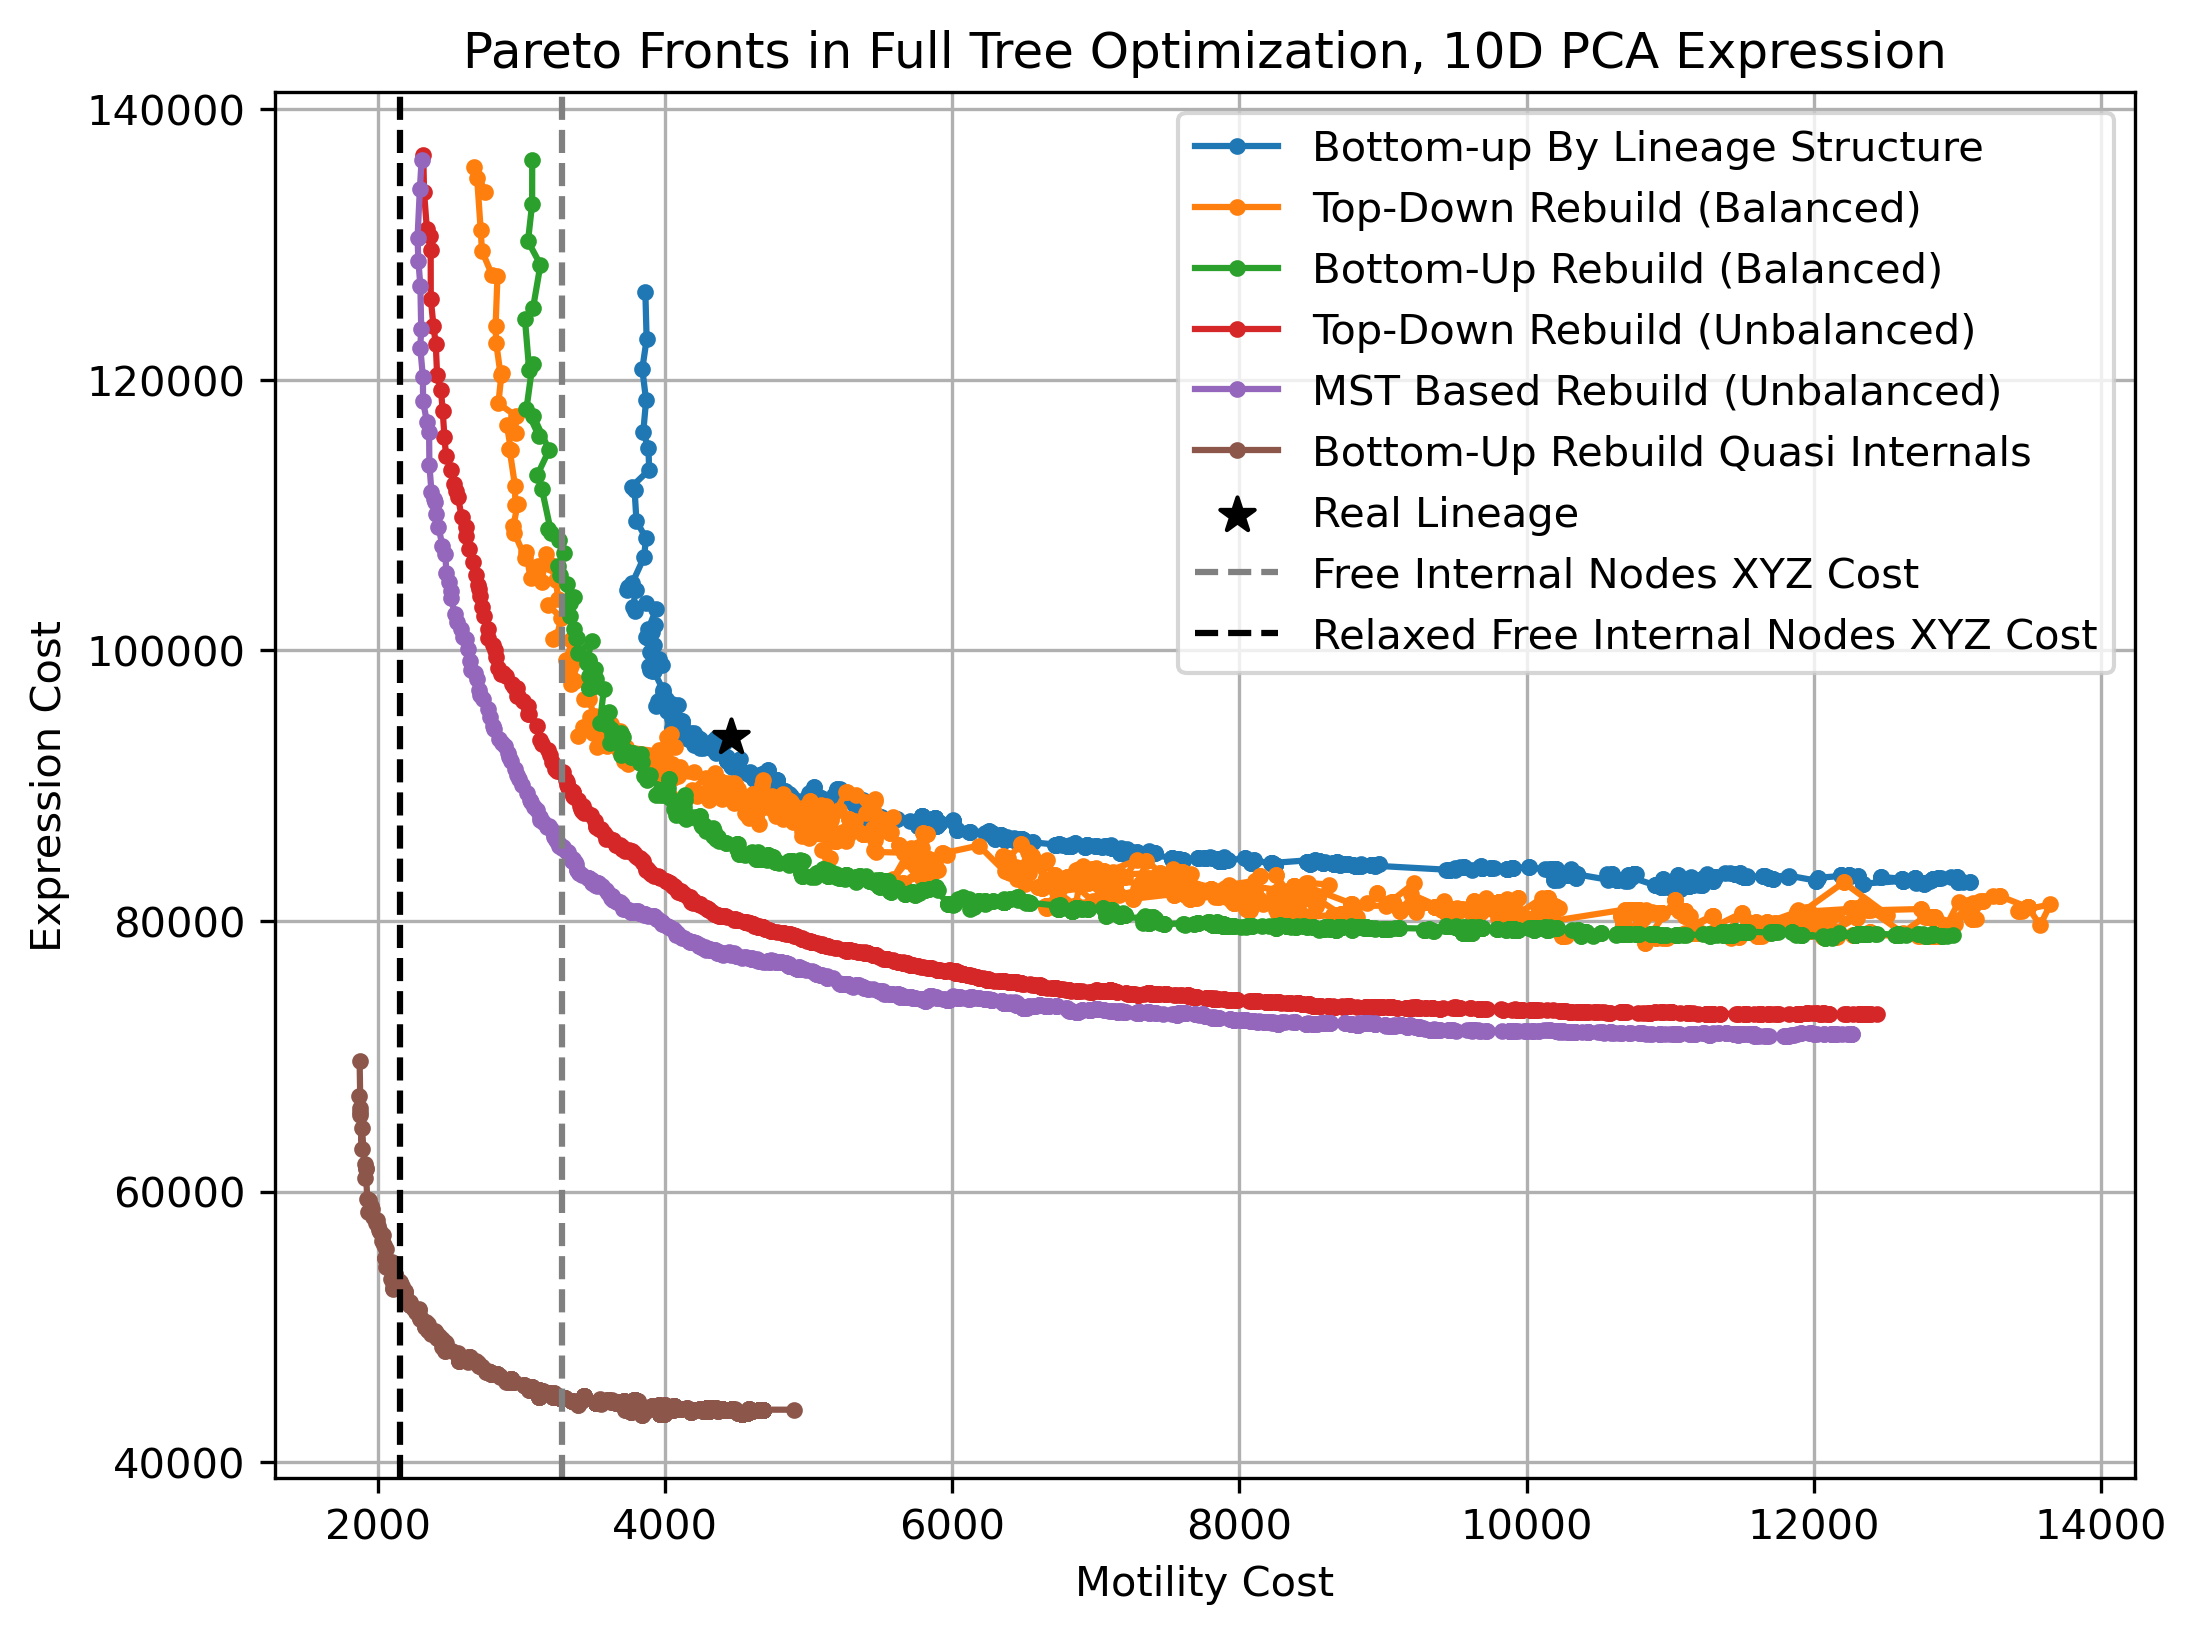

In [32]:
colors = sns.color_palette(n_colors=10)
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-',  markersize=3, label='Bottom-up By Lineage Structure')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_depth_cutoff, pareto_exp_cost_list_top_down_rebuild_depth_cutoff, marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Balanced)')
plt.plot(pareto_xyz_cost_list_paired_bottom_up_rebuild, pareto_exp_cost_list_paired_bottom_up_rebuild, marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild (Balanced)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild, pareto_exp_cost_list_top_down_rebuild, marker='o', linestyle='-',  markersize=3, label='Top-Down Rebuild (Unbalanced)')
plt.plot(pareto_xyz_cost_list_mst, pareto_exp_cost_list_mst, marker='o', linestyle='-',  markersize=3, label='MST Based Rebuild (Unbalanced)')
plt.plot(pareto_xyz_cost_list_terminal_only_kd_internal, pareto_exp_cost_list_terminal_only_kd_internal, marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild Quasi Internals')
# plt.plot(new_pareto_fronts[:,0], new_pareto_fronts[:,1], marker='o', linestyle='-', markersize=3, label='Bottom-Up Linear Assignment')
# plt.plot(pareto_xyz_cost_list_terminal_only_kd_internal_no_exp_replacement, pareto_exp_cost_list_terminal_only_kd_internal_no_exp_replacement, marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild Quasi Internals No Exp Replacement')
# plt.scatter(phylogeny_sample_xyz_cost, phylogeny_sample_exp_cost, alpha=0.5, s=1, color=colors[8], label='Phylogenetic Resampling')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='black', marker='*', label='Real Lineage', zorder=99, s=75)
# plot a vertical line at free_internal_xyz_cost
plt.axvline(x=free_internal_xyz_cost_unrelaxed, color='grey', linestyle='--', label='Free Internal Nodes XYZ Cost')
plt.axvline(x=free_internal_xyz_cost_relaxed, color='black', linestyle='--', label='Relaxed Free Internal Nodes XYZ Cost')
# plt.scatter(phylogeny_mean_xyz_cost, phylogeny_mean_exp_cost, color='black', marker='^', label='ML Phylogenetic Estimate', zorder=99, s=75)
# plt.scatter(min_complexity_xyz_cost, min_complexity_exp_cost, color='grey', marker='d', label='Min Complexity', zorder=99, s=75)
# plt.scatter(xyz_cost_complexity_optimization, exp_cost_complexity_optimization, color='grey', marker='d', label='Cost Along Complexity Optimization', s=5)
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.title(f'Pareto Fronts in Full Tree Optimization, 10D PCA Expression')
plt.grid(True)
plt.legend()
plt.show()

/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


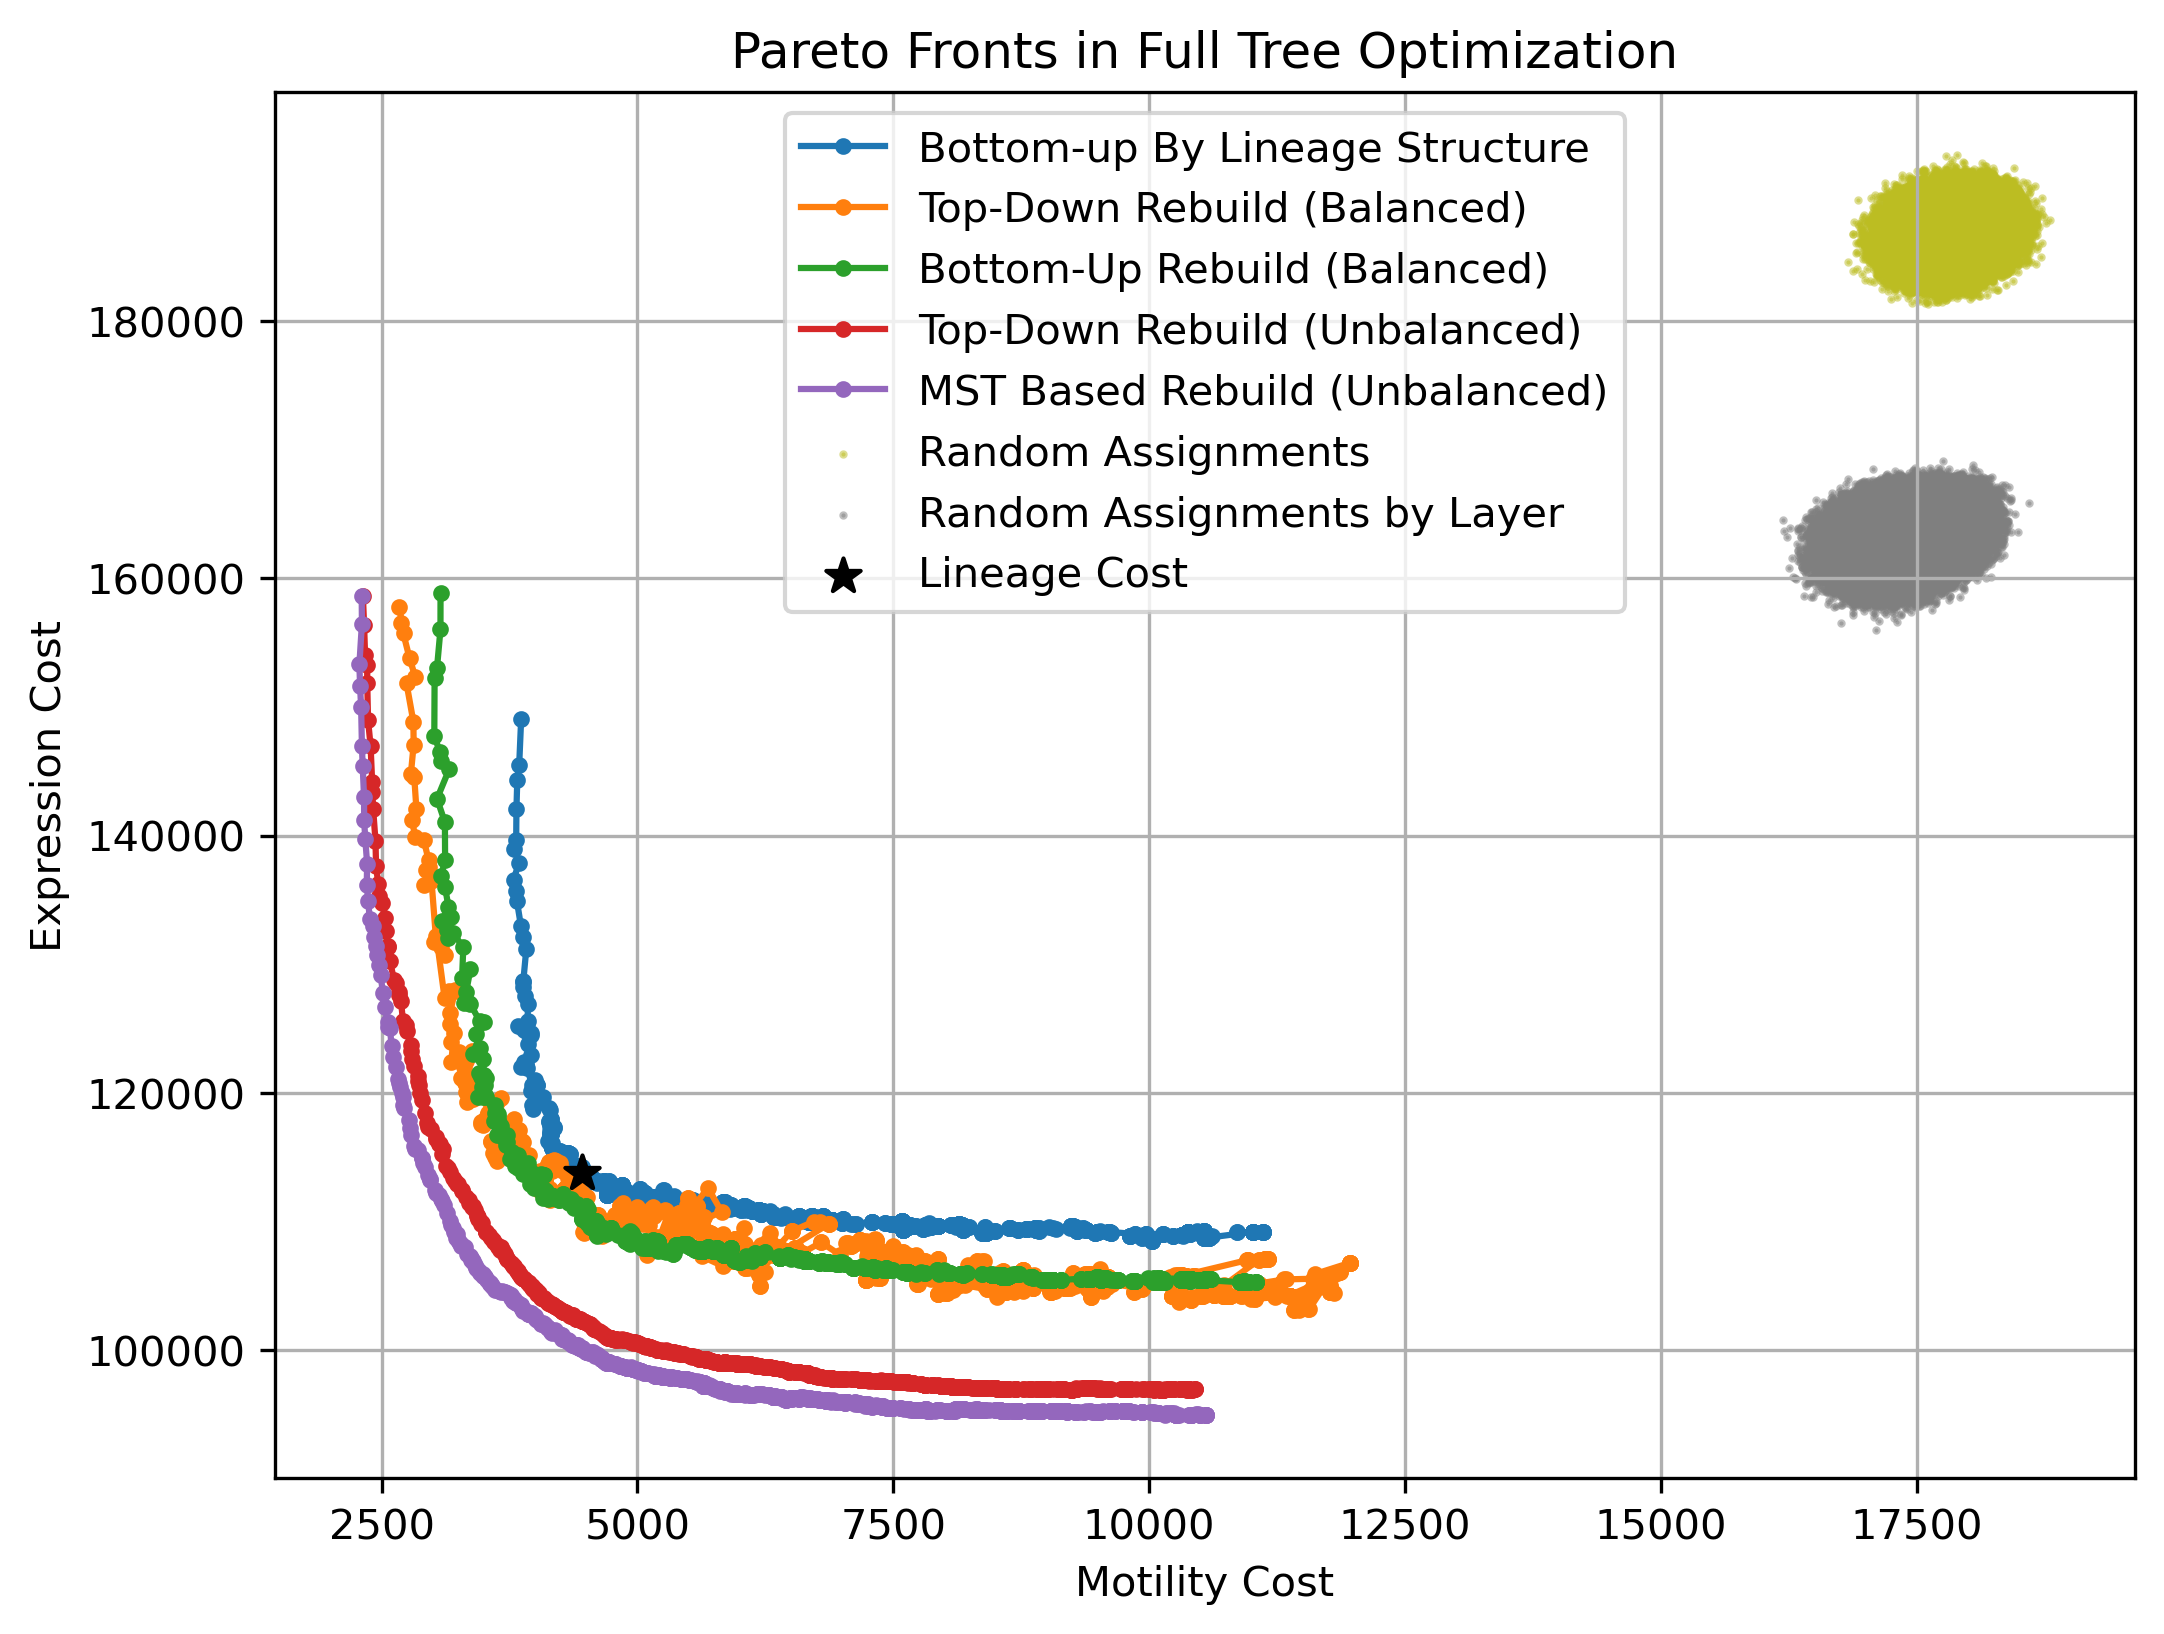

In [ ]:
random_assign_xyz_costs = [cost[0] for cost in random_assign_res]
random_assign_exp_costs = [cost[1] for cost in random_assign_res]
# random_rebuild_xyz_costs = [cost[0] for cost in random_res]
# random_rebuild_exp_costs = [cost[1] for cost in random_res]
colors = sns.color_palette(n_colors=10)
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-',  markersize=3, label='Bottom-up By Lineage Structure')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_depth_cutoff, pareto_exp_cost_list_top_down_rebuild_depth_cutoff, marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Balanced)')
plt.plot(pareto_xyz_cost_list_paired_bottom_up_rebuild, pareto_exp_cost_list_paired_bottom_up_rebuild, marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild (Balanced)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild, pareto_exp_cost_list_top_down_rebuild, marker='o', linestyle='-',  markersize=3, label='Top-Down Rebuild (Unbalanced)')
plt.plot(pareto_xyz_cost_list_mst, pareto_exp_cost_list_mst, marker='o', linestyle='-',  markersize=3, label='MST Based Rebuild (Unbalanced)')
plt.scatter(random_assign_xyz_costs, random_assign_exp_costs, alpha=0.5, s=1, color=colors[8], label='Random Assignments')
plt.scatter(random_xyz_by_layer, random_exp_by_layer, alpha=0.5, s=1, color=colors[7], label='Random Assignments by Layer')
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='black', marker='*', label='Lineage Cost', zorder=99, s=75)
plt.title(f'Pareto Fronts in Full Tree Optimization')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
results_df = pd.DataFrame({
    'Bottom-up By Layer XYZ Cost': pareto_xyz_cost_list_by_layer,
    'Bottom-up By Layer Exp Cost': pareto_exp_cost_list_by_layer,
    'Top-Down Rebuild XYZ Cost': pareto_xyz_cost_list_top_down_rebuild,
    'Top-Down Rebuild Exp Cost': pareto_exp_cost_list_top_down_rebuild,
    'Paired Bottom-Up Rebuild XYZ Cost': pareto_xyz_cost_list_paired_bottom_up_rebuild,
    'Paired Bottom-Up Rebuild Exp Cost': pareto_exp_cost_list_paired_bottom_up_rebuild,
    'MST Based Rebuild XYZ Cost': pareto_xyz_cost_list_mst,
    'MST Based Rebuild Exp Cost': pareto_exp_cost_list_mst,
    'Top-Down Rebuild (Hard Depth Cutoff) XYZ Cost': pareto_xyz_cost_list_top_down_rebuild_depth_cutoff,
    'Top-Down Rebuild (Hard Depth Cutoff) Exp Cost': pareto_exp_cost_list_top_down_rebuild_depth_cutoff
})
results_df.to_csv('output/internal_opt/embryo/10_pca_247_l2/pareto_comparison.csv', index=False)

In [38]:
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = [cost[0] for cost in pareto_list_top_down_rebuild_depth_cutoff]
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = [cost[1] for cost in pareto_list_top_down_rebuild_depth_cutoff]
depth_restricted_top_down_rebuild_complexity_scores = [cost[2] for cost in pareto_list_top_down_rebuild_depth_cutoff]

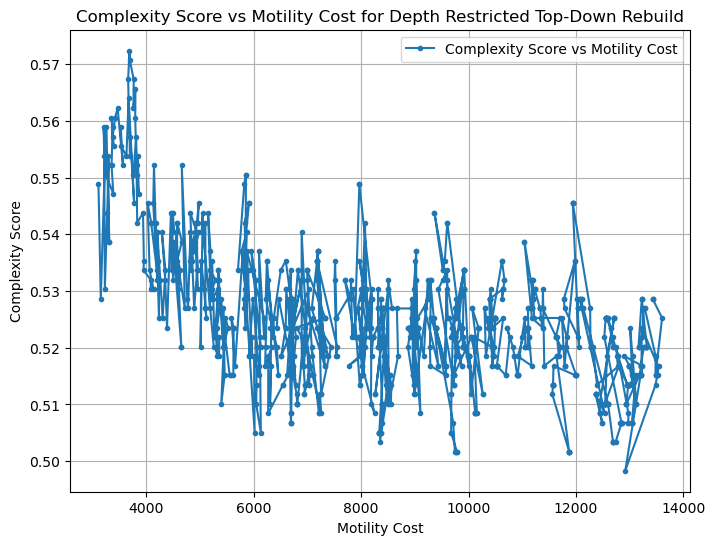

In [39]:
# plot depth_restricted_top_down_rebuild_complexity_scores against pareto_exp_xyz_list_top_down_rebuild_depth_cutoff
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_top_down_rebuild_depth_cutoff, depth_restricted_top_down_rebuild_complexity_scores, marker='o', linestyle='-',  markersize=3, label='Complexity Score vs Motility Cost')
plt.xlabel('Motility Cost')
plt.ylabel('Complexity Score')
plt.title(f'Complexity Score vs Motility Cost for Depth Restricted Top-Down Rebuild')
plt.grid(True)
plt.legend()
plt.show()

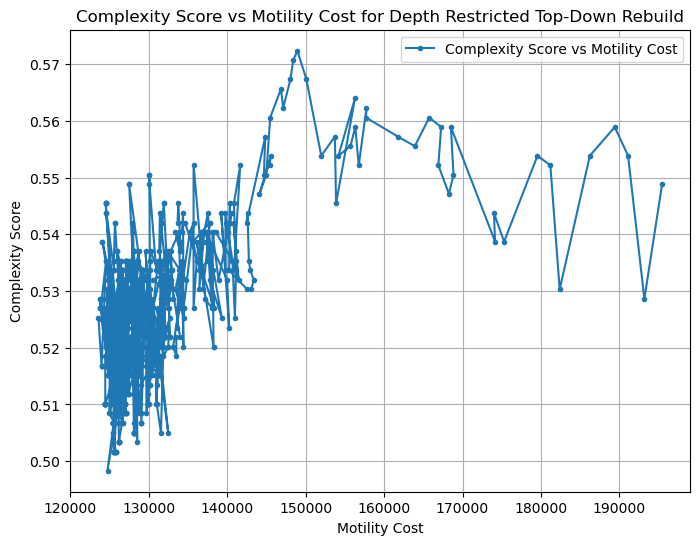

In [40]:
# plot depth_restricted_top_down_rebuild_complexity_scores against pareto_exp_xyz_list_top_down_rebuild_depth_cutoff
plt.figure(figsize=(8, 6))
plt.plot(pareto_exp_cost_list_top_down_rebuild_depth_cutoff, depth_restricted_top_down_rebuild_complexity_scores, marker='o', linestyle='-',  markersize=3, label='Complexity Score vs Motility Cost')
plt.xlabel('Motility Cost')
plt.ylabel('Complexity Score')
plt.title(f'Complexity Score vs Motility Cost for Depth Restricted Top-Down Rebuild')
plt.grid(True)
plt.legend()
plt.show()

In [40]:

terminal_lineage_ids = [opt.lineage_tree.lineage_id_mapping[tree_id] for tree_id in opt.terminal_tree_ids]
internal_lineage_ids = [opt.lineage_tree.lineage_id_mapping[tree_id] for tree_id in opt.internal_tree_ids]
res0 = opt.terminal_only_rebuild(terminal_lineage_ids=terminal_lineage_ids, internal_lineage_ids=internal_lineage_ids, use_kd_tree=True, idx=0)
res1 = opt.terminal_only_rebuild(terminal_lineage_ids=terminal_lineage_ids, internal_lineage_ids=internal_lineage_ids, use_kd_tree=True, idx=1001)

In [42]:
terminal_path_lists = []
for tree_id in opt.terminal_tree_ids:
    cur_id = tree_id
    terminal_path = [opt.lineage_tree.lineage_id_mapping[tree_id]]
    while opt.lineage_tree.parent_list[cur_id] != -1:
        cur_id = opt.lineage_tree.parent_list[cur_id]
        terminal_path.append(opt.lineage_tree.lineage_id_mapping[cur_id])
    terminal_path_lists.append(terminal_path)


min_cosines = []
mean_cosines = []
for path in terminal_path_lists:
    min_cosine = 1.0
    cosine_values = []
    for i in range(1, len(path) -1):
        vec1 = lineage_exp_mat[path[i]] - lineage_exp_mat[path[i -1]]
        vec2 = lineage_exp_mat[path[i +1]] - lineage_exp_mat[path[i]]
        cos_angle = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2) + 1e-10)
        if np.isnan(cos_angle):
            continue
        min_cosine = min(min_cosine, cos_angle)
        cosine_values.append(cos_angle)
    min_cosines.append(min_cosine)
    mean_cosines.append(np.mean(cosine_values[:8]))

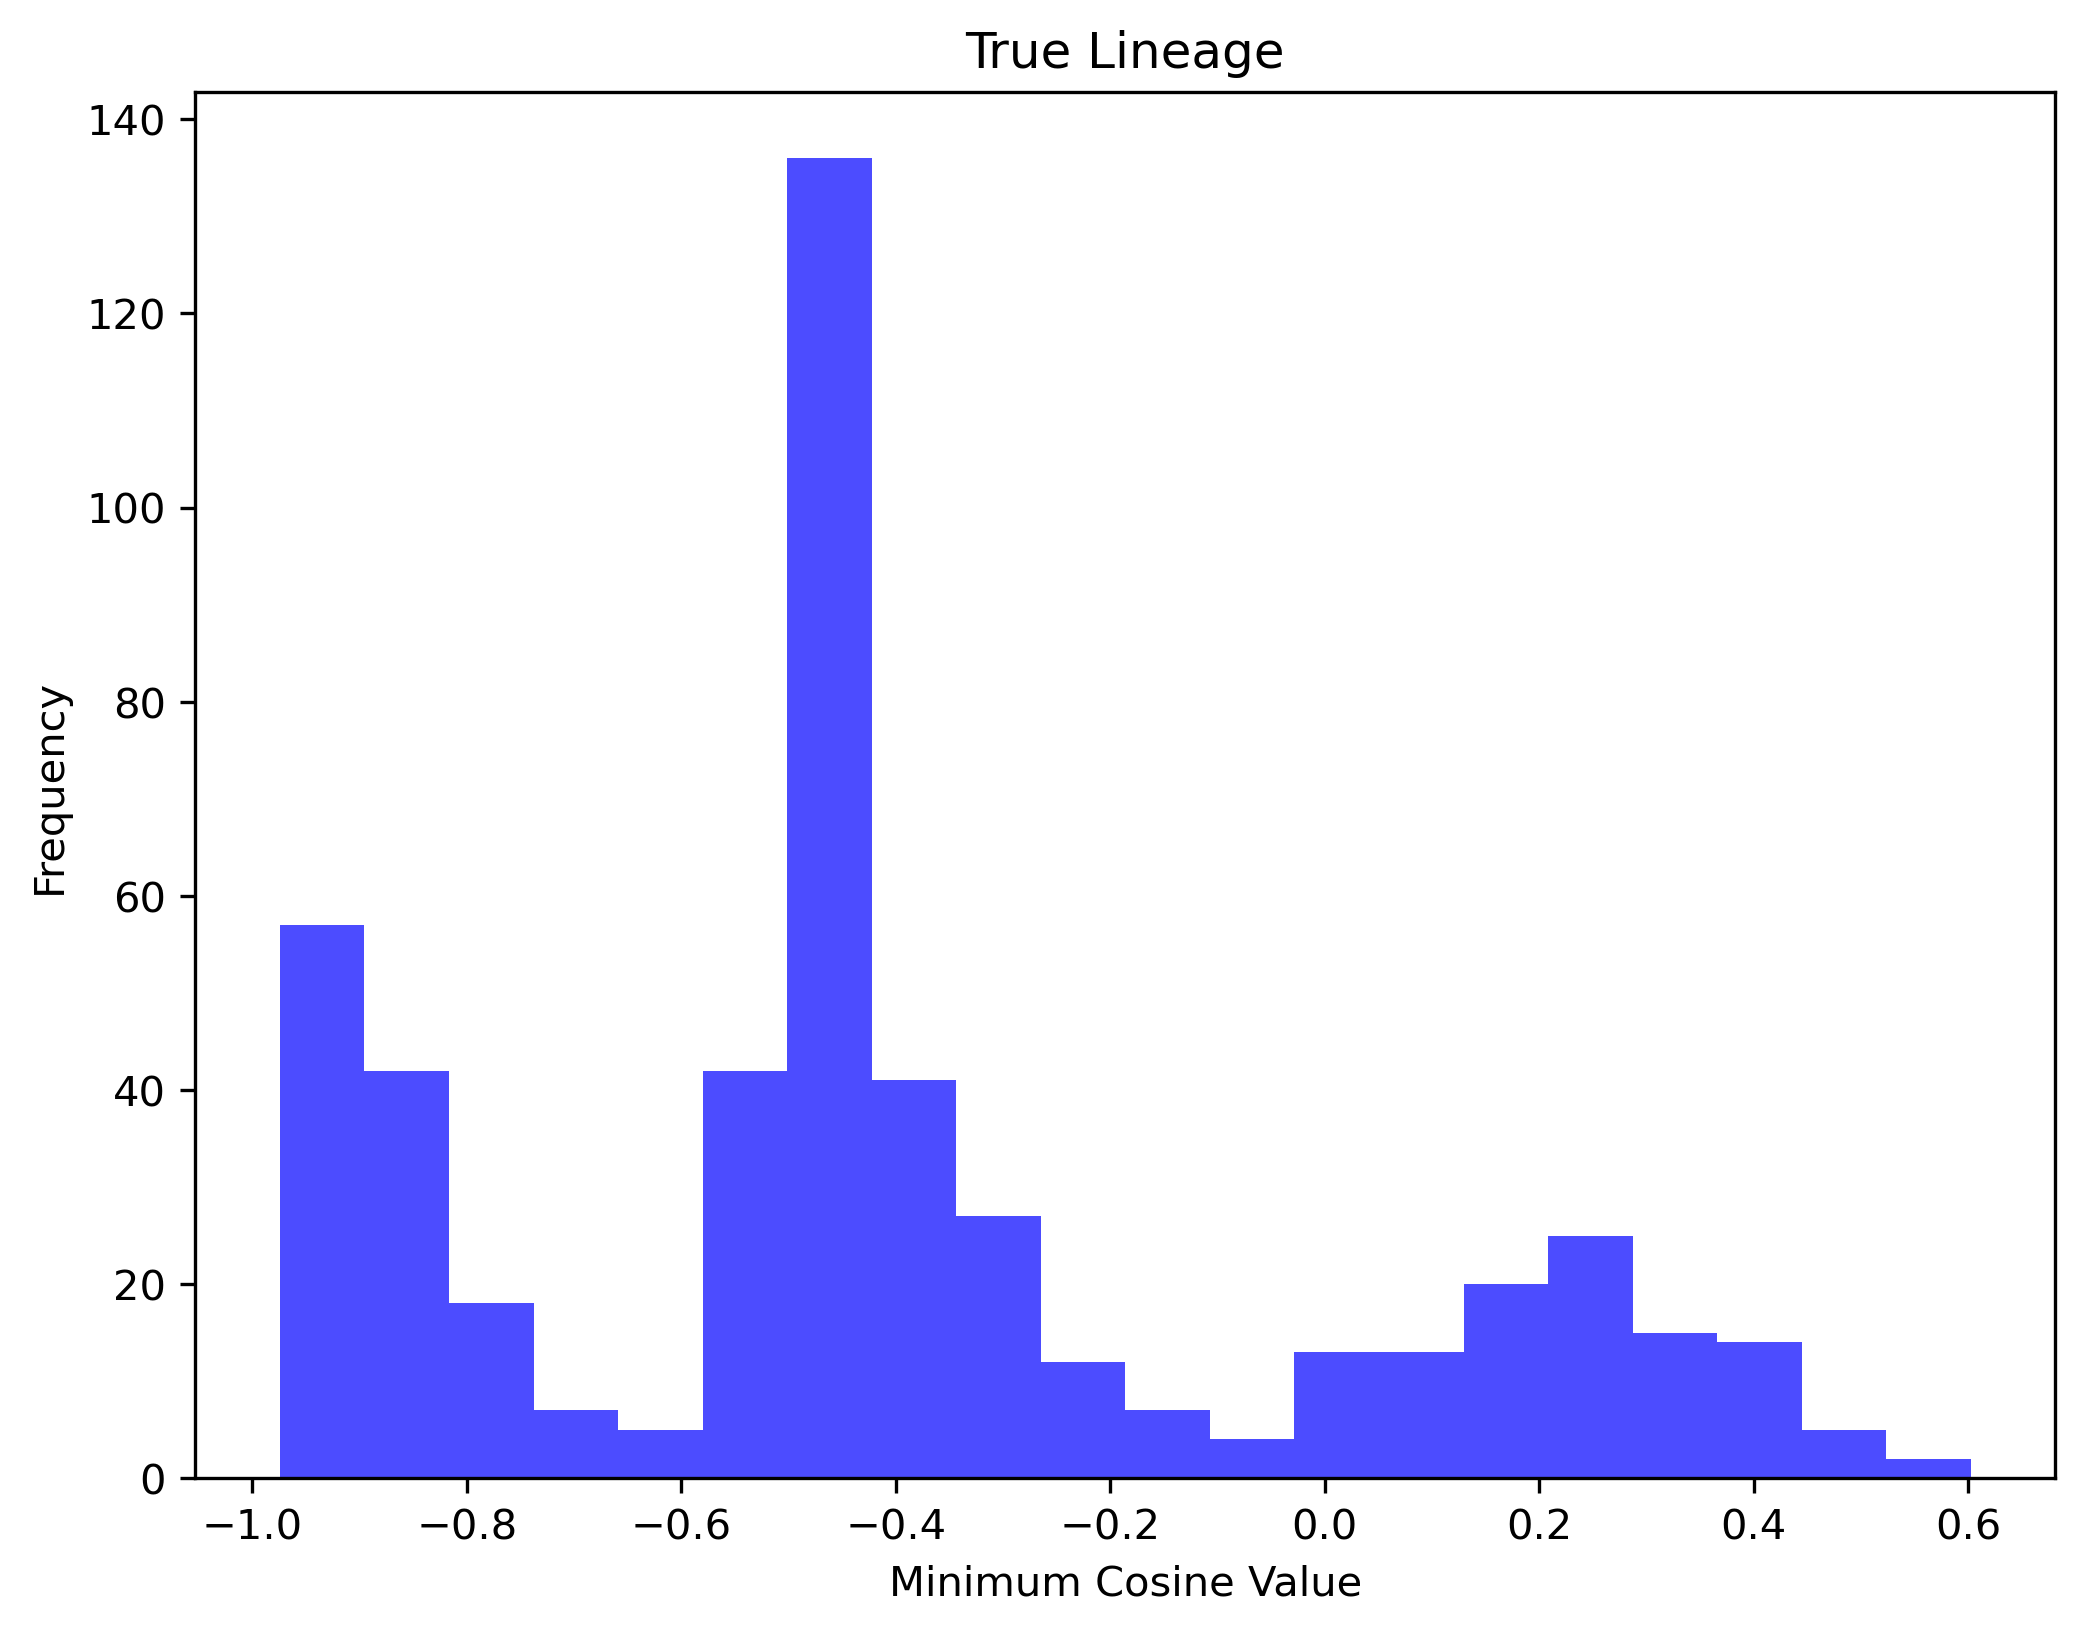

In [43]:
# plot a histogram of mean_cosines
plt.figure(figsize=(8, 6))
plt.hist(min_cosines, bins=20, color='blue', alpha=0.7)
plt.xlabel('Minimum Cosine Value')
plt.ylabel('Frequency')
plt.title('True Lineage')
plt.show()

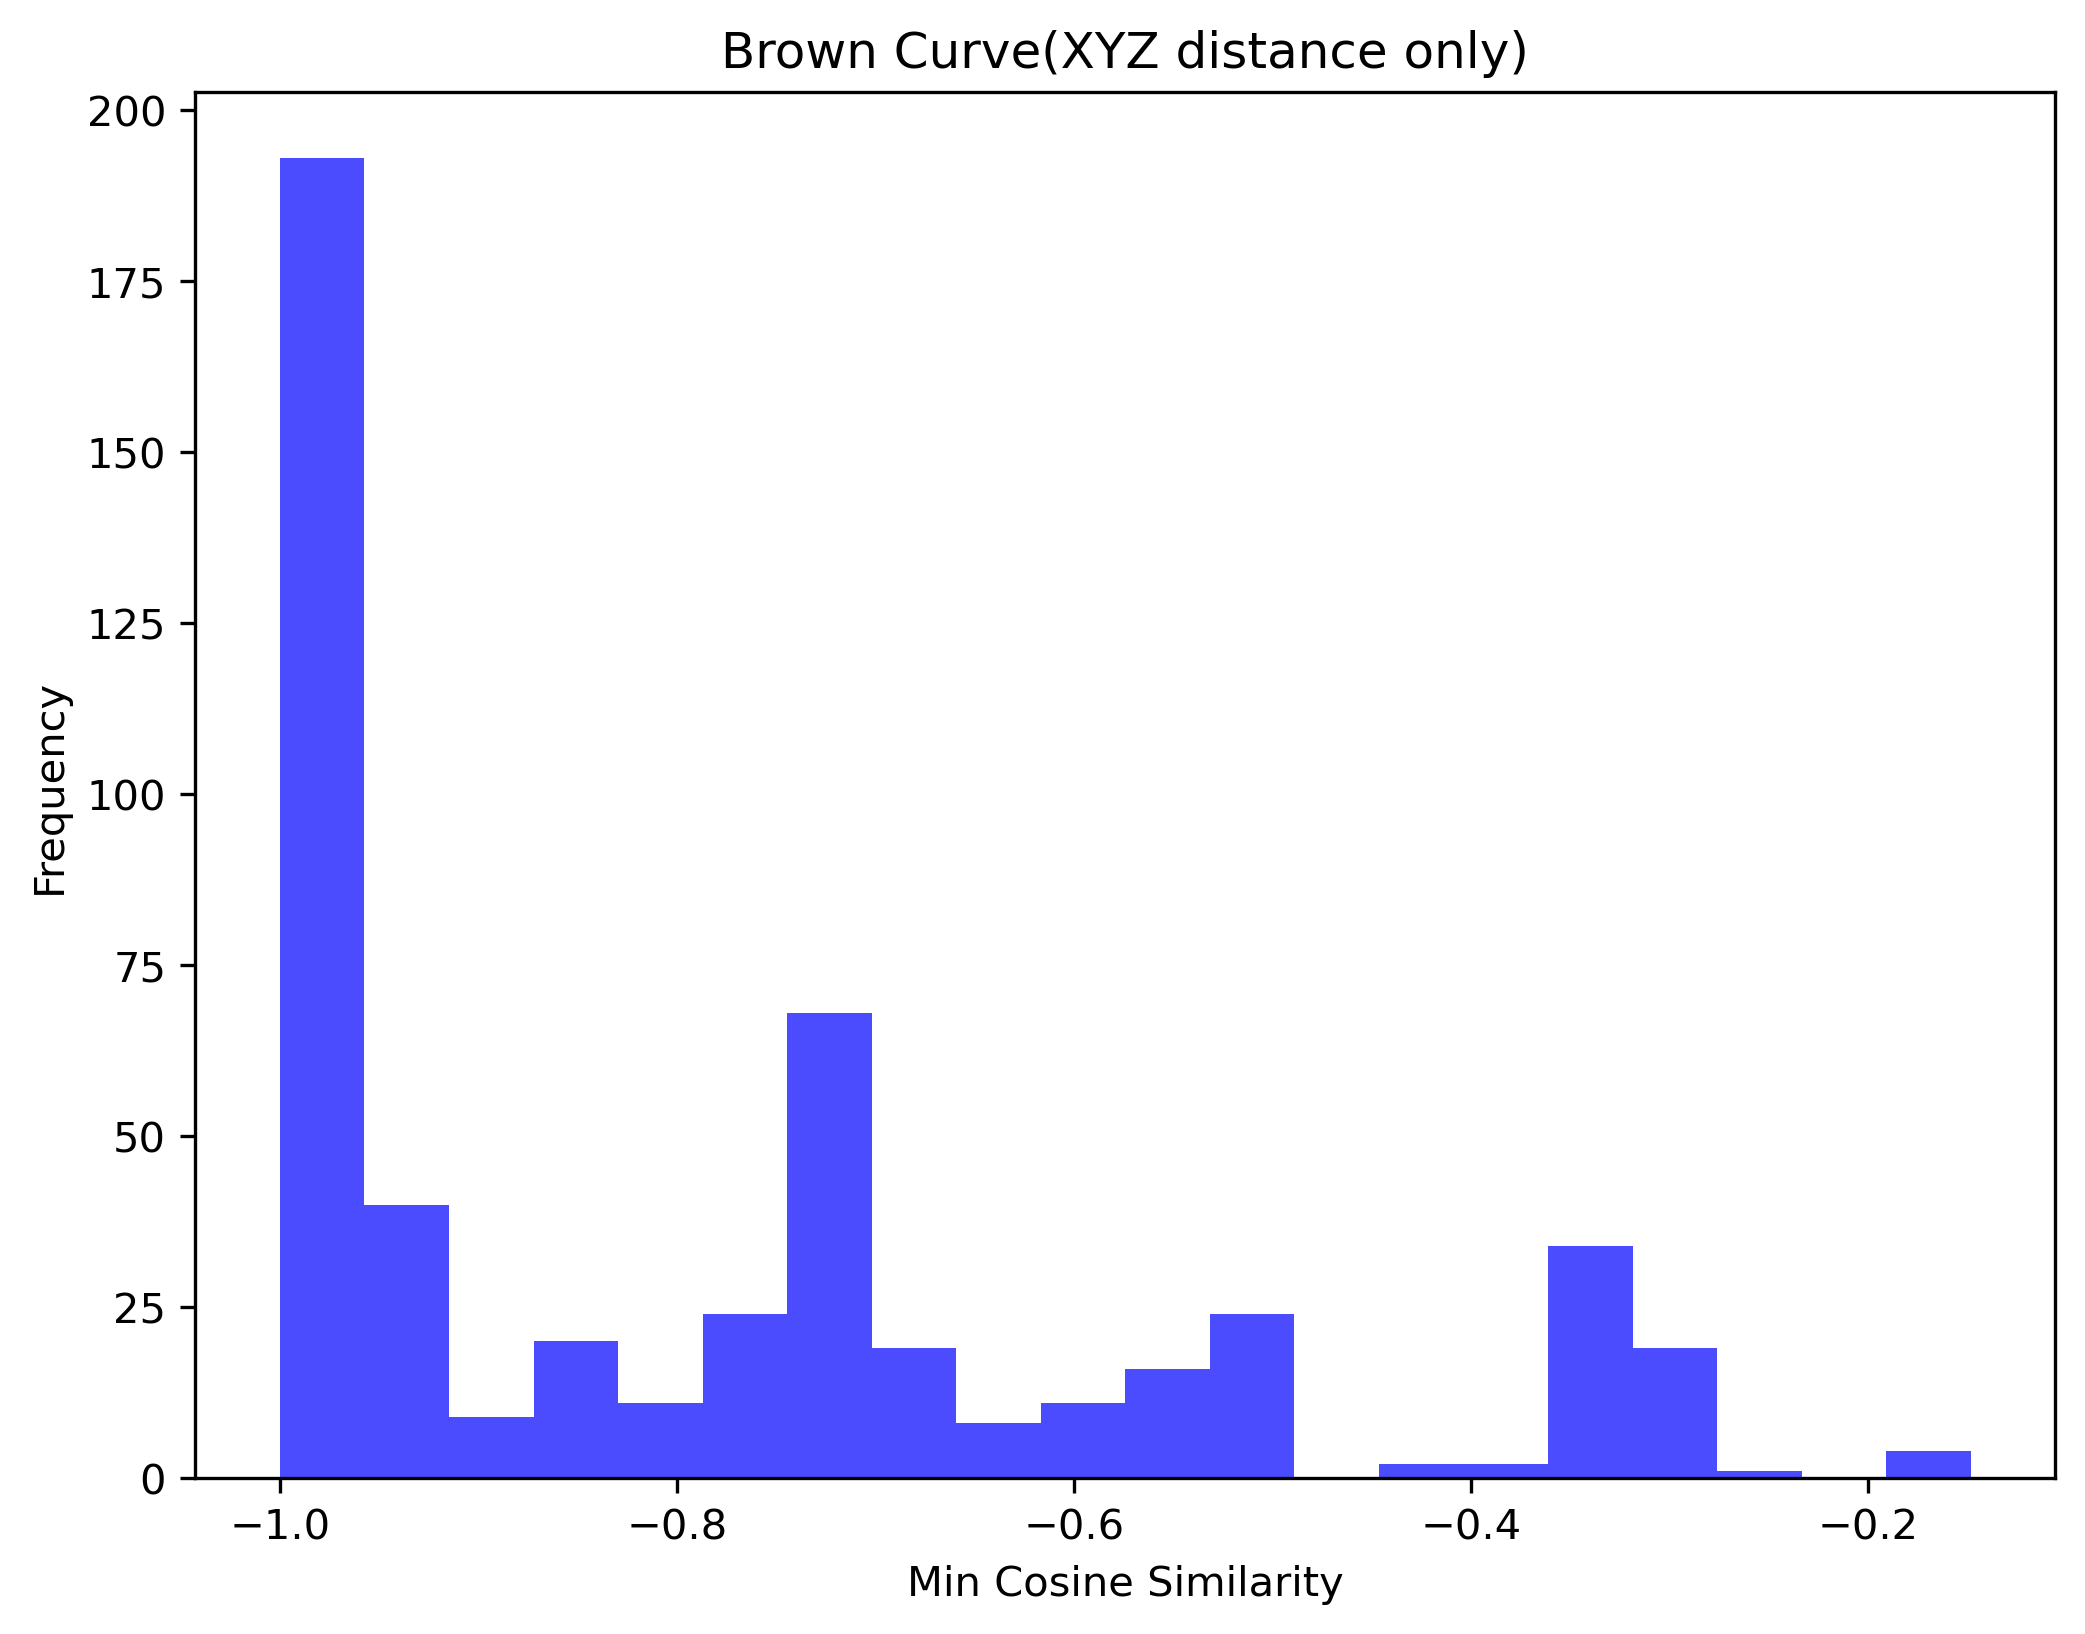

In [44]:

plt.figure(figsize=(8, 6))
plt.hist(res1[4], bins=20, color='blue', alpha=0.7)
plt.xlabel('Min Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Brown Curve(XYZ distance only)')
plt.show()

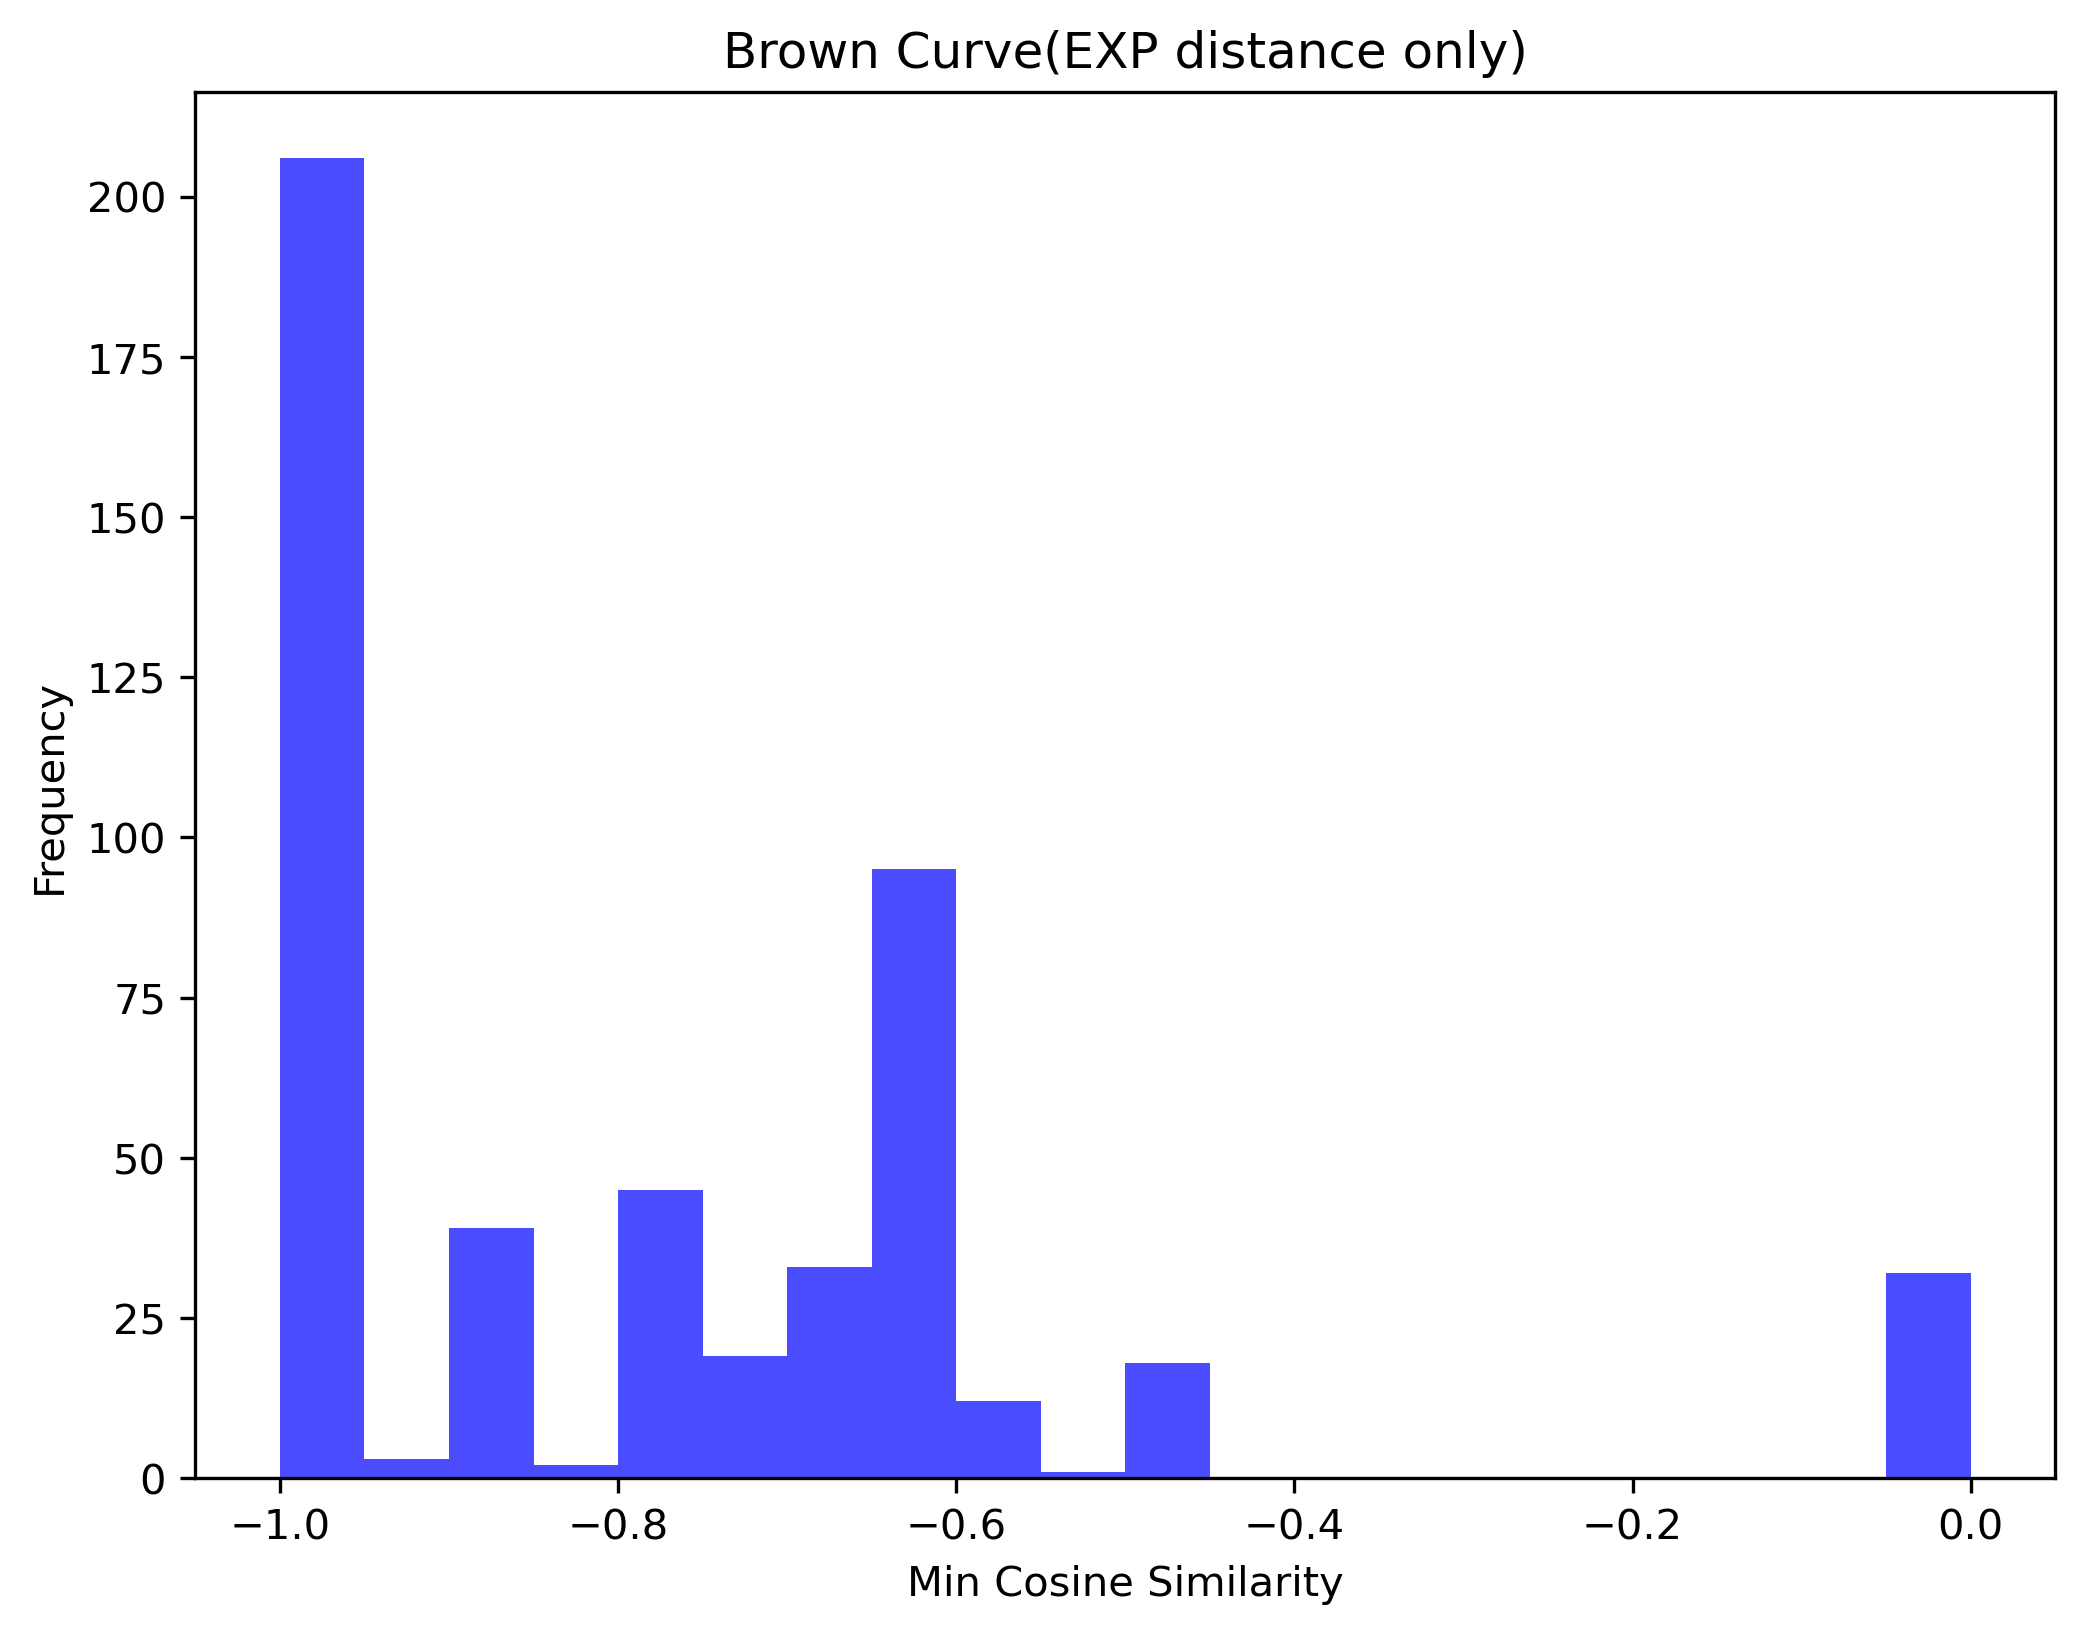

In [45]:

plt.figure(figsize=(8, 6))
plt.hist(res0[4], bins=20, color='blue', alpha=0.7)
plt.xlabel('Min Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Brown Curve(EXP distance only)')
plt.show()

In [36]:
from scipy.stats import ttest_rel
ttest_rel(min_consines, res1[4])

TtestResult(statistic=np.float64(17.07346942173533), pvalue=np.float64(1.7936843364686723e-53), df=np.int64(594))

In [37]:
pareto_list_terminal_only_kd_internal = opt.terminal_only_rebuild_runner(use_kd_tree=True)

Computing pareto costs 1/2:   0%|          | 0/500 [00:00<?, ?it/s]

Computing pareto costs 2/2:   0%|          | 0/501 [00:00<?, ?it/s]

In [38]:
# save pareto_list_terminal_only_kd_internal as a pandas dataframe
pareto_df_terminal_only_kd_internal = pd.DataFrame(pareto_list_terminal_only_kd_internal, columns=['xyz_cost', 'exp_cost', 'internal_selection_count', 'complexity_score', 'min_consines', 'mean_consines'])
pareto_df_terminal_only_kd_internal.to_csv('output/internal_opt/embryo2/s3_280_l2/pareto_terminal_only_kd_internal.tsv', index=False, sep='\t')

In [ ]:
pareto_df_terminal_only_kd_internal = pd.read_csv('output/internal_opt/embryo2/P2/pareto_terminal_only_kd_internal.tsv', sep='\t')
pareto_xyz_cost_list_terminal_only_kd_internal = pareto_df_terminal_only_kd_internal['xyz_cost'].tolist()
pareto_exp_cost_list_terminal_only_kd_internal = pareto_df_terminal_only_kd_internal['exp_cost'].tolist()
results_df = pd.read_csv('output/internal_opt/embryo2/P2/pareto_comparison.csv')
pareto_xyz_cost_list_by_layer = results_df["Bottom-up By Layer XYZ Cost"].tolist()
pareto_exp_cost_list_by_layer = results_df["Bottom-up By Layer Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild = results_df["Top-Down Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild = results_df["Top-Down Rebuild Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = results_df["Top-Down Rebuild (Hard Depth Cutoff) XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = results_df["Top-Down Rebuild (Hard Depth Cutoff) Exp Cost"].tolist()
pareto_xyz_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild Exp Cost"].tolist()    
pareto_xyz_cost_list_mst = results_df["MST Based Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_mst = results_df["MST Based Rebuild Exp Cost"].tolist()

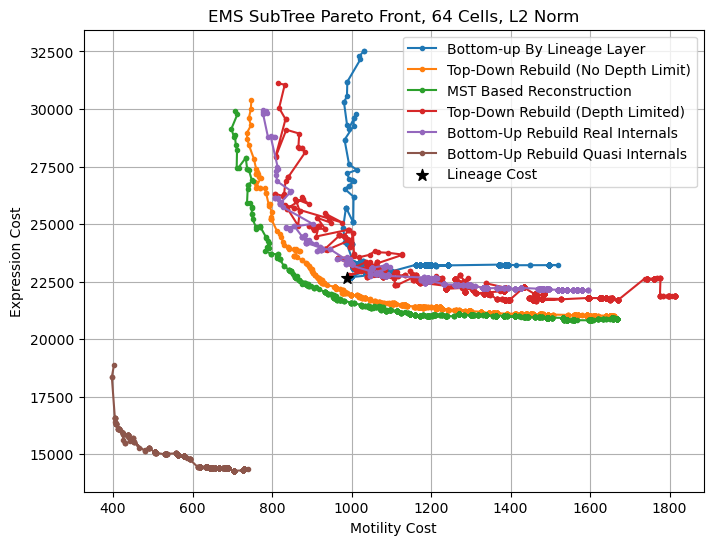

In [40]:
pareto_xyz_cost_list_by_layer = [cost[0] for cost in pareto_list_by_layer]
pareto_exp_cost_list_by_layer = [cost[1] for cost in pareto_list_by_layer]
pareto_xyz_cost_list_top_down_rebuild = [cost[0] for cost in pareto_list_top_down_rebuild]
pareto_exp_cost_list_top_down_rebuild = [cost[1] for cost in pareto_list_top_down_rebuild]
pareto_xyz_cost_list_mst = [cost[0] for cost in pareto_mst_list]
pareto_exp_cost_list_mst = [cost[1] for cost in pareto_mst_list]
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = [cost[0] for cost in pareto_list_top_down_rebuild_depth_cutoff]
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = [cost[1] for cost in pareto_list_top_down_rebuild_depth_cutoff]
pareto_xyz_cost_list_paired_bottom_up_rebuild = [cost[0] for cost in pareto_list_paired_bottom_up_rebuild]
pareto_exp_cost_list_paired_bottom_up_rebuild = [cost[1] for cost in pareto_list_paired_bottom_up_rebuild]
pareto_xyz_cost_list_terminal_only_kd_internal = [cost[0] for cost in pareto_list_terminal_only_kd_internal]
pareto_exp_cost_list_terminal_only_kd_internal = [cost[1] for cost in pareto_list_terminal_only_kd_internal]
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-',  markersize=3, label='Bottom-up By Lineage Layer')
plt.plot(pareto_xyz_cost_list_top_down_rebuild, pareto_exp_cost_list_top_down_rebuild, marker='o', linestyle='-',  markersize=3, label='Top-Down Rebuild (No Depth Limit)')
plt.plot(pareto_xyz_cost_list_mst, pareto_exp_cost_list_mst, marker='o', linestyle='-',  markersize=3, label='MST Based Reconstruction')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_depth_cutoff, pareto_exp_cost_list_top_down_rebuild_depth_cutoff, marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Depth Limited)')
plt.plot(pareto_xyz_cost_list_paired_bottom_up_rebuild, pareto_exp_cost_list_paired_bottom_up_rebuild, marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild Real Internals')
plt.plot(pareto_xyz_cost_list_terminal_only_kd_internal, pareto_exp_cost_list_terminal_only_kd_internal, marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild Quasi Internals')
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='black', marker='*', label='Lineage Cost', zorder=99, s=75)
plt.title(f'EMS SubTree Pareto Front, 64 Cells, L2 Norm')
plt.grid(True)
plt.legend()
plt.show()

In [41]:
results_df = pd.DataFrame({
    'Bottom-up By Layer XYZ Cost': pareto_xyz_cost_list_by_layer,
    'Bottom-up By Layer Exp Cost': pareto_exp_cost_list_by_layer,
    'Top-Down Rebuild XYZ Cost': pareto_xyz_cost_list_top_down_rebuild,
    'Top-Down Rebuild Exp Cost': pareto_exp_cost_list_top_down_rebuild,
    'Paired Bottom-Up Rebuild XYZ Cost': pareto_xyz_cost_list_paired_bottom_up_rebuild,
    'Paired Bottom-Up Rebuild Exp Cost': pareto_exp_cost_list_paired_bottom_up_rebuild,
    'MST Based Rebuild XYZ Cost': pareto_xyz_cost_list_mst,
    'MST Based Rebuild Exp Cost': pareto_exp_cost_list_mst,
    'Top-Down Rebuild (Hard Depth Cutoff) XYZ Cost': pareto_xyz_cost_list_top_down_rebuild_depth_cutoff,
    'Top-Down Rebuild (Hard Depth Cutoff) Exp Cost': pareto_exp_cost_list_top_down_rebuild_depth_cutoff
})
results_df.to_csv('output/internal_opt/embryo2/P2/pareto_comparison.csv', index=False)

In [32]:
results_df = pd.read_csv('output/internal_opt/s3_280_3d_l2/pareto_comparison.csv')
pareto_xyz_cost_list_by_layer = results_df["Bottom-up By Layer XYZ Cost"].tolist()
pareto_exp_cost_list_by_layer = results_df["Bottom-up By Layer Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild = results_df["Top-Down Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild = results_df["Top-Down Rebuild Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = results_df["Top-Down Rebuild (Hard Depth Cutoff) XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = results_df["Top-Down Rebuild (Hard Depth Cutoff) Exp Cost"].tolist()
pareto_xyz_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild Exp Cost"].tolist()    
pareto_xyz_cost_list_mst = results_df["MST Based Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_mst = results_df["MST Based Rebuild Exp Cost"].tolist()

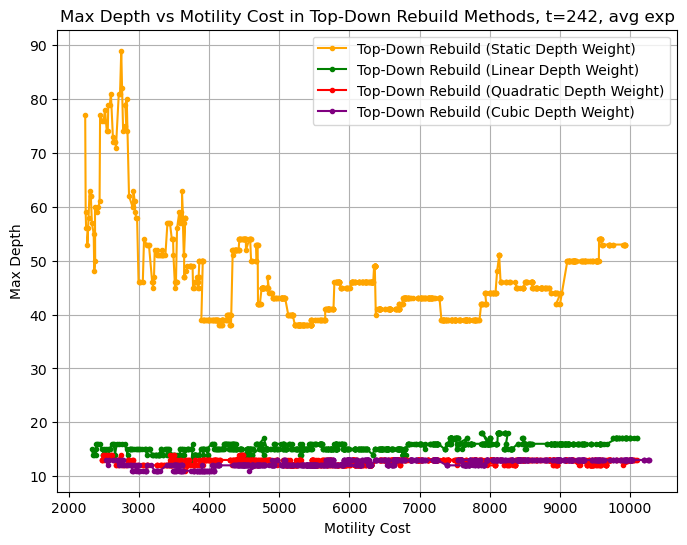

In [29]:
static_rebuild_max_depths = [cost[4] for cost in pareto_list_top_down_rebuild]
linear_rebuild_max_depths = [cost[4] for cost in pareto_list_top_down_rebuild_linear_depth_weight]
quadratic_rebuild_max_depths = [cost[4] for cost in pareto_list_top_down_rebuild_quadratic_depth_weight]
cubic_rebuild_max_depths = [cost[4] for cost in pareto_list_top_down_rebuild_cubic_depth_weight]
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_top_down_rebuild, static_rebuild_max_depths, color='orange', marker='o', linestyle='-',  markersize=3, label='Top-Down Rebuild (Static Depth Weight)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_linear_depth_weight, linear_rebuild_max_depths, color='green', marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Linear Depth Weight)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_quadratic_depth_weight, quadratic_rebuild_max_depths, color='red', marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Quadratic Depth Weight)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_cubic_depth_weight, cubic_rebuild_max_depths, color='purple', marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Cubic Depth Weight)')
plt.xlabel('Motility Cost')
plt.ylabel('Max Depth')
plt.title(f'Max Depth vs Motility Cost in Top-Down Rebuild Methods, t=242, avg exp')
plt.grid(True)
plt.legend()
plt.show()

In [60]:
mst_depth = [max_depth for _, _, max_depth in pareto_mst_list]
np.mean(mst_depth), np.min(mst_depth), np.max(mst_depth)

(np.float64(37.21078921078921), np.int64(28), np.int64(58))

In [ ]:
alpha_tree_tops_list = []
for i in range(1001):
    alpha = 0 + 0.001 * i
    alpha_tree_tops_list.append((alpha, pareto_list_direct_bottom_up_rebuild[i][4]))
# plot alpha vs tree tops
alphas = [x[0] for x in alpha_tree_tops_list]
tree_tops = [x[1] for x in alpha_tree_tops_list]
plt.figure(figsize=(6,4))
plt.plot(alphas, tree_tops, marker='o', markersize=2)
plt.xlabel('Alpha (weight for XYZ cost)')
plt.ylabel('Number of tree tops after direct bottom-up rebuild')
plt.title('Alpha vs Number of Tree Tops')
plt.grid(True)

In [12]:
first_layer_names = ['ABa', 'ABp', 'P2', 'EMS']
first_layer_by_subtree = [[(3, 2)], [(4, 2)], [(5, 2)], [(6, 2)]]
for name, layer in zip(first_layer_names, first_layer_by_subtree):
    opt = LineageOptimization(
        lineage_xyz_mat, 
        lineage_exp_mat,
        lineage_tree,
        first_internal_layer=layer,
        lineage_names=common_lineages, 
        lineage_type_code_dict=complexity_code_dict,
        exp_norm=2)
    random_res = opt.random_rebuild_runner(iterations=1000000, depth_limit=10)
    random_xyz_costs = [cost[0] for cost in random_res]
    random_exp_costs = [cost[1] for cost in random_res]
    random_xyz_mean, random_xyz_std = np.mean(random_xyz_costs), np.std(random_xyz_costs)
    random_exp_mean, random_exp_std = np.mean(random_exp_costs), np.std(random_exp_costs)
    lineage_xyz_dist_from_rand = random_xyz_mean - opt.lineage_xyz_cost
    lineage_exp_dist_from_rand = random_exp_mean - opt.lineage_exp_cost
    pareto_list_by_layer = opt.bottom_up_by_layer_runner()
    pareto_list_top_down_rebuild = opt.top_down_rebuild_runner()
    pareto_mst_list = opt.mst_rebuild_runner()
    pareto_list_top_down_rebuild_depth_cutoff = opt.top_down_rebuild_runner(depth_weight_type=depth_cutoff_func)
    # pareto_list_paired_bottom_up_rebuild = opt.paired_bottom_up_rebuild_runner()
    pareto_list_terminal_only_kd_internal = opt.terminal_only_rebuild_runner(use_kd_tree=True)
    pareto_list_by_layer_xyz_best_from_rand = random_xyz_mean - min([cost[0] for cost in pareto_list_by_layer])
    pareto_list_by_layer_exp_best_from_rand = random_exp_mean - min([cost[1] for cost in pareto_list_by_layer])
    pareto_list_top_down_rebuild_xyz_best_from_rand = random_xyz_mean - min([cost[0] for cost in pareto_list_top_down_rebuild])
    pareto_list_top_down_rebuild_exp_best_from_rand = random_exp_mean - min([cost[1] for cost in pareto_list_top_down_rebuild])
    pareto_mst_list_xyz_best_from_rand = random_xyz_mean - min([cost[0] for cost in pareto_mst_list])
    pareto_mst_list_exp_best_from_rand = random_exp_mean - min([cost[1] for cost in pareto_mst_list])
    pareto_list_top_down_rebuild_depth_cutoff_xyz_best_from_rand = random_xyz_mean - min([cost[0] for cost in pareto_list_top_down_rebuild_depth_cutoff])
    pareto_list_top_down_rebuild_depth_cutoff_exp_best_from_rand = random_exp_mean - min([cost[1] for cost in pareto_list_top_down_rebuild_depth_cutoff])
    # pareto_list_paired_bottom_up_rebuild_xyz_best_from_rand = random_xyz_mean - min([cost[0] for cost in pareto_list_paired_bottom_up_rebuild])
    # pareto_list_paired_bottom_up_rebuild_exp_best_from_rand = random_exp_mean - min([cost[1] for cost in pareto_list_paired_bottom_up_rebuild])
    pareto_list_terminal_only_kd_internal_xyz_best_from_rand = random_xyz_mean - min([cost[0] for cost in pareto_list_terminal_only_kd_internal])
    pareto_list_terminal_only_kd_internal_exp_best_from_rand = random_exp_mean - min([cost[1] for cost in pareto_list_terminal_only_kd_internal])
    print(f"First layer: {name}")
    print(f"Lineage XYZ dist from random compared to bottom up by layer rebuild: {lineage_xyz_dist_from_rand/pareto_list_by_layer_xyz_best_from_rand},")
    print(f"Lineage EXP dist from random compared to bottom up by layer rebuild: {lineage_exp_dist_from_rand/pareto_list_by_layer_exp_best_from_rand},")
    print(f"Lineage XYZ dist from random compared to top down rebuild: {lineage_xyz_dist_from_rand/pareto_list_top_down_rebuild_xyz_best_from_rand},")
    print(f"Lineage EXP dist from random compared to top down rebuild: {lineage_exp_dist_from_rand/pareto_list_top_down_rebuild_exp_best_from_rand},")
    print(f"Lineage XYZ dist from random compared to MST rebuild: {lineage_xyz_dist_from_rand/pareto_mst_list_xyz_best_from_rand},")
    print(f"Lineage EXP dist from random compared to MST rebuild: {lineage_exp_dist_from_rand/pareto_mst_list_exp_best_from_rand},")
    print(f"Lineage XYZ dist from random compared to top down depth cutoff rebuild: {lineage_xyz_dist_from_rand/pareto_list_top_down_rebuild_depth_cutoff_xyz_best_from_rand},")
    print(f"Lineage EXP dist from random compared to top down depth cutoff rebuild: {lineage_exp_dist_from_rand/pareto_list_top_down_rebuild_depth_cutoff_exp_best_from_rand},")
    # print(f"Lineage XYZ dist from random compared to paired bottom up rebuild: {lineage_xyz_dist_from_rand/pareto_list_paired_bottom_up_rebuild_xyz_best_from_rand},")
    # print(f"Lineage EXP dist from random compared to paired bottom up rebuild: {lineage_exp_dist_from_rand/pareto_list_paired_bottom_up_rebuild_exp_best_from_rand},")
    print(f"Lineage XYZ dist from random compared to terminal only rebuild: {lineage_xyz_dist_from_rand/pareto_list_terminal_only_kd_internal_xyz_best_from_rand},")
    print(f"Lineage EXP dist from random compared to terminal only rebuild: {lineage_exp_dist_from_rand/pareto_list_terminal_only_kd_internal_exp_best_from_rand},")
    print("-----")


2033.475582045074 51479.28148302795 438
Parent not found for node: 0
0.1735159817351598


Computing random rebuild costs...:   0%|          | 0/1000000 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing mst test:   0%|          | 0/1001 [00:00<?, ?it/s]

...

Computing mst test:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs 1/2:   0%|          | 0/500 [00:00<?, ?it/s]

Computing pareto costs 2/2:   0%|          | 0/501 [00:00<?, ?it/s]

First layer: EMS
Lineage XYZ dist from random compared to bottom up by layer rebuild: 0.8572005300708876,
Lineage EXP dist from random compared to bottom up by layer rebuild: 0.9366219656951886,
Lineage XYZ dist from random compared to top down rebuild: 0.7532348771750882,
Lineage EXP dist from random compared to top down rebuild: 0.7717367405881714,
Lineage XYZ dist from random compared to MST rebuild: 0.7436175262946618,
Lineage EXP dist from random compared to MST rebuild: 0.7403736135792977,
Lineage XYZ dist from random compared to top down depth cutoff rebuild: 0.7832934662971196,
Lineage EXP dist from random compared to top down depth cutoff rebuild: 0.8360235880615687,
Lineage XYZ dist from random compared to terminal only rebuild: 0.6627793865640399,
Lineage EXP dist from random compared to terminal only rebuild: 0.5494301052071817,
-----


In [55]:
random_res = opt.random_rebuild_runner(iterations=1000000, depth_limit=10)
random_xyz_costs = [cost[0] for cost in random_res]
random_exp_costs = [cost[1] for cost in random_res]
random_xyz_mean, random_xyz_std = np.mean(random_xyz_costs), np.std(random_xyz_costs)
random_exp_mean, random_exp_std = np.mean(random_exp_costs), np.std(random_exp_costs)
lineage_xyz_dist_from_rand = random_xyz_mean - opt.lineage_xyz_cost
lineage_exp_dist_from_rand = random_exp_mean - opt.lineage_exp_cost

pareto_list_by_layer_xyz_best_from_rand = random_xyz_mean - min(pareto_xyz_cost_list_by_layer)
pareto_list_by_layer_exp_best_from_rand = random_exp_mean - min(pareto_exp_cost_list_by_layer)
pareto_list_top_down_rebuild_xyz_best_from_rand = random_xyz_mean - min(pareto_xyz_cost_list_top_down_rebuild)
pareto_list_top_down_rebuild_exp_best_from_rand = random_exp_mean - min(pareto_exp_cost_list_top_down_rebuild)
pareto_mst_list_xyz_best_from_rand = random_xyz_mean - min(pareto_xyz_cost_list_mst)
pareto_mst_list_exp_best_from_rand = random_exp_mean - min(pareto_exp_cost_list_mst)
pareto_list_top_down_rebuild_depth_cutoff_xyz_best_from_rand = random_xyz_mean - min(pareto_xyz_cost_list_top_down_rebuild_depth_cutoff)
pareto_list_top_down_rebuild_depth_cutoff_exp_best_from_rand = random_exp_mean - min(pareto_exp_cost_list_top_down_rebuild_depth_cutoff)
pareto_list_terminal_only_kd_internal_xyz_best_from_rand = random_xyz_mean - min(pareto_xyz_cost_list_terminal_only_kd_internal)
pareto_list_terminal_only_kd_internal_exp_best_from_rand = random_exp_mean - min(pareto_exp_cost_list_terminal_only_kd_internal)
print(f"First layer: Full Tree")
print(f"Lineage XYZ dist from random compared to bottom up by layer rebuild: {lineage_xyz_dist_from_rand/pareto_list_by_layer_xyz_best_from_rand},")
print(f"Lineage EXP dist from random compared to bottom up by layer rebuild: {lineage_exp_dist_from_rand/pareto_list_by_layer_exp_best_from_rand},")
print(f"Lineage XYZ dist from random compared to top down rebuild: {lineage_xyz_dist_from_rand/pareto_list_top_down_rebuild_xyz_best_from_rand},")
print(f"Lineage EXP dist from random compared to top down rebuild: {lineage_exp_dist_from_rand/pareto_list_top_down_rebuild_exp_best_from_rand},")
print(f"Lineage XYZ dist from random compared to MST rebuild: {lineage_xyz_dist_from_rand/pareto_mst_list_xyz_best_from_rand},")
print(f"Lineage EXP dist from random compared to MST rebuild: {lineage_exp_dist_from_rand/pareto_mst_list_exp_best_from_rand},")
print(f"Lineage XYZ dist from random compared to top down depth cutoff rebuild: {lineage_xyz_dist_from_rand/pareto_list_top_down_rebuild_depth_cutoff_xyz_best_from_rand},")
print(f"Lineage EXP dist from random compared to top down depth cutoff rebuild: {lineage_exp_dist_from_rand/pareto_list_top_down_rebuild_depth_cutoff_exp_best_from_rand},")
# print(f"Lineage XYZ dist from random compared to paired bottom up rebuild: {lineage_xyz_dist_from_rand/pareto_list_paired_bottom_up_rebuild_xyz_best_from_rand},")
# print(f"Lineage EXP dist from random compared to paired bottom up rebuild: {lineage_exp_dist_from_rand/pareto_list_paired_bottom_up_rebuild_exp_best_from_rand},")
print(f"Lineage XYZ dist from random compared to terminal only rebuild: {lineage_xyz_dist_from_rand/pareto_list_terminal_only_kd_internal_xyz_best_from_rand},")
print(f"Lineage EXP dist from random compared to terminal only rebuild: {lineage_exp_dist_from_rand/pareto_list_terminal_only_kd_internal_exp_best_from_rand},")
print("-----")

Computing random rebuild costs...:   0%|          | 0/1000000 [00:00<?, ?it/s]

First layer: Full Tree
Lineage XYZ dist from random compared to bottom up by layer rebuild: 0.917326839255735,
Lineage EXP dist from random compared to bottom up by layer rebuild: 0.944341832487922,
Lineage XYZ dist from random compared to top down rebuild: 0.822911120713983,
Lineage EXP dist from random compared to top down rebuild: 0.822982511430701,
Lineage XYZ dist from random compared to MST rebuild: 0.8206108526557775,
Lineage EXP dist from random compared to MST rebuild: 0.8062662384845425,
Lineage XYZ dist from random compared to top down depth cutoff rebuild: 0.8449135118467042,
Lineage EXP dist from random compared to top down depth cutoff rebuild: 0.8849278035598064,
Lineage XYZ dist from random compared to terminal only rebuild: 0.7958792594172159,
Lineage EXP dist from random compared to terminal only rebuild: 0.624579016220562,
-----


## Null Models

To evaluate whether the observed *C.~elegans* lineage tree is non-randomly organized with respect to spatial positioning and gene expression, we benchmark the real lineage against a hierarchy of null models of increasing biological stringency. Each null generates a sampling distribution over the Pareto cost pair $(C_\text{xyz},\, C_\text{exp})$ via Monte Carlo simulation ($10^6$ iterations), against which the position of the real lineage on the Pareto front is assessed.

---

### Null Model I: Layer-wise Random Shuffle

**Rationale.**
The simplest structured null preserves the temporal stratification of cell divisions — nodes at the same tree depth correspond approximately to the same developmental time — while removing any spatial or transcriptomic specificity within each stratum.

**Construction.**
Let $V_\ell = \{v \in V : \text{depth}(v) = \ell\}$ denote the set of nodes at depth $\ell$, partitioned into internal nodes $V_\ell^\text{int}$ and terminal nodes $V_\ell^\text{term}$.
In each null replicate, the cell identity assignment $\pi: V \to \mathcal{I}$ is perturbed by independently applying a uniform random permutation to $\{$\pi(v) : v \in V_\ell^\text{int}\}$ for every depth $\ell$, and separately permuting terminal identities among themselves.
The total spatial and expression edge costs are then re-evaluated under the shuffled assignment.

**Interpretation.**
This null tests whether the real lineage assignment is better organized than would be expected from a random labeling that respects only the depth-stratified (temporal) structure of cell divisions. A real lineage cost lying outside the null distribution implies that the specific allocation of identities to nodes at each developmental stage is non-random.

---

### Null Model II: $k$-th Cousin Shuffle

**Rationale.**
A more conservative null restricts randomization to progressively smaller clades, thereby preserving large-scale lineage geography while testing fine-grained within-clade specificity.

**Construction.**
For a degree parameter $k \in \{1, 2, 3\}$, define the **$k$-th cousin group** of a terminal node $v$ as the set of all terminal nodes sharing a common ancestor exactly $k+1$ levels above the leaf:
$$
G_k(v) = \bigl\{\, u \in V_\text{term} \;\big|\; \text{anc}_{k+1}(u) = \text{anc}_{k+1}(v) \,\bigr\}
$$
where $\text{anc}_j(v)$ denotes the $j$-th ancestor of $v$ on the path to the root.
In each null replicate, cell identities are permuted uniformly at random **within** each cousin group independently, leaving all inter-group assignments unchanged.
The three values $k = 1, 2, 3$ correspond to shuffling among siblings-of-siblings (most conservative), 2nd-degree clades, and wider 3rd-degree clades, respectively.

**Interpretation.**
The $k$-th cousin shuffle family provides a resolution-dependent significance test. As $k$ decreases from 3 to 1, the null becomes progressively more constrained: at $k=1$, only the very local neighborhood of a cell's immediate sibling subtree is scrambled, while broader lineage geography is fully preserved. If the real lineage cost remains below the null distribution even at $k=1$, this constitutes strong evidence that the assignment is optimized at the finest resolvable scale of clonal identity.

---

### Null Model III: Phylogenetic Brownian Motion

**Rationale.**
The shuffling nulls above are combinatorial: they permute observed cell states without regard to how those states may have been generated. A more principled null instead posits that cell states evolve by **neutral Brownian diffusion** along the fixed lineage tree topology, with no selection pressure toward spatial or transcriptomic optimality. This null fully accounts for the phylogenetic covariance structure of the data, i.e., the statistical non-independence of cells that share common ancestors.

**Construction.**
The null model proceeds in three steps.

**(1) Rate estimation via Phylogenetic Generalized Least Squares (PGLS).**
Given the fixed tree topology, the phylogenetic variance-covariance matrix $\boldsymbol{\Sigma}$ is computed under unit-rate Brownian motion, with entries:
$$
\Sigma_{ij} = \sigma^2 \cdot t_\text{shared}(i, j)
$$
where $t_\text{shared}(i,j)$ is the total branch length shared between terminals $i$ and $j$ from the root to their last common ancestor.
The per-feature maximum likelihood Brownian motion rate $\hat{\sigma}^2$ and ancestral root state $\hat{\mu}$ are then jointly estimated via PGLS:
$$
\hat{\mu} = \frac{\mathbf{1}^\top \boldsymbol{\Sigma}^{-1} \mathbf{y}}{\mathbf{1}^\top \boldsymbol{\Sigma}^{-1} \mathbf{1}}, \qquad
\hat{\sigma}^2 = \frac{1}{n}\,(\mathbf{y} - \hat{\mu}\mathbf{1})^\top \boldsymbol{\Sigma}^{-1}(\mathbf{y} - \hat{\mu}\mathbf{1})
$$
where $\mathbf{y} \in \mathbb{R}^{n \times d}$ collects the observed terminal cell states (spatial coordinates concatenated with expression principal components), and $n$ is the number of terminal nodes.

**(2) Ancestral state reconstruction.**
Internal node states $\hat{\mathbf{z}}_v$ and their posterior variances $\hat{\boldsymbol{\nu}}_v$ are estimated using a two-pass algorithm on the tree:
- *Post-order (bottom-up):* Starting from the fixed terminal observations, each internal node's state is estimated by pooling signals from all descendants via inverse-variance weighting, propagating upward to the root.
- *Pre-order (top-down):* The root estimate is then propagated back downward. At each internal node, the upward (bottom-up) estimate is refined by blending with a top-down prediction from the parent, where the expected value equals the parent's state and the prediction variance is proportional to the branch length times $\hat{\sigma}^2$. The two sources of evidence are combined using inverse-variance weights:
$$
\hat{\mathbf{z}}_v = \frac{\hat{\boldsymbol{\nu}}_v^{-1} \cdot \mathbf{z}_v^\uparrow + (\Delta t_v \hat{\sigma}^2)^{-1} \cdot \hat{\mathbf{z}}_\text{parent}}{\hat{\boldsymbol{\nu}}_v^{-1} + (\Delta t_v \hat{\sigma}^2)^{-1}}
$$
where $\Delta t_v$ is the branch length of node $v$ and $\mathbf{z}_v^\uparrow$ is its bottom-up estimate.

**(3) Monte Carlo sampling.**
For each node $v$ in the tree, cell states are sampled independently from the posterior:
$$
\mathbf{z}_v^{(s)} \sim \mathcal{N}\!\left(\hat{\mathbf{z}}_v,\; \mathrm{diag}(\hat{\boldsymbol{\nu}}_v)\right), \quad s = 1, \ldots, N_\text{samples}
$$
The Pareto cost pair $(C_\text{xyz}^{(s)},\, C_\text{exp}^{(s)})$ is evaluated for each sample by summing Euclidean distances over all edges in the tree, yielding a null distribution that captures the expected cost under neutral phylogenetic diffusion.

**Interpretation.**
Unlike the permutation nulls, the Brownian motion null does not reshuffle observed values. Instead, it asks: *if the spatial positions and gene expression profiles of cells arose purely through neutral diffusion along the lineage tree — with no selection for compactness or transcriptomic coherence — what tree costs would we observe?* By conditioning on both the tree topology and the Brownian motion rate estimated from the real data, this null controls for the confounding effect of phylogenetic relatedness. A real lineage cost lying significantly below this null distribution therefore provides evidence for active optimization of the lineage tree beyond what neutral hereditary drift along the developmental tree would predict.

| Subtree | Metric | Bottom Up by Layer | Top Down | MST | Top Down w/ Depth Cutoff | Terminal Only |
|---|---|---|---|---|---|---|
| **ABa** | Lineage XYZ | 0.9229 | 0.8219 | 0.8150 | 0.8657 | 0.7610 |
| **ABa** | Lineage EXP | 0.9441 | 0.8405 | 0.8226 | 0.9110 | 0.6329 |
| **ABp** | Lineage XYZ | 0.9638 | 0.8978 | 0.8879 | 0.9171 | 0.8094 |
| **ABp** | Lineage EXP | 0.8810 | 0.7490 | 0.7227 | 0.8330 | 0.5586 |
| **P2** | Lineage XYZ | 0.9935 | 0.8476 | 0.8281 | 0.8852 | 0.7026 |
| **P2** | Lineage EXP | 1.0010 | 0.9024 | 0.8917 | 0.9388 | 0.6457 |
| **EMS** | Lineage XYZ | 0.8572 | 0.7532 | 0.7436 | 0.7833 | 0.6628 |
| **EMS** | Lineage EXP | 0.9366 | 0.7717 | 0.7404 | 0.8360 | 0.5494 |
| **Full Tree** | Lineage XYZ | 0.9173 | 0.8229 | 0.8206 | 0.8449 | 0.7959 |
| **Full Tree** | Lineage EXP | 0.9443 | 0.8230 | 0.8063 | 0.8849 | 0.6246 |